# Code for Ch 2: Quantum Algorithms
This Jupyter notebook contains Qiskit code used for Chapter 2 of my tutorial on Quantum Machine Learning (QML), which is based on material from the 2021 Qiskit Summer School on QML and the online Qiskit textbook.

NB: it's worth noting, that the code here has been created with LLM assistance and by referring to the online Qiskit textbook

In [56]:
# Boilerplate to run 
%matplotlib inline
import matplotlib
import matplotlib.pyplot as plt 
import matplotlib.patches as patches
plt.style.use('../intro_to_qml_figure_style.mpltstyle') # This style sheet is in use.
 
import warnings 
warnings.filterwarnings( # Filter out the specific tight_layout warning generated by Jupyter/Matplotlib 3D plots
    "ignore", 
    category=UserWarning, 
    message="This figure includes Axes that are not compatible with tight_layout"
)

from qiskit.visualization import plot_bloch_vector
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from IPython.display import display
import numpy as np

figure_directory = '../Figures/Ch2_Quantum_Algorithms_Figures/'

# Simple Demonstration of Quantum Effects
## Quantum Teleportation

The Qiskit implementation here and for superdense encording is based on implementations from the following <a href="https://quantum.cloud.ibm.com/learning/en/courses/basics-of-quantum-information/entanglement-in-action/qiskit-implementation">Qiskit learning material</a>.

NameError: name 'font_style' is not defined

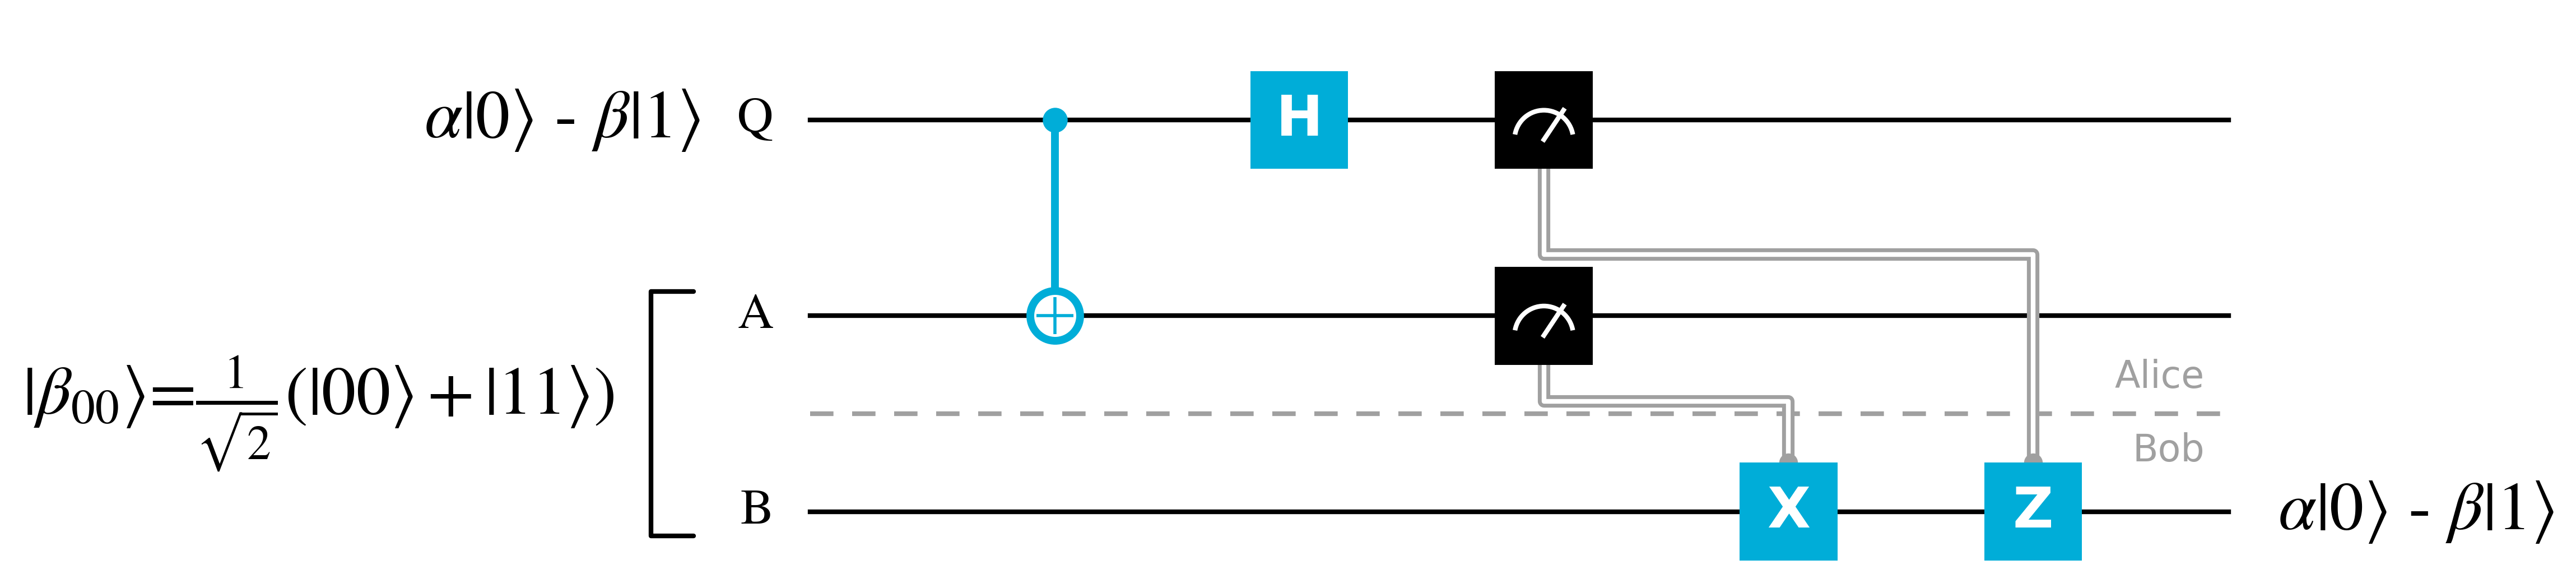

In [ ]:
# Note: the following figure made use of AI assistance.
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from qiskit.transpiler import generate_preset_pass_manager
# from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit_ibm_runtime.executor_estimator import Estimator

# 1. Force Matplotlib to use STIX for all math text natively
plt.rcParams['mathtext.fontset'] = 'stix'
plt.rcParams['font.family'] = 'STIXGeneral'

def draw_teleportation_mpl(filename):
    # Set high resolution and canvas size
    fig, ax = plt.subplots(figsize=(10, 4.5), dpi=400)
    ax.set_xlim(40, 750)
    ax.set_ylim(280, 60) # Inverted Y-axis so y=100 is at the top
    ax.axis('off') # Hide axes
    
    # === ADD THIS LINE TO FIX THE STRETCHING ===
    ax.set_aspect('equal') # Forces perfect square units
    # ============================================

    # --- Constants & Layout ---
    WIRE_Q, WIRE_A, WIRE_B = 100, 180, 260
    START_X, END_X = 120, 700
    BLUE = '#00ADD8'  # Rich cyan/blue matching the previous image
    BLACK = 'black'
    GREY = '#A0A0A0'

    # ==========================================
    # 2. DRAW WIRES & DIVIDER
    # ==========================================
    for y in [WIRE_Q, WIRE_A, WIRE_B]:
        ax.plot([START_X, END_X], [y, y], color=BLACK, lw=1.5, zorder=1)

    # Dashed dividing line
    ax.plot([START_X, END_X], [220, 220], color=GREY, lw=1.5, linestyle='--', dashes=(5, 4), zorder=1)
    ax.text(END_X - 10, 205, "Alice", color=GREY, fontsize=12, ha='right', va='center', fontfamily='sans-serif')
    ax.text(END_X - 10, 235, "Bob", color=GREY, fontsize=12, ha='right', va='center', fontfamily='sans-serif')

    # ==========================================
    # 3. LABELS & KETS (Full LaTeX Support!)
    # ==========================================
    text_opts = {'fontsize': 16, 'va': 'center'}
    ax.text(START_X - 15, WIRE_Q, "Q", ha='right', **text_opts)
    ax.text(START_X - 15, WIRE_A, "A", ha='right', **text_opts)
    ax.text(START_X - 15, WIRE_B, "B", ha='right', **text_opts)

    # Because of Matplotlib, we can use pure LaTeX strings now!
    ax.text(START_X - 45, WIRE_Q, r"$\alpha|0\rangle$ - $\beta|1\rangle$", ha='right', fontsize=22, va='center')
    ax.text(START_X - 80, (WIRE_A + WIRE_B)/2, r"$|\beta_{00}\rangle$=$\frac{1}{\sqrt{2}}(|00\rangle +|11\rangle)$", ha='right', fontsize=22, va='center')
    ax.text(END_X + 20, WIRE_B, r"$\alpha|0\rangle$ - $\beta|1\rangle$", ha='left', fontsize=22, va='center')

    # Draw curly bracket using Matplotlib annotations
    ax.annotate('', xy=(START_X - 45, WIRE_A - 10), xytext=(START_X - 45, WIRE_B + 10),
                arrowprops=dict(arrowstyle='-', connectionstyle='bar,fraction=-0.2', lw=1.5))

    # ==========================================
    # 4. HELPER FUNCTIONS FOR GATES
    # ==========================================
    def draw_gate(x, y, text):
        rect = patches.Rectangle((x-20, y-20), 40, 40, facecolor=BLUE, zorder=3)
        ax.add_patch(rect)
        ax.text(x, y, text, color='white', fontsize=18, fontweight='bold', ha='center', va='center', zorder=4, fontfamily='sans-serif')

    def draw_meter(x, y):
        rect = patches.Rectangle((x-20, y-20), 40, 40, facecolor=BLACK, zorder=3)
        ax.add_patch(rect)
        # Dial arc
        arc = patches.Arc((x, y+8), 24, 24, theta1=190, theta2=350, color='white', lw=1.5, zorder=4)
        ax.add_patch(arc)
        # Needle
        ax.plot([x, x+8], [y+8, y-4], color='white', lw=1.5, zorder=4)

    # ==========================================
    # 5. GATES & MEASUREMENTS
    # ==========================================
    # CNOT
    cnot_x = 220
    ax.plot([cnot_x, cnot_x], [WIRE_Q, WIRE_A], color=BLUE, lw=2.5, zorder=2)
    ax.plot(cnot_x, WIRE_Q, marker='o', color=BLUE, markersize=7, zorder=3) # Control
    ax.plot(cnot_x, WIRE_A, marker='o', color='white', markeredgecolor=BLUE, markeredgewidth=2.5, markersize=16, zorder=3) # Target
    ax.plot(cnot_x, WIRE_A, marker='+', color=BLUE, markersize=12, zorder=4) # Cross

    draw_gate(320, WIRE_Q, "H")
    meter_x = 420
    draw_meter(meter_x, WIRE_Q)
    draw_meter(meter_x, WIRE_A)

    # ==========================================
    # 6. CLASSICAL COMMUNICATION LINES
    # ==========================================
    gate_x_pos, gate_z_pos = 520, 620

    # Lower line (A to X)
    x_lower = [meter_x, meter_x, gate_x_pos, gate_x_pos]
    y_lower = [WIRE_A + 20, WIRE_A + 35, WIRE_A + 35, WIRE_B - 20]
    ax.plot(x_lower, y_lower, color=GREY, lw=4, zorder=1)
    ax.plot(x_lower, y_lower, color='white', lw=1.5, zorder=2) # Creates the "double line" look

    # Upper line (Q to Z)
    x_upper = [meter_x, meter_x, gate_z_pos, gate_z_pos]
    y_upper = [WIRE_Q + 20, WIRE_A - 25, WIRE_A - 25, WIRE_B - 20]
    ax.plot(x_upper, y_upper, color=GREY, lw=4, zorder=1)
    ax.plot(x_upper, y_upper, color='white', lw=1.5, zorder=2)

    # Connection dots on classical wires
    ax.plot([gate_x_pos, gate_z_pos], [WIRE_B - 20, WIRE_B - 20], marker='o', color=GREY, markersize=5, lw=0, zorder=3)

    # Conditional Gates
    draw_gate(gate_x_pos, WIRE_B, "X")
    draw_gate(gate_z_pos, WIRE_B, "Z")

    x_min, x_max = ax.get_xlim()
    y_min, y_max = ax.get_ylim()
  
    ax.text(x_min + 0, y_max , r'$|\psi_1\rangle$', color='gray', **font_style)
    ax.text(x_min + 300, y_max , r'$|\psi_2\rangle$', color='gray', **font_style)
    ax.text(x_min + 400, y_max , r'$|\psi_3\rangle$', color='gray', **font_style)
    ax.text(x_max, y_max , r'$|\psi_4\rangle$', color='gray', **font_style)

    plt.savefig(filename, bbox_inches='tight', pad_inches=0.1)
    #print(f"Success! Perfect LaTeX diagram saved to {filename}")

draw_teleportation_mpl(figure_directory+'quantum_teleportation_sketch.png')

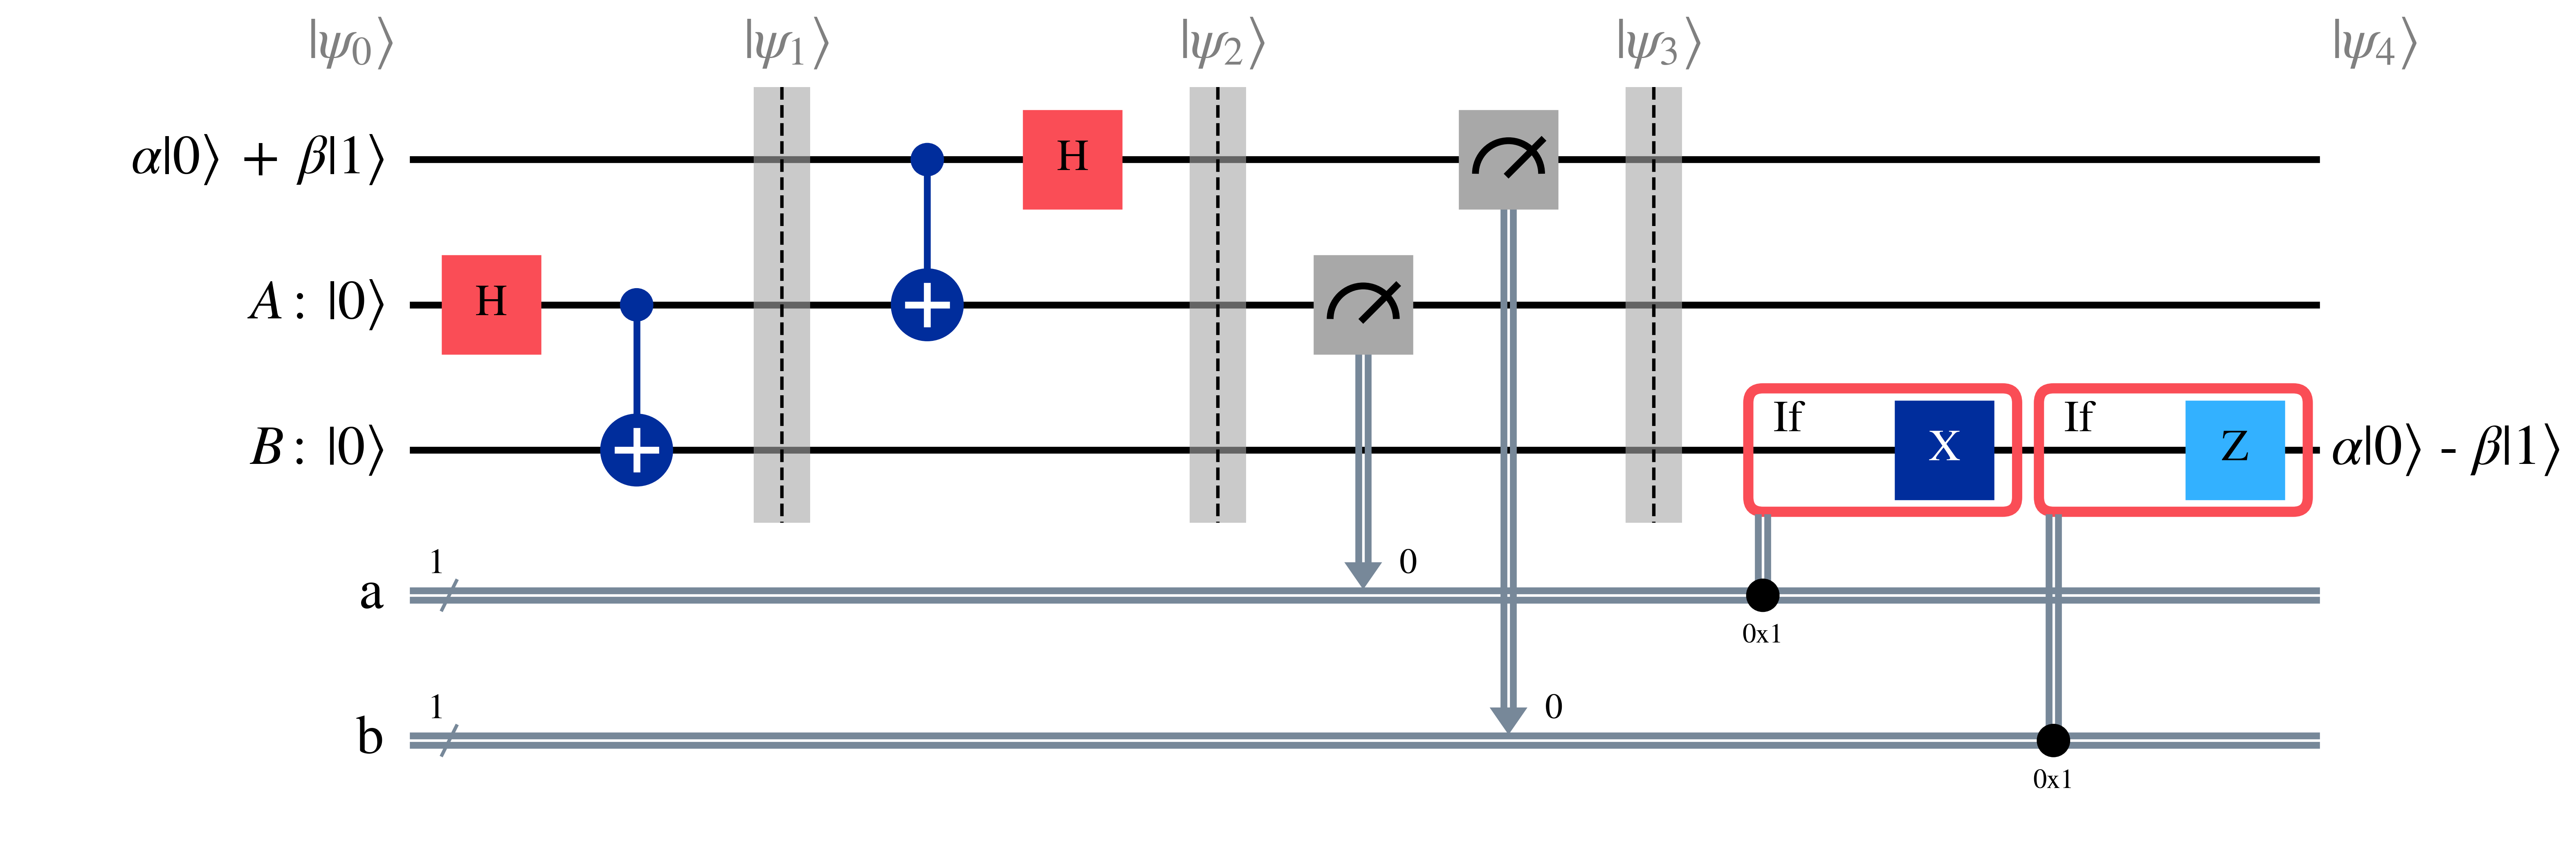

In [94]:
# Note, the folowing is based on code from https://quantum.cloud.ibm.com/learning/en/courses/basics-of-quantum-information/entanglement-in-action/qiskit-implementation
qubit = QuantumRegister(1, "α|0⟩ + β|1⟩")
ebit0 = QuantumRegister(1, "A: |0⟩")
ebit1 = QuantumRegister(1, "B: |0⟩")
a = ClassicalRegister(1, "a")
b = ClassicalRegister(1, "b")

protocol = QuantumCircuit(qubit, ebit0, ebit1, a, b)

# Prepare ebit used for teleportation
protocol.h(ebit0)
protocol.cx(ebit0, ebit1)
protocol.barrier()

# Alice's operations
protocol.cx(qubit, ebit0)
protocol.h(qubit)
protocol.barrier()

# Alice measures and sends classical bits to Bob
protocol.measure(ebit0, a)
protocol.measure(qubit, b)
protocol.barrier()

# Bob uses the classical bits to conditionally apply gates
with protocol.if_test((a, 1)):
    protocol.x(ebit1)
with protocol.if_test((b, 1)):
    protocol.z(ebit1)

#display(protocol.draw(output="mpl"))

fig_qc = protocol.draw(output='mpl', scale =1.5)#, initial_state=False)
ax = fig_qc.axes[0]
x_min, x_max = ax.get_xlim()
y_min, y_max = ax.get_ylim()
ax.set_xlim(x_min, x_max + 1.5)
ax.set_ylim(y_min , y_max + 0.1)

font_style = {'fontsize': 25, 'verticalalignment': 'center'}
ax.text(x_min+2, y_max , r'$|\psi_0\rangle$', color='gray', **font_style)
ax.text(x_min + 5, y_max , r'$|\psi_1\rangle$', color='gray', **font_style)
ax.text(x_min + 8, y_max , r'$|\psi_2\rangle$', color='gray', **font_style)
ax.text(x_min + 11, y_max , r'$|\psi_3\rangle$', color='gray', **font_style)
ax.text(x_max, y_max , r'$|\psi_4\rangle$', color='gray', **font_style)
ax.text(x_max, y_min+2.6, r"$\alpha|0\rangle$ - $\beta|1\rangle$", **font_style)

fig_qc.savefig(figure_directory+'quantum_teleportation_annotated_circuit.png', bbox_inches='tight')

## Superdense encoding

The Qiskit implementation here and for quantum teleportation is based on implementations from the following <a href="https://quantum.cloud.ibm.com/learning/en/courses/basics-of-quantum-information/entanglement-in-action/qiskit-implementation">Qiskit learning material</a>.

Success! Diagram saved to Figures/Ch2_Quantum_Algorithms_Figures/superdense_coding_sketch.png


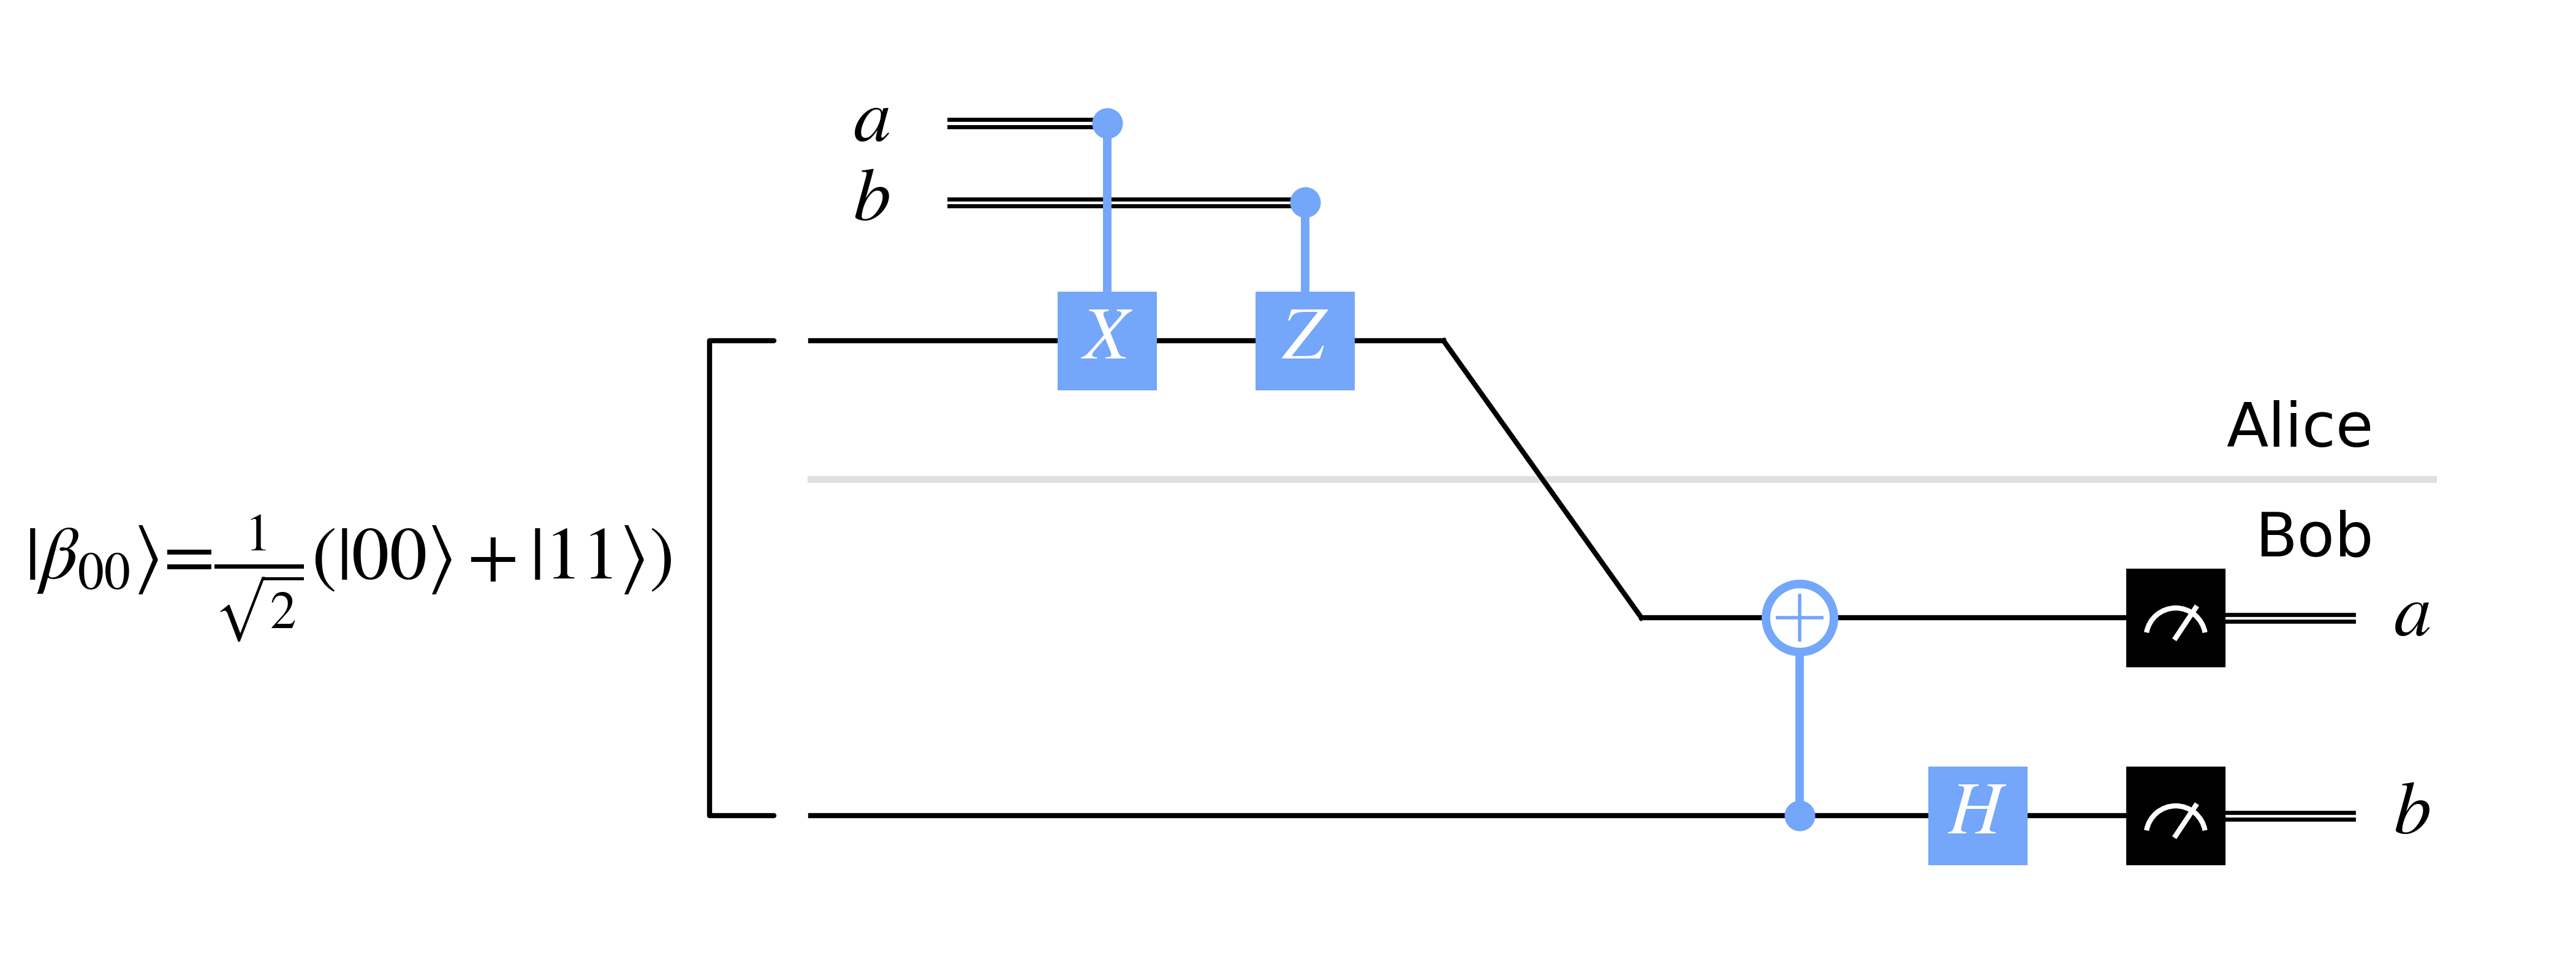

In [95]:
# Note: the following figure made use of AI assistance.
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# 1. Force Matplotlib to use STIX for all math text natively
plt.rcParams['mathtext.fontset'] = 'stix'
plt.rcParams['font.family'] = 'STIXGeneral'

def draw_superdense_mpl(filename):
    # Set high resolution and canvas size
    fig, ax = plt.subplots(figsize=(10, 6), dpi=400)
    ax.set_xlim(20, 980)
    ax.set_ylim(480, 20) # Inverted Y-axis so y=0 is at the top
    ax.axis('off') # Hide axes
    
    # Force perfect square units to prevent gate stretching
    ax.set_aspect('equal') 

    # --- Constants & Colors ---
    BLUE = '#74A6FA'  # Soft cornflower blue from the image
    BLACK = 'black'
    GREY = '#E0E0E0'  # Light grey for the divider

    # ==========================================
    # HELPER FUNCTIONS
    # ==========================================
    def double_line(x0, x1, y, color=BLACK, lw=1.2, gap=4):
        """Draws the double lines used for classical bits."""
        ax.plot([x0, x1], [y - gap/2, y - gap/2], color=color, lw=lw, zorder=1)
        ax.plot([x0, x1], [y + gap/2, y + gap/2], color=color, lw=lw, zorder=1)

    def draw_gate(x, y, text):
        rect = patches.Rectangle((x-25, y-25), 50, 50, facecolor=BLUE, zorder=3)
        ax.add_patch(rect)
        ax.text(x, y, f"${text}$", color='white', fontsize=22, ha='center', va='center', zorder=4)

    def draw_meter(x, y):
        rect = patches.Rectangle((x-25, y-25), 50, 50, facecolor=BLACK, zorder=3)
        ax.add_patch(rect)
        # Dial arc
        arc = patches.Arc((x, y+10), 30, 30, theta1=190, theta2=350, color='white', lw=1.5, zorder=4)
        ax.add_patch(arc)
        # Needle
        ax.plot([x, x+10], [y+10, y-5], color='white', lw=1.5, zorder=4)

    # ==========================================
    # 1. DIVIDER & LABELS (Alice / Bob)
    # ==========================================
    ax.plot([100, 920], [250, 250], color=GREY, lw=2, zorder=1)
    ax.text(890, 225, "Alice", color=BLACK, fontsize=18, ha='right', va='center', fontfamily='sans-serif')
    ax.text(890, 280, "Bob", color=BLACK, fontsize=18, ha='right', va='center', fontfamily='sans-serif')

    # ==========================================
    # 2. LEFT SIDE WIRES & INITIAL STATES
    # ==========================================
    # Initial Qubit wires
    ax.plot([100, 420], [180, 180], color=BLACK, lw=1.5, zorder=1) # Alice's half of the Bell pair
    ax.plot([100, 800], [420, 420], color=BLACK, lw=1.5, zorder=1) # Bob's half of the Bell pair

    # Initial State Bracket & Label
    ax.text(30, 300, r"$|\beta_{00}\rangle$=$\frac{1}{\sqrt{2}}(|00\rangle +|11\rangle)$", ha='right', fontsize=22, va='center')
    ax.annotate('', xy=(85, 180), xytext=(85, 420),
                arrowprops=dict(arrowstyle='-', connectionstyle='bar,fraction=-0.15', lw=1.5))

    # Classical Inputs at the top left
    double_line(170, 250, 70, gap=3.5) # d wire
    double_line(170, 350, 110, gap=3.5) # c wire
    ax.text(140, 70, "$a$", fontsize=22, ha='right', va='center')
    ax.text(140, 110, "$b$", fontsize=22, ha='right', va='center')

    # ==========================================
    # 3. ALICE'S ENCODING GATES
    # ==========================================
    # Z gate controlled by classical wire d
    ax.plot([250, 250], [70, 180], color=BLUE, lw=2.5, zorder=2)
    ax.plot(250, 70, marker='o', color=BLUE, markersize=8, zorder=3) # Control dot
    draw_gate(250, 180, "X")

    # X gate controlled by classical wire c
    ax.plot([350, 350], [110, 180], color=BLUE, lw=2.5, zorder=2)
    ax.plot(350, 110, marker='o', color=BLUE, markersize=8, zorder=3) # Control dot
    draw_gate(350, 180, "Z")

    # ==========================================
    # 4. TRANSMISSION SLANT (Alice sends to Bob)
    # ==========================================
    ax.plot([420, 520], [180, 320], color=BLACK, lw=1.5, zorder=1)
    ax.plot([520, 800], [320, 320], color=BLACK, lw=1.5, zorder=1) # Received wire continues

    # ==========================================
    # 5. BOB'S DECODING GATES
    # ==========================================
    # CNOT
    cnot_x = 600
    ax.plot([cnot_x, cnot_x], [320, 420], color=BLUE, lw=2.5, zorder=2)
    ax.plot(cnot_x, 420, marker='o', color=BLUE, markersize=8, zorder=3) # Control
    ax.plot(cnot_x, 320, marker='o', color='white', markeredgecolor=BLUE, markeredgewidth=2.5, markersize=20, zorder=3) # Target Circle
    ax.plot(cnot_x, 320, marker='+', color=BLUE, markersize=14, zorder=4) # Target Cross

    # H Gate
    draw_gate(690, 420, "H")

    # ==========================================
    # 6. MEASUREMENTS & OUTPUTS
    # ==========================================
    draw_meter(790, 320)
    draw_meter(790, 420)

    # Output classical wires
    double_line(815, 880, 320, gap=3.5)
    double_line(815, 880, 420, gap=3.5)
    
    # Output labels
    ax.text(900, 320, "$a$", fontsize=22, ha='left', va='center')
    ax.text(900, 420, "$b$", fontsize=22, ha='left', va='center')

    # Save the result
    plt.savefig(filename, bbox_inches='tight', pad_inches=0.1)
    print(f"Success! Diagram saved to {filename}")

# Execute the drawing function
draw_superdense_mpl(figure_directory+'superdense_coding_sketch.png')

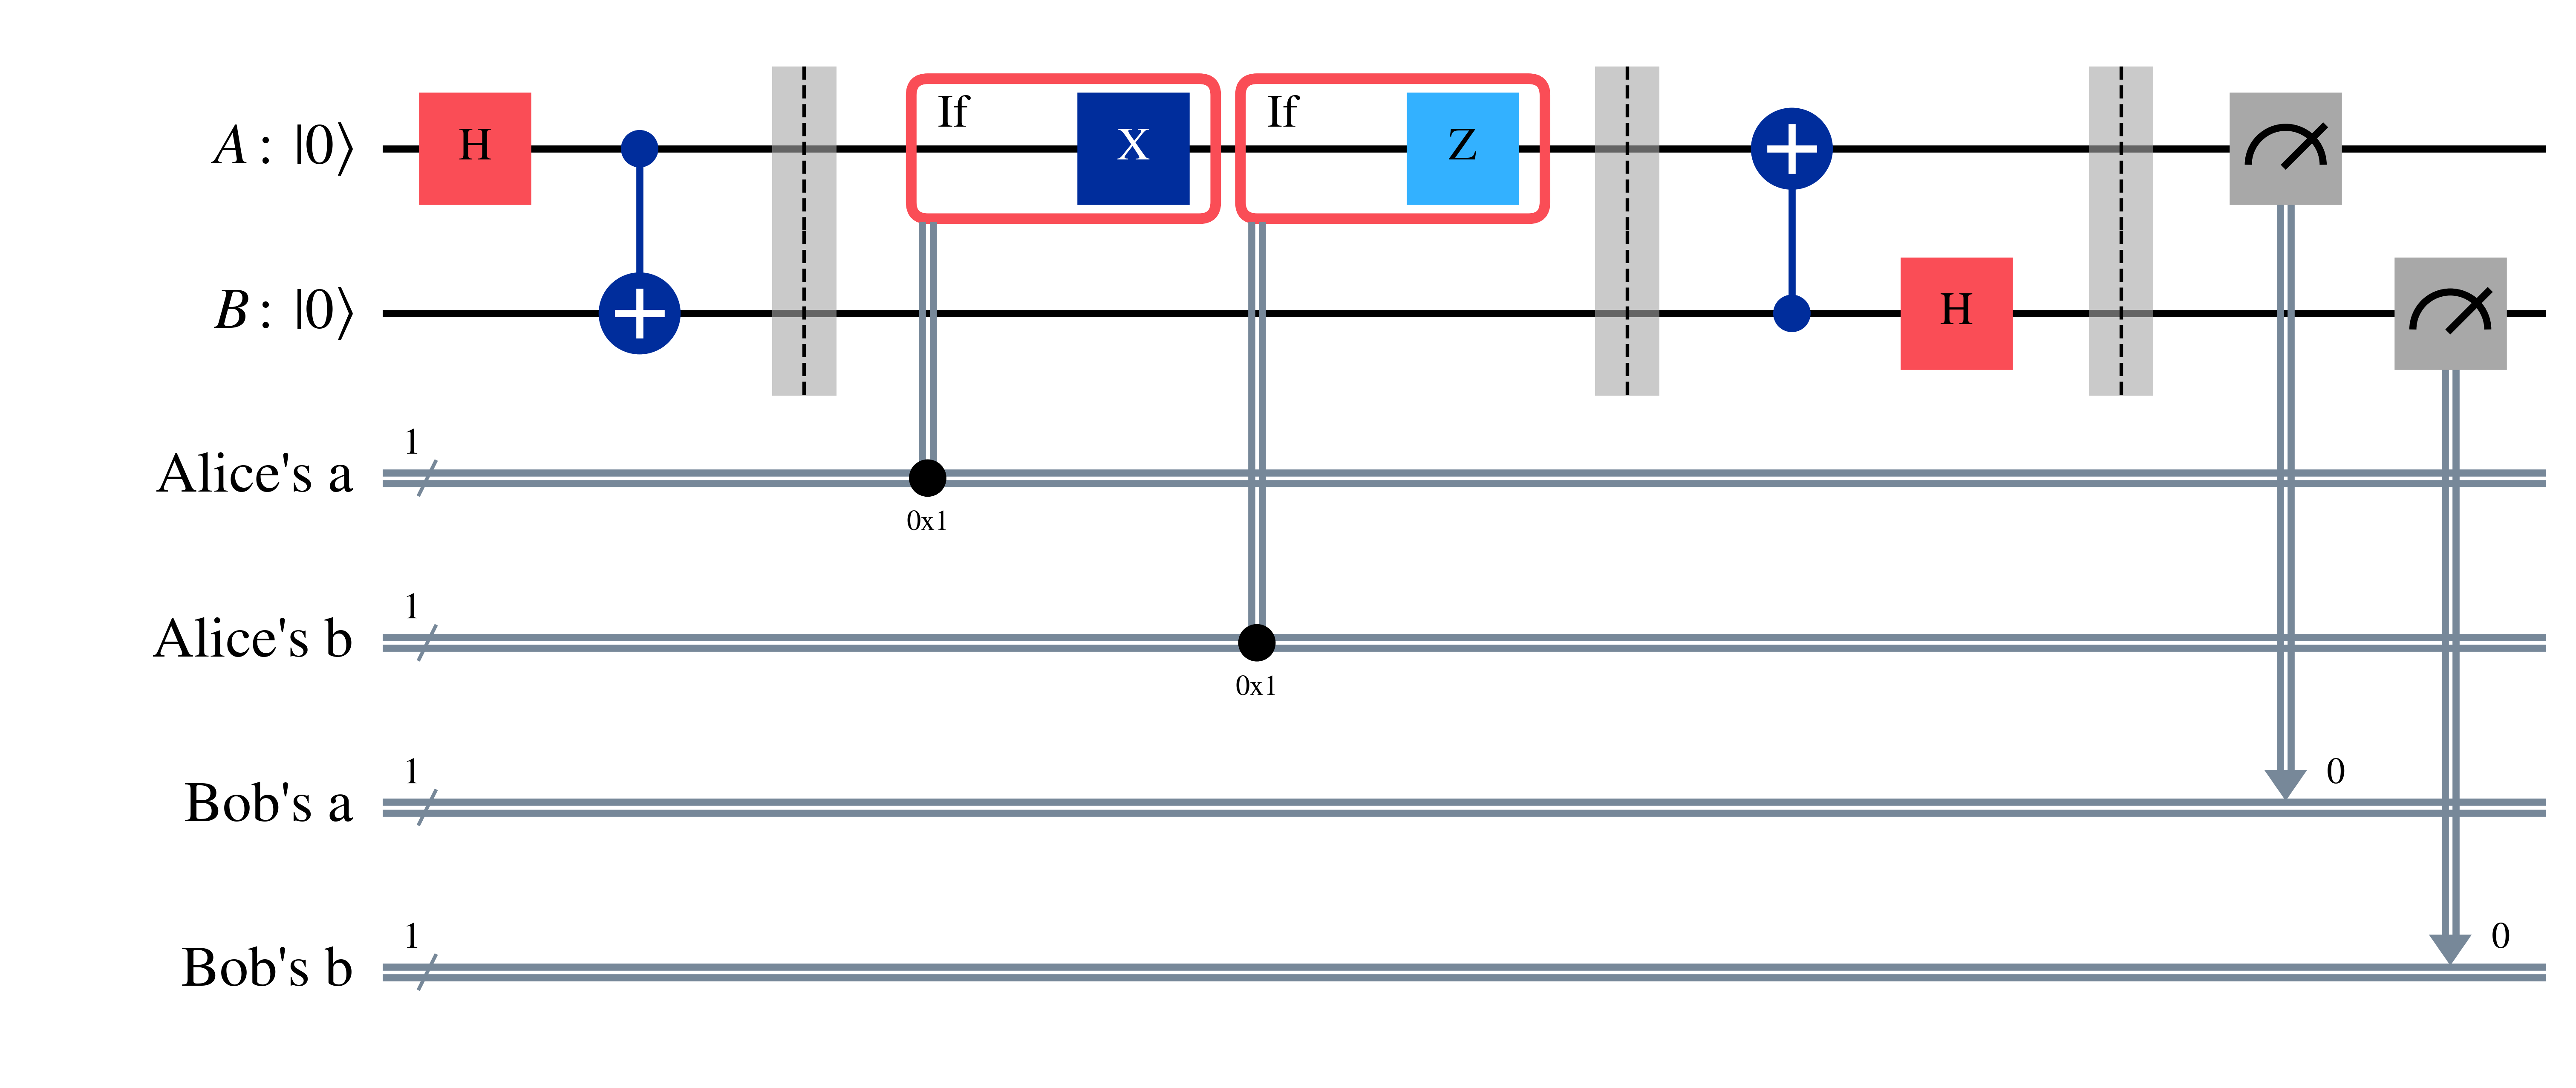

In [97]:
# Note, the folowing is based on code from https://quantum.cloud.ibm.com/learning/en/courses/basics-of-quantum-information/entanglement-in-action/qiskit-implementation
a = ClassicalRegister(1, "Alice's a")
b = ClassicalRegister(1, "Alice's b")
ebit0 = QuantumRegister(1, "A: |0⟩")
ebit1 = QuantumRegister(1, "B: |0⟩")
a_1 = ClassicalRegister(1, "Bob's a")
b_1 = ClassicalRegister(1, "Bob's b")

protocol = QuantumCircuit(a, b, ebit0, ebit1, a_1, b_1)

# Prepare ebit used for superdense coding
protocol.h(0)
protocol.cx(0, 1)
protocol.barrier()

# Alice's operations
# if d == "1":
#     protocol.z(0)
# if c == "1":
#     protocol.x(0)
with protocol.if_test((a, 1)):
    protocol.x(ebit0)
with protocol.if_test((b, 1)):
    protocol.z(ebit0)
protocol.barrier()

# Bob's actions
protocol.cx(1, 0)
protocol.h(1)
protocol.barrier()
protocol.measure(ebit0, a_1)
protocol.measure(ebit1, b_1)

fig_qc = protocol.draw(output='mpl', scale =1.5)
fig_qc.savefig(figure_directory+'superdense_coding_annotated_circuit.png', bbox_inches='tight')


## Quantum Parallelism

The figures here are based on https://quantum.cloud.ibm.com/learning/en/modules/computer-science/deutsch-jozsa

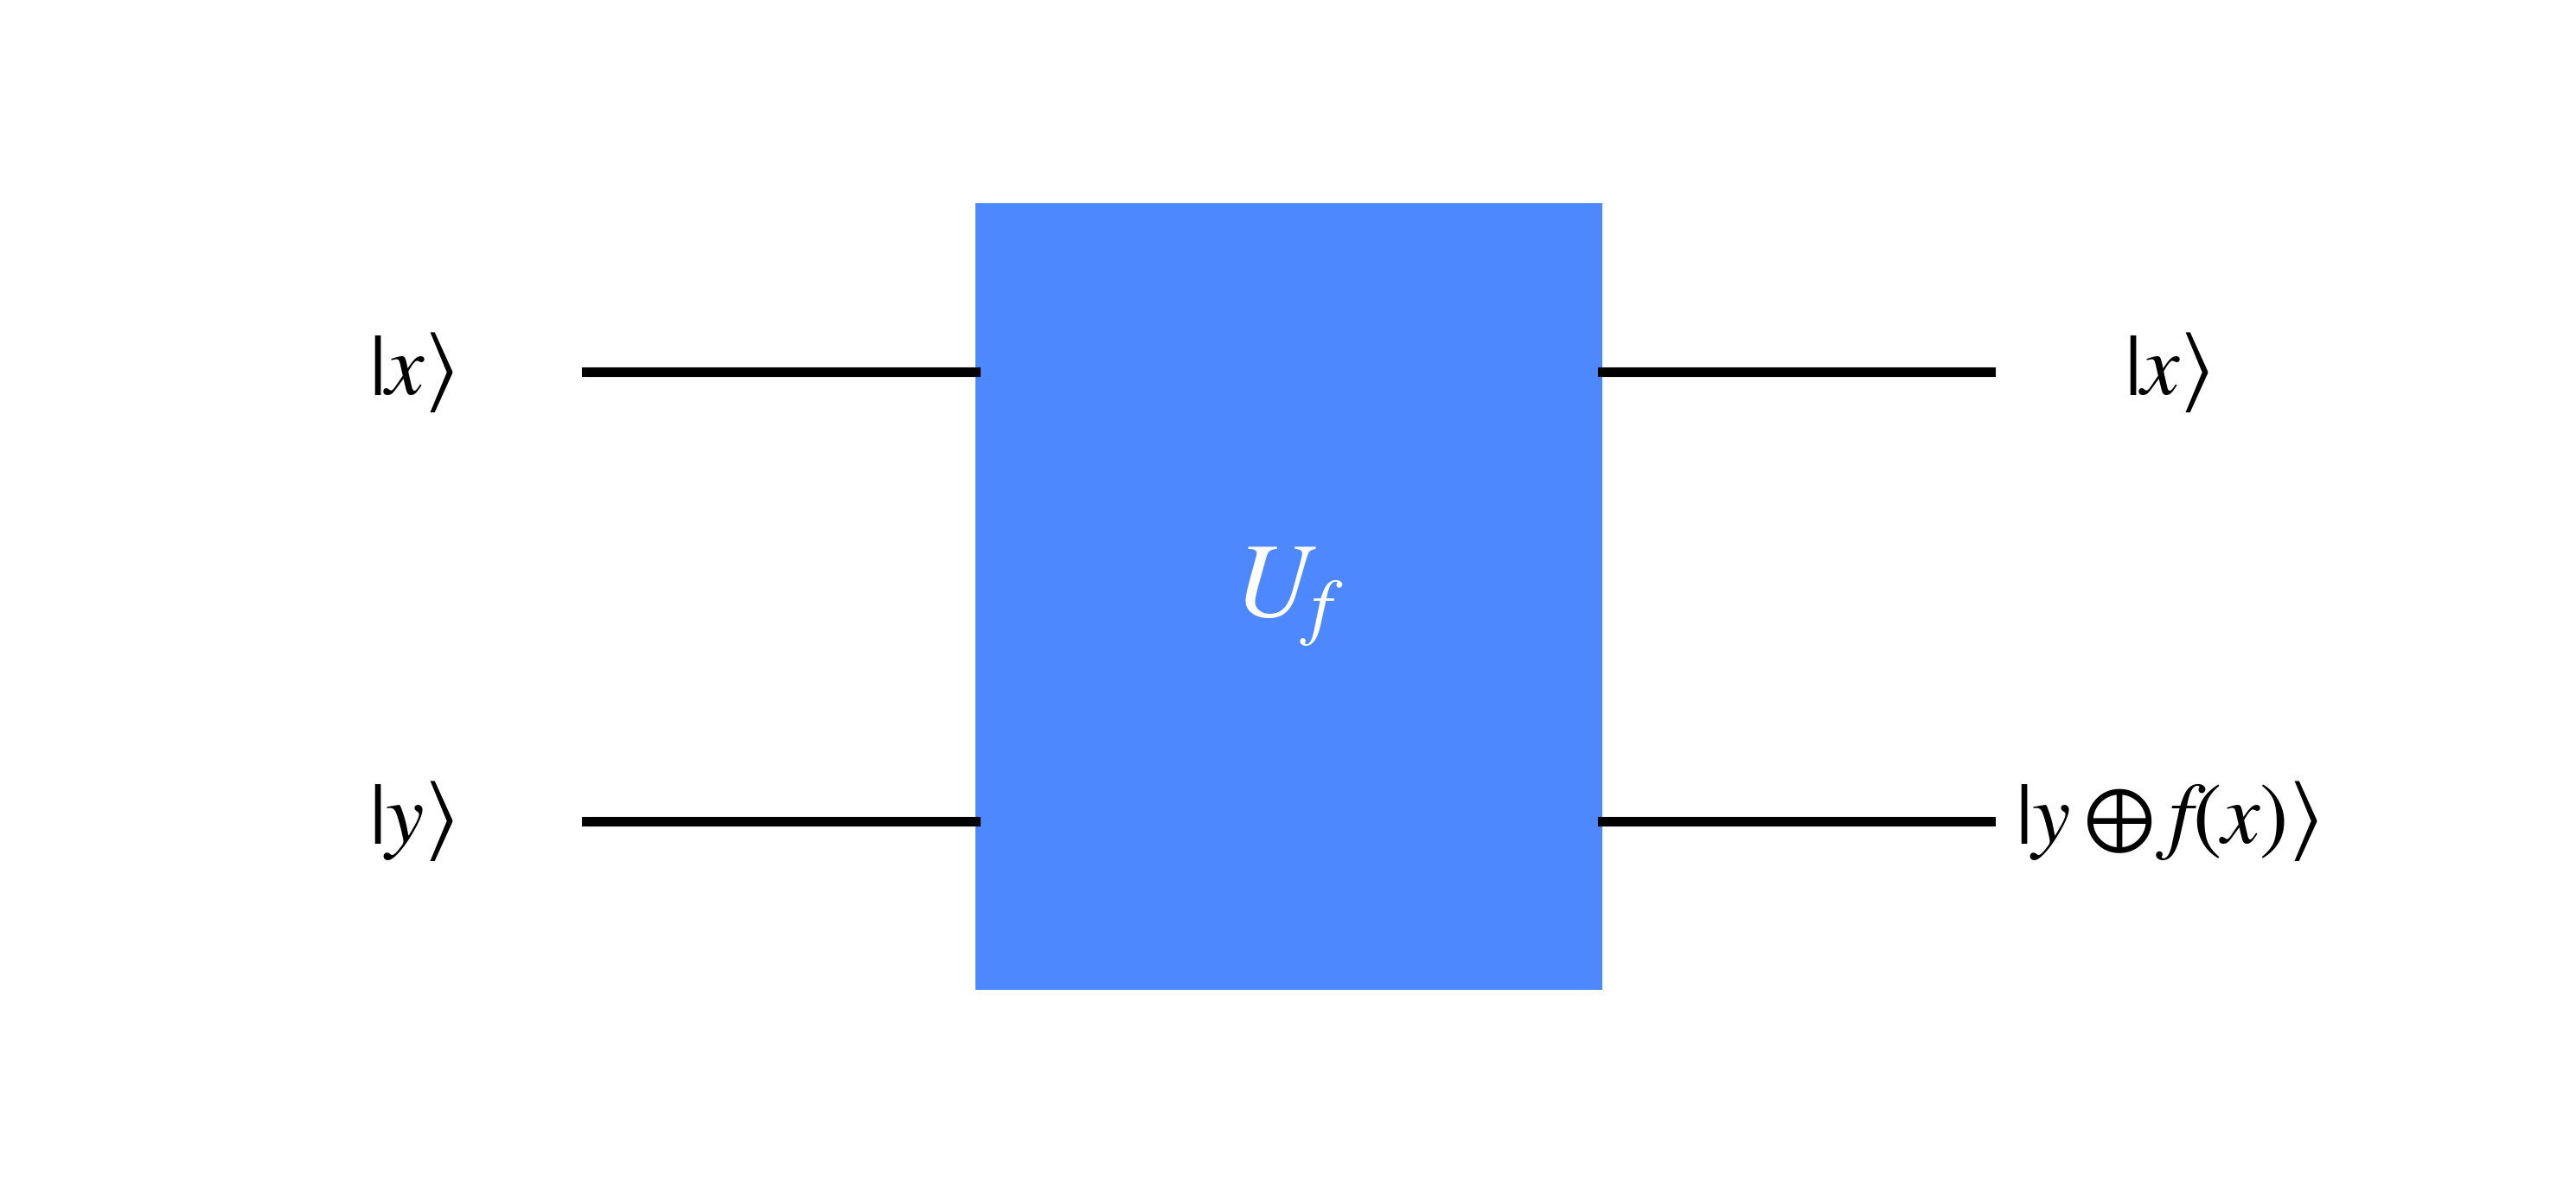

In [100]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np

# Set figure size for good aspect ratio and resolution
fig_width_inch = 8
fig_height_inch = 4

# Create figure and axis
fig, ax = plt.subplots(figsize=(fig_width_inch, fig_height_inch))

# Set axis limits to [0, 1] scale for clean coordinates
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)

# Hide axis spines, ticks, and labels to create a clean canvas
ax.axis('off')

# Set figure facecolor to white to match the input image background
fig.patch.set_facecolor('white')

# Define coordinate constants for elements
left_text_x = 0.15
left_line_start_x = 0.22
rect_start_x = 0.375
rect_width = 0.25
rect_center_x = 0.5
rect_end_x = 0.625
right_line_end_x = 0.78
right_text_x = 0.85

top_qubit_y = 0.7
bottom_qubit_y = 0.3
rect_start_y = 0.15
rect_height = 0.7
rect_center_y = 0.5

# Standard font size for diagram labels
font_size = 18

# Line thickness for qubit wires
line_thickness = 2.0

# Qubit lines (left side)
ax.plot([left_line_start_x, rect_start_x], [top_qubit_y, top_qubit_y], color='black', linewidth=line_thickness)
ax.plot([left_line_start_x, rect_start_x], [bottom_qubit_y, bottom_qubit_y], color='black', linewidth=line_thickness)

# Qubit lines (right side)
ax.plot([rect_end_x, right_line_end_x], [top_qubit_y, top_qubit_y], color='black', linewidth=line_thickness)
ax.plot([rect_end_x, right_line_end_x], [bottom_qubit_y, bottom_qubit_y], color='black', linewidth=line_thickness)

# Oracle block (blue rectangle)
# Pick a flat blue color similar to the original image.
# An RGB color is used for precision.
oracle_blue = (77/255, 136/255, 255/255)
oracle_block = patches.Rectangle((rect_start_x, rect_start_y), rect_width, rect_height, facecolor=oracle_blue, edgecolor='none')
ax.add_patch(oracle_block)

# Input text labels (left side)
# Use math font style for quantum states with bra-ket notation
ax.text(left_text_x, top_qubit_y, r'$|x\rangle$', ha='center', va='center', fontsize=font_size)
ax.text(left_text_x, bottom_qubit_y, r'$|y\rangle$', ha='center', va='center', fontsize=font_size)

# Output text labels (right side)
# Use math font style for quantum states with bra-ket notation and XOR symbol
ax.text(right_text_x, top_qubit_y, r'$|x\rangle$', ha='center', va='center', fontsize=font_size)
ax.text(right_text_x, bottom_qubit_y, r'$|y \oplus f(x)\rangle$', ha='center', va='center', fontsize=font_size)

# Text inside the oracle block
# Center text is placed inside the rectangle
ax.text(rect_center_x, rect_center_y, r'$U_f$', ha='center', va='center', color='white', fontsize=font_size + 4, fontweight='bold')

# Optimize layout to remove whitespace
plt.tight_layout()

# Display the plot
#plt.show()
plt.savefig(figure_directory+'two_qubit_oracle_sketch.png')


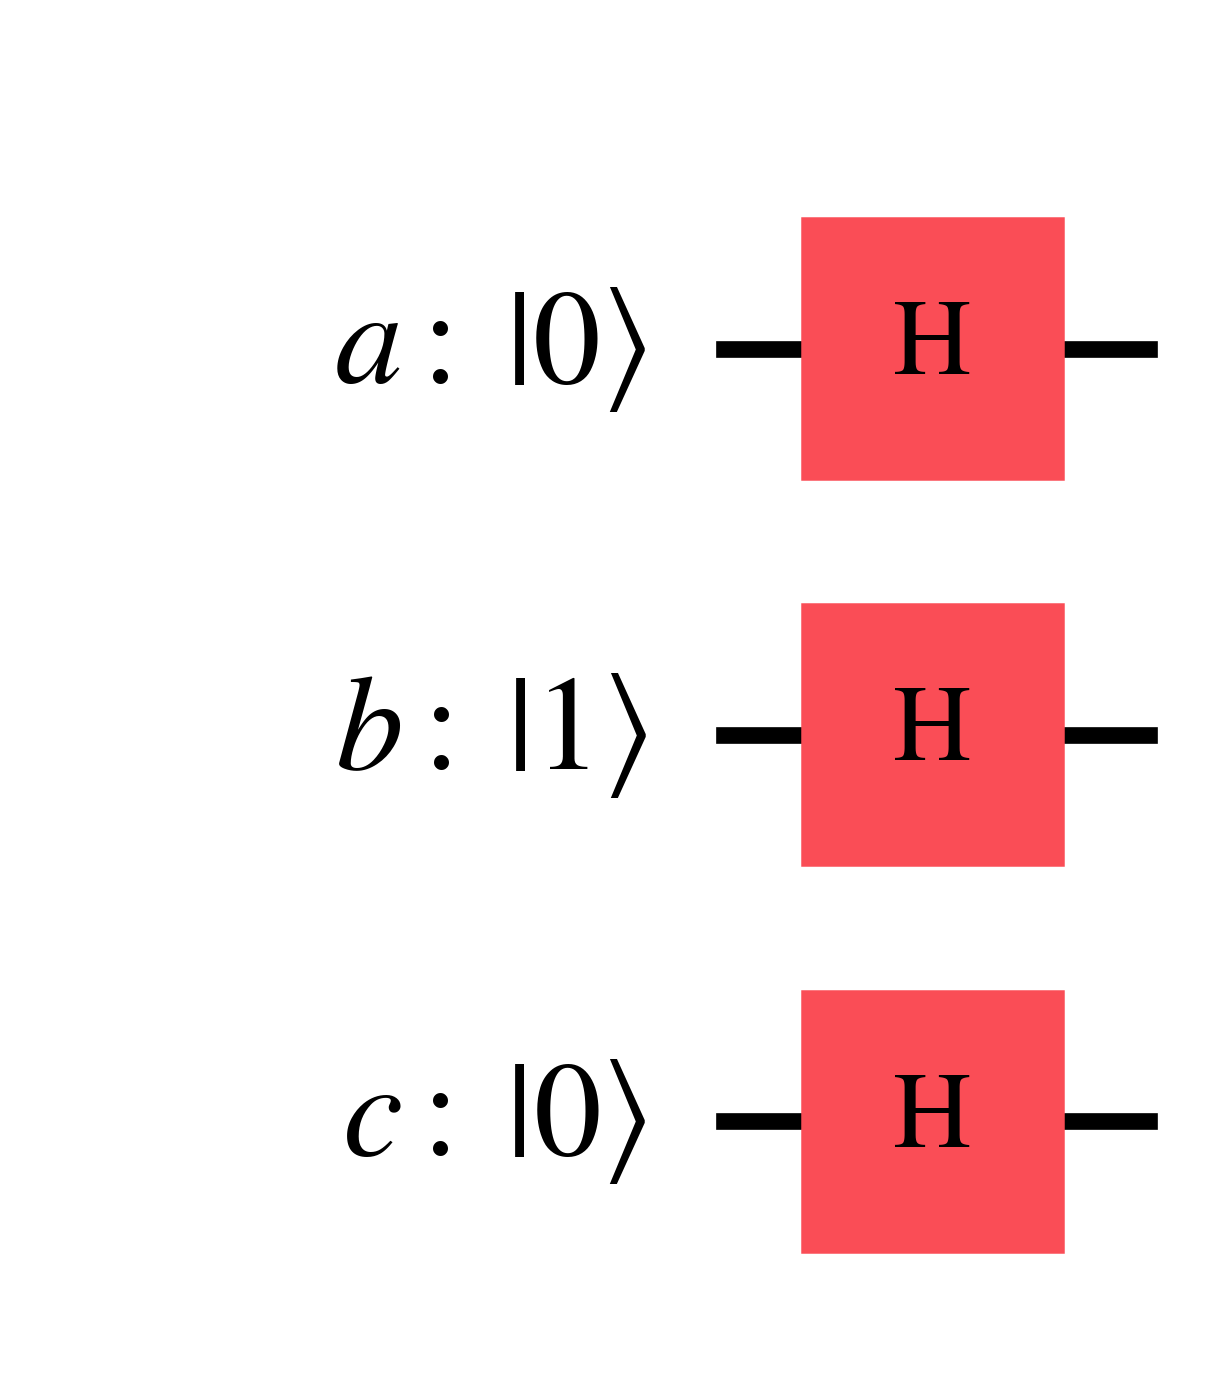

In [107]:
a= QuantumRegister(1, "a: |0⟩")
b= QuantumRegister(1, "b: |1⟩")
c= QuantumRegister(1, "c: |0⟩")
qc=QuantumCircuit(a,b,c)

qc.h(0)
qc.h(1)
qc.h(2)

fig_qc = qc.draw(output='mpl', scale =1.5)
fig_qc.savefig(figure_directory+'three_qubit_hadamard_transform', bbox_inches='tight')

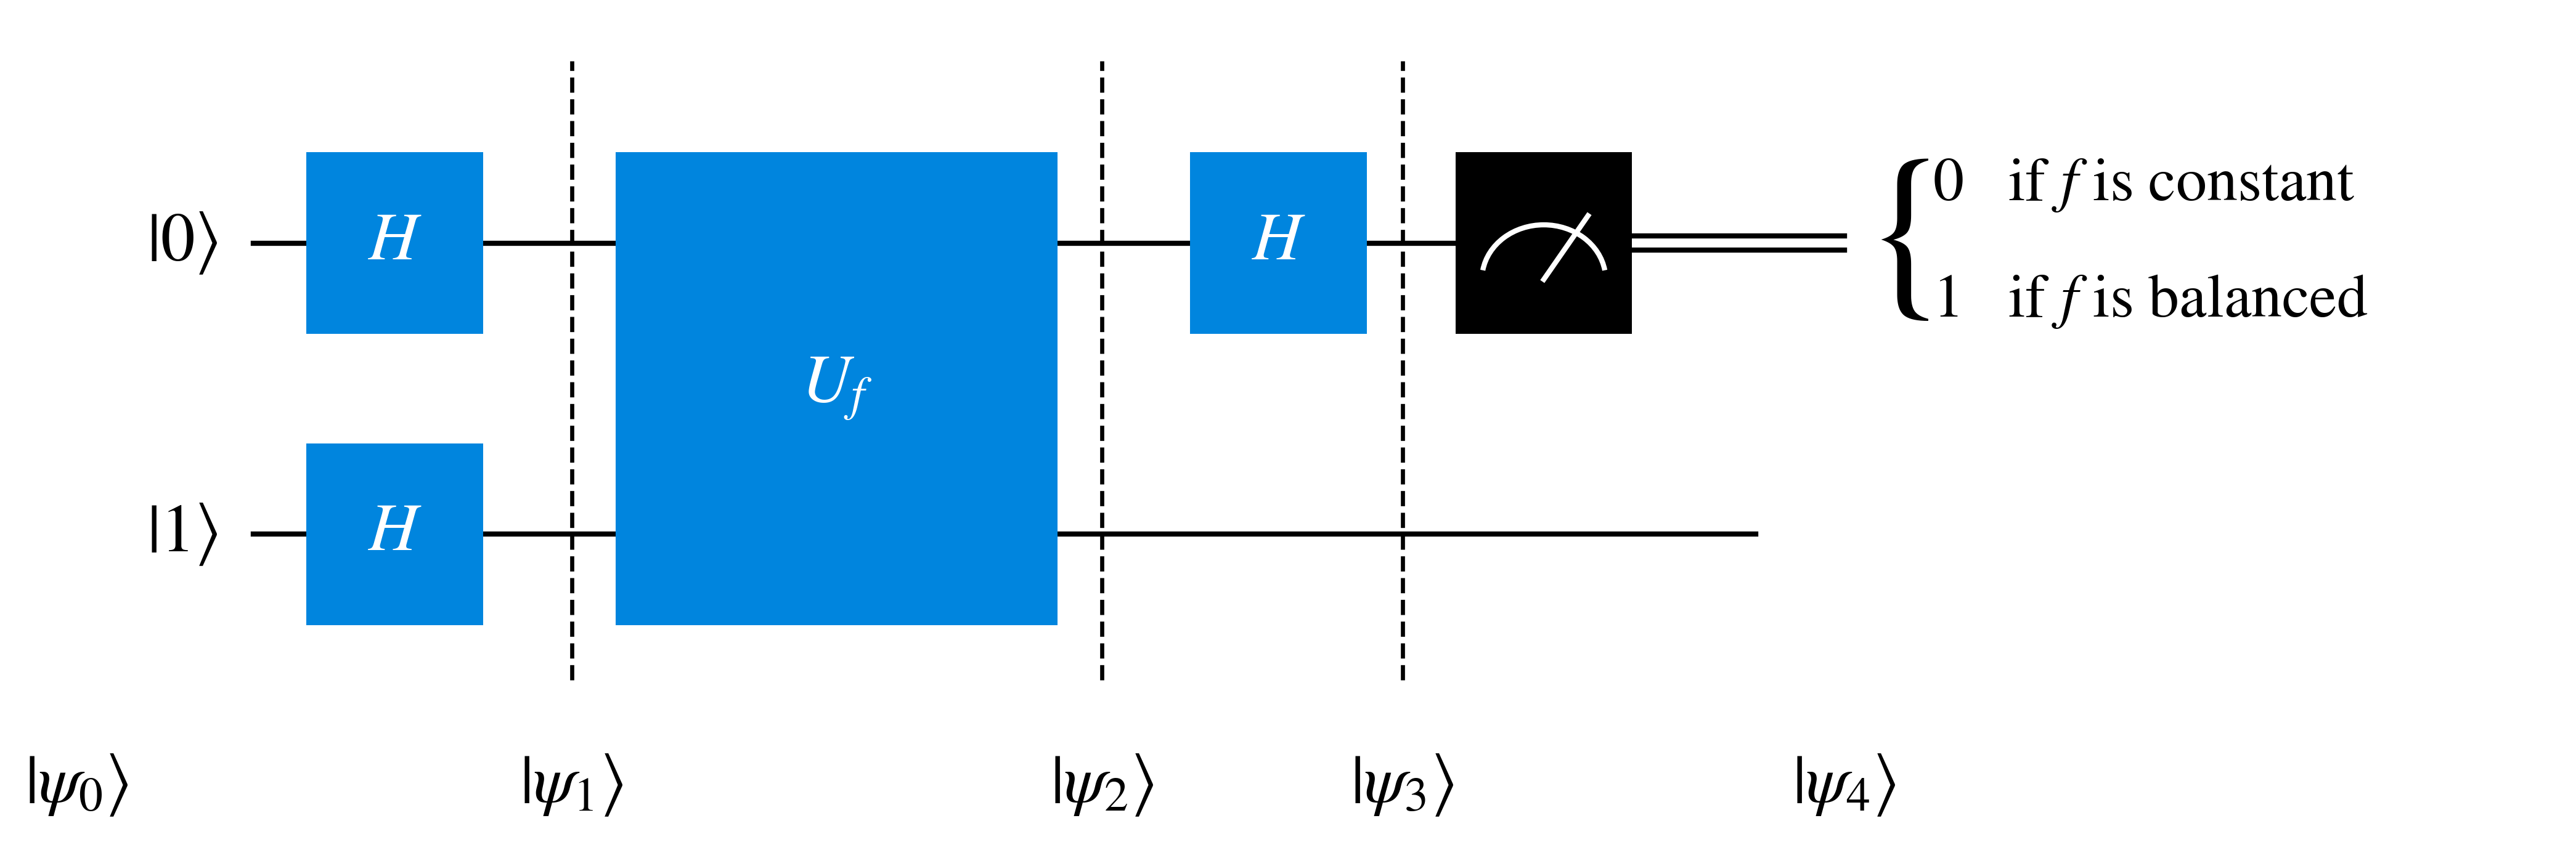

In [131]:
# Note: the following figure made use of AI assistance.
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# Force Matplotlib to use STIX for mathematical text rendering
plt.rcParams['mathtext.fontset'] = 'stix'
plt.rcParams['font.family'] = 'STIXGeneral'

def draw_deutsch_circuit(filename="deutsch_algorithm_sketch.png"):
    # Set up the figure and axis
    fig, ax = plt.subplots(figsize=(11, 4))
    
    # Coordinate system limits
    ax.set_xlim(0, 1.4)
    ax.set_ylim(-0.1, 1.0)
    ax.axis('off')

    # Colors
    BLUE = '#0085DE'  # Close match to the blue in the image
    BLACK = 'black'

    # ==========================================
    # HELPER FUNCTIONS
    # ==========================================
    def draw_gate(x, y, text, width=0.1, height=0.25):
        rect = patches.Rectangle((x - width/2, y - height/2), width, height, facecolor=BLUE, zorder=3)
        ax.add_patch(rect)
        ax.text(x, y, text, color='white', fontsize=20, ha='center', va='center', zorder=4)

    def draw_meter(x, y, width=0.1, height=0.25):
        rect = patches.Rectangle((x - width/2, y - height/2), width, height, facecolor=BLACK, zorder=3)
        ax.add_patch(rect)
        # Dial arc
        arc = patches.Arc((x, y - height/5), width*0.7, height*0.6, theta1=20, theta2=160, color='white', lw=1.5, zorder=4)
        ax.add_patch(arc)
        # Needle
        ax.plot([x, x + width*0.25], [y - height/5, y + height*0.15], color='white', lw=1.5, zorder=4)

    # ==========================================
    # 1. WIRES & INITIAL STATES
    # ==========================================
    y_top = 0.7
    y_bottom = 0.3
    
    # Qubit lines
    ax.plot([0.1, 0.85], [y_top, y_top], color=BLACK, lw=1.5, zorder=1)
    ax.plot([0.1, 0.95], [y_bottom, y_bottom], color=BLACK, lw=1.5, zorder=1)

    # Initial States
    ax.text(0.08, y_top, r'$|0\rangle$', fontsize=20, ha='right', va='center')
    ax.text(0.08, y_bottom, r'$|1\rangle$', fontsize=20, ha='right', va='center')

    # ==========================================
    # 2. GATES
    # ==========================================
    # First layer H gates
    draw_gate(0.18, y_top, r'$H$')
    draw_gate(0.18, y_bottom, r'$H$')

    # Oracle U_f
    # Positioned between the wires, covering both
    draw_gate(0.43, 0.5, r'$U_f$', width=0.25, height=0.65)

    # Second layer H gate (Top wire only)
    draw_gate(0.68, y_top, r'$H$')

    # Measurement Meter
    draw_meter(0.83, y_top)

    # ==========================================
    # 3. CLASSICAL OUTPUT & BRACE
    # ==========================================
    # Double lines coming out of the meter
    gap = 0.02
    ax.plot([0.88, 1.0], [y_top + gap/2, y_top + gap/2], color=BLACK, lw=1.5)
    ax.plot([0.88, 1.0], [y_top - gap/2, y_top - gap/2], color=BLACK, lw=1.5)

    # Large curly brace and result text
    ax.text(1.01, y_top, r'$\{$', fontsize=55, va='center', ha='left')
    ax.text(1.05, y_top + 0.08, r'$0 \quad \mathrm{if} \ f \ \mathrm{is \ constant}$', fontsize=18, va='center', ha='left')
    ax.text(1.05, y_top - 0.08, r'$1 \quad \mathrm{if} \ f \ \mathrm{is \ balanced}$', fontsize=18, va='center', ha='left')

    # ==========================================
    # 4. DASHED LINES & PSI LABELS
    # ==========================================
    # X coordinates for the three vertical barriers
    barrier_xs = [0.28, 0.58, 0.75]
    
    ax.text(0, 0.0, fr'$|\psi_{0}\rangle$', fontsize=20, ha='center', va='top')
    ax.text(1, 0.0, fr'$|\psi_{4}\rangle$', fontsize=20, ha='center', va='top')
    for i, x_pos in enumerate(barrier_xs):
        # Draw dashed line
        ax.plot([x_pos, x_pos], [0.1, 0.95], color=BLACK, linestyle='--', lw=1.2, zorder=1)
        # Add requested \psi state label below
        ax.text(x_pos, 0.0, fr'$|\psi_{i+1}\rangle$', fontsize=20, ha='center', va='top')

    # Save and show
    plt.tight_layout()
    plt.savefig(figure_directory+filename, bbox_inches='tight', pad_inches=0.1)
    plt.show()

# Run the function
draw_deutsch_circuit()

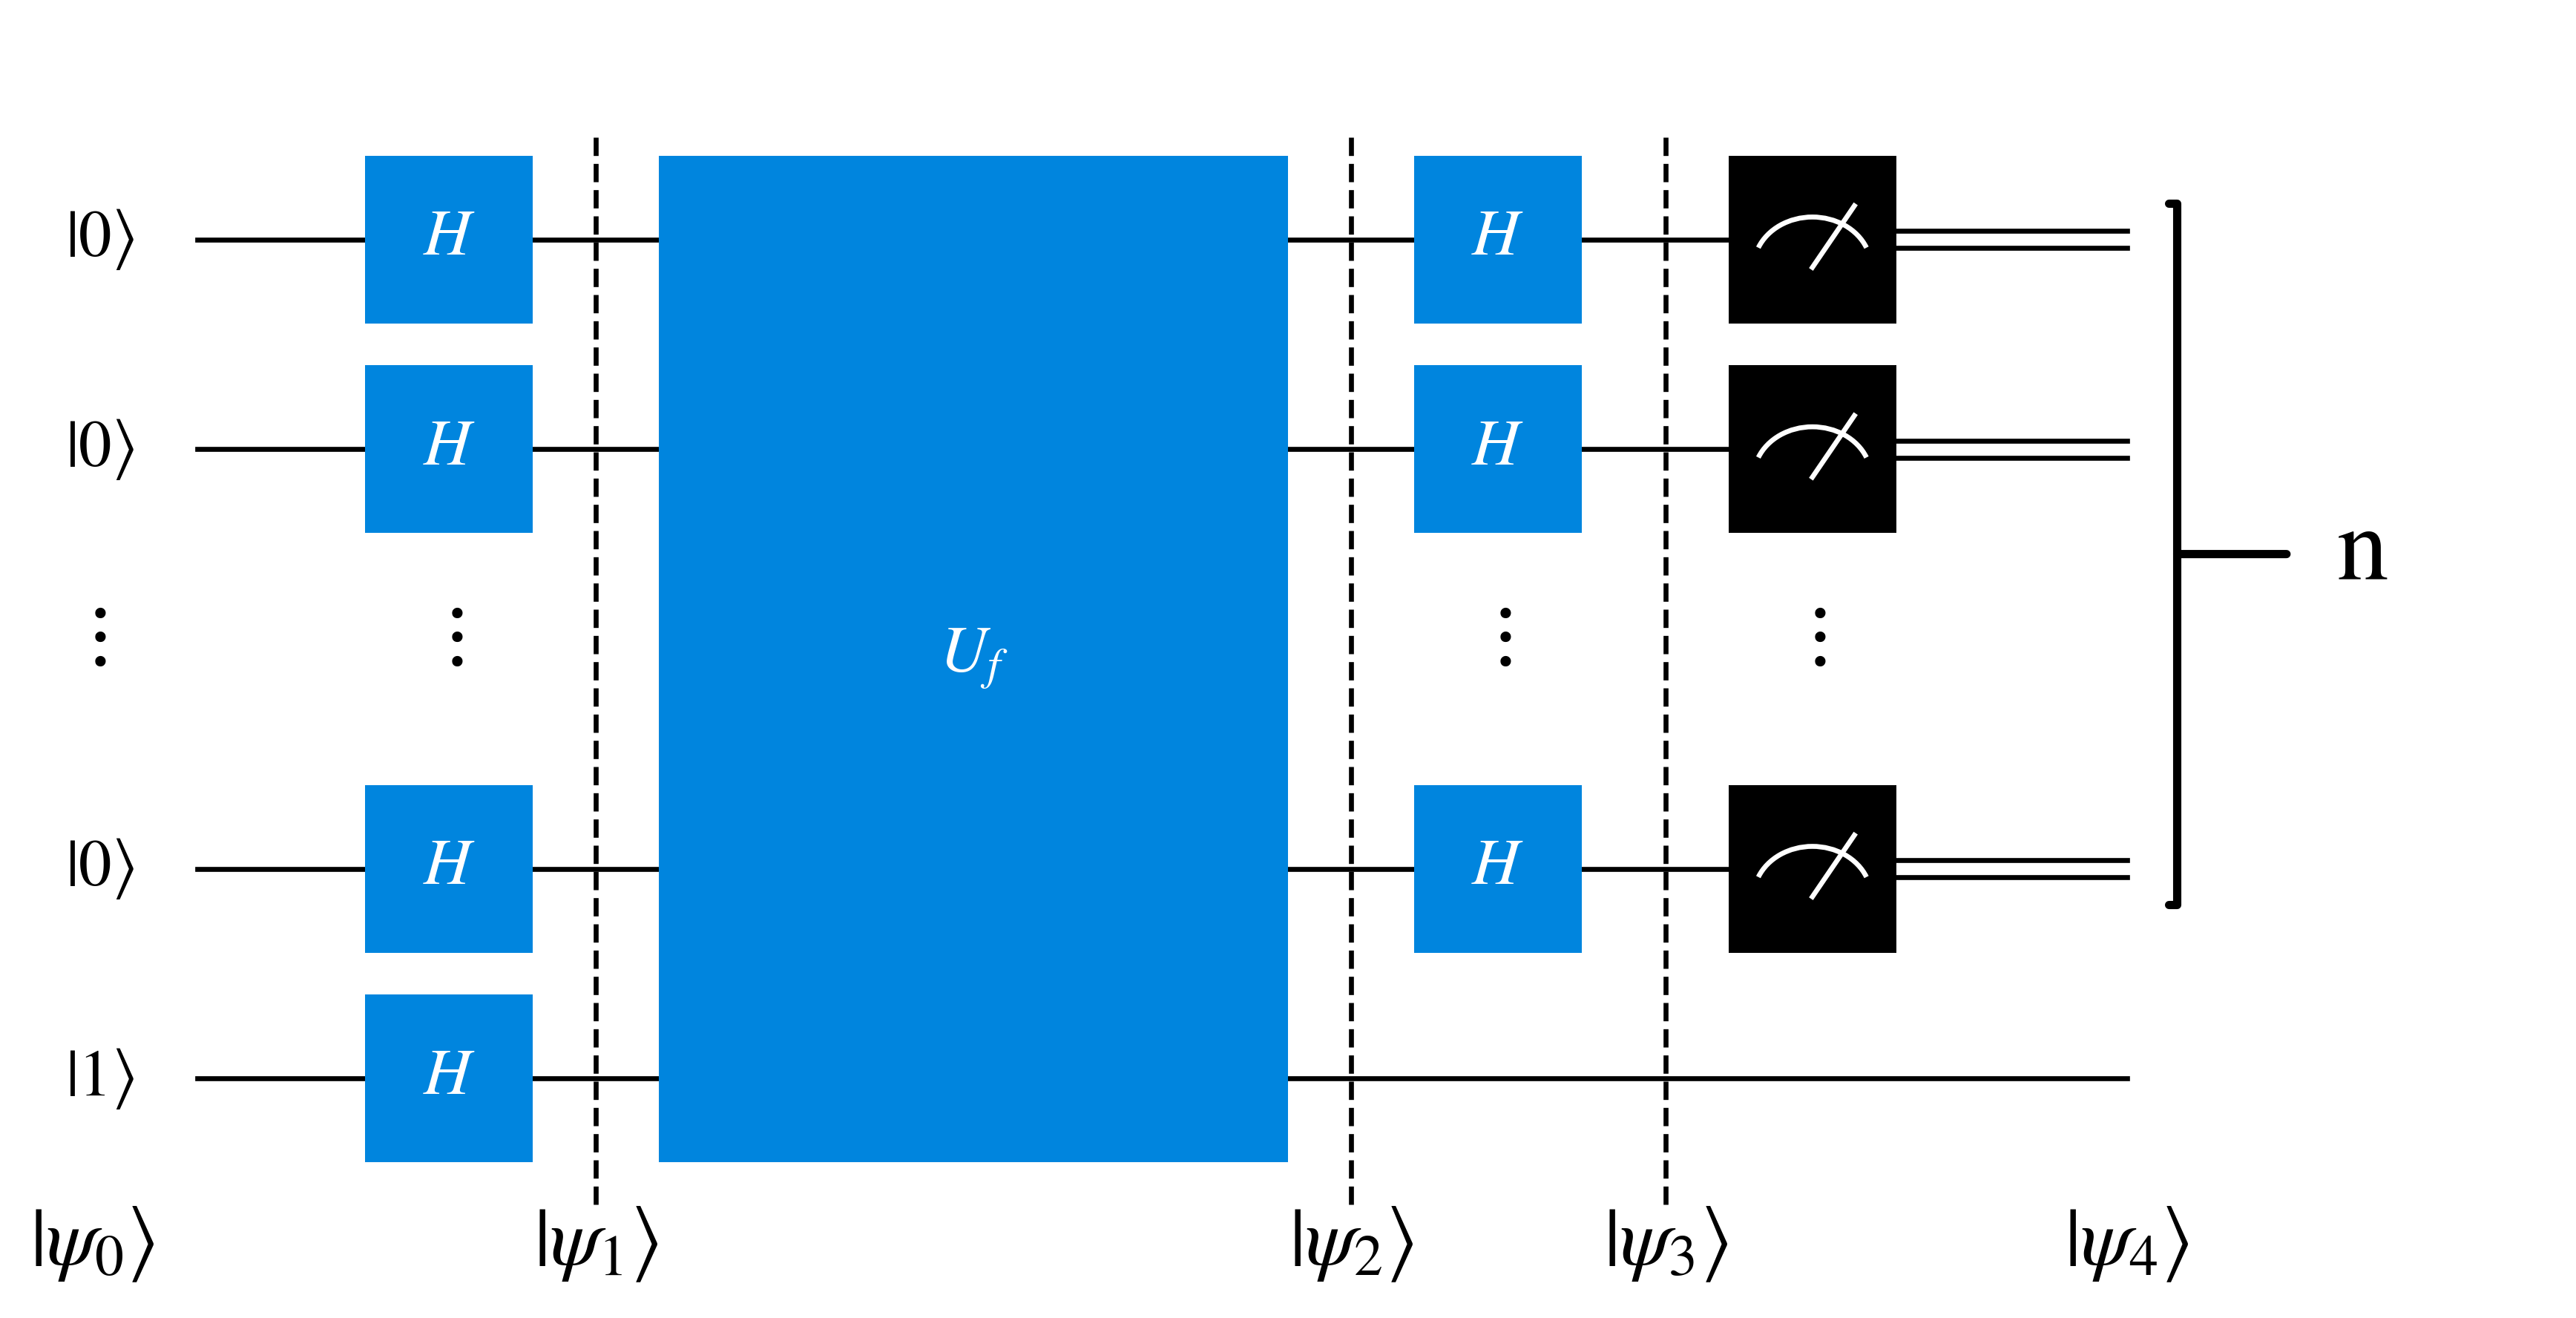

In [138]:
# Note: the following figure made use of AI assistance.
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# Force Matplotlib to use STIX for mathematical text rendering
plt.rcParams['mathtext.fontset'] = 'stix'
plt.rcParams['font.family'] = 'STIXGeneral'

def draw_n_qubit_circuit(filename="n_qubit_algorithm.png"):
    # Set up the figure and axis
    fig, ax = plt.subplots(figsize=(10, 5))
    
    # Coordinate system limits
    ax.set_xlim(0, 12)
    ax.set_ylim(-1, 5)
    ax.axis('off')
    ax.set_aspect('equal') # Keeps gates perfectly square

    # Colors
    BLUE = '#0085DE'  # Close match to the blue in the image
    BLACK = 'black'

    # ==========================================
    # HELPER FUNCTIONS
    # ==========================================
    def draw_gate(x, y, text, w=0.8, h=0.8, color=BLUE):
        rect = patches.Rectangle((x - w/2, y - h/2), w, h, facecolor=color, zorder=3)
        ax.add_patch(rect)
        ax.text(x, y, text, color='white', fontsize=16, ha='center', va='center', zorder=4)

    def draw_meter(x, y, w=0.8, h=0.8):
        rect = patches.Rectangle((x - w/2, y - h/2), w, h, facecolor=BLACK, zorder=3)
        ax.add_patch(rect)
        # Dial arc
        arc = patches.Arc((x, y - h/6), w*0.7, h*0.6, theta1=20, theta2=160, color='white', lw=1.2, zorder=4)
        ax.add_patch(arc)
        # Needle
        ax.plot([x, x + w*0.25], [y - h/6, y + h*0.2], color='white', lw=1.2, zorder=4)

    def draw_double_line(x_start, x_end, y, gap=0.08):
        ax.plot([x_start, x_end], [y + gap/2, y + gap/2], color=BLACK, lw=1.2, zorder=1)
        ax.plot([x_start, x_end], [y - gap/2, y - gap/2], color=BLACK, lw=1.2, zorder=1)

    # ==========================================
    # 1. WIRES & INITIAL STATES
    # ==========================================
    y_top_wires = [4, 3, 1]
    y_bottom_wire = 0
    y_dots = 2

    x_start_labels = 0.5
    x_wire_start = 0.8
    x_H1 = 2.0
    x_Uf = 4.5
    x_H2 = 7.0
    x_meter = 8.5
    x_wire_end = 10.0

    # Draw solid lines
    for y in y_top_wires:
        ax.plot([x_wire_start, x_meter], [y, y], color=BLACK, lw=1.2, zorder=1)
        draw_double_line(x_meter, x_wire_end, y)
        ax.text(x_start_labels, y, r'$|0\rangle$', fontsize=16, ha='right', va='center')

    # Bottom wire
    ax.plot([x_wire_start, x_wire_end], [y_bottom_wire, y_bottom_wire], color=BLACK, lw=1.2, zorder=1)
    ax.text(x_start_labels, y_bottom_wire, r'$|1\rangle$', fontsize=16, ha='right', va='center')

    # ==========================================
    # 2. GATES
    # ==========================================
    # First layer H gates (applies to all wires)
    for y in y_top_wires + [y_bottom_wire]:
        draw_gate(x_H1, y, r'$H$')

    # Oracle U_f block (spanning all wires)
    draw_gate(x_Uf, 2, r'$U_f$', w=3.0, h=4.8)

    # Second layer H gates and Meters (applies to top wires only)
    for y in y_top_wires:
        draw_gate(x_H2, y, r'$H$')
        draw_meter(x_meter, y)

    # ==========================================
    # 3. ELLIPSES (Dots)
    # ==========================================
    # Place vertical ellipses to represent the n-qubits
    dot_x_positions = [x_start_labels - 0.2, x_H1, x_H2, x_meter]
    for x in dot_x_positions:
        ax.text(x, y_dots + 0.1, r'$\vdots$', fontsize=20, ha='center', va='center')

    # ==========================================
    # 4. CURLY BRACE & OUTPUT TEXT
    # ==========================================
    # Using a large font size for the curly brace
    #ax.text(10.1, 2.5, r'$\}$', fontsize=85, color='black', va='center', ha='left')
    bracket_arrow_style = patches.ArrowStyle.BracketB(widthB=85.0, lengthB=2, angleB=0)
    arrow = patches.FancyArrowPatch(posA=(10.8, 2.5),posB=(10.2, 2.5), arrowstyle=bracket_arrow_style, linewidth=2, color='black')
    ax.add_patch(arrow)
    ax.text(11, 2.5, r'n', fontsize=25, va='center', ha='left')



        # X coordinates for the three vertical barriers
    barrier_xs = [2.7, 6.3, 7.8]
    
    ax.text(0.3, -0.6, fr'$|\psi_{0}\rangle$', fontsize=20, ha='center', va='top')
    ax.text(10, -0.6, fr'$|\psi_{4}\rangle$', fontsize=20, ha='center', va='top')
    for i, x_pos in enumerate(barrier_xs):
        # Draw dashed line
        ax.plot([x_pos, x_pos], [-0.6, 4.5], color=BLACK, linestyle='--', lw=1.2, zorder=1)
        # Add requested \psi state label below
        ax.text(x_pos, -0.6, fr'$|\psi_{i+1}\rangle$', fontsize=20, ha='center', va='top')

    # Save and display
    plt.tight_layout()
    plt.savefig(figure_directory+filename, bbox_inches='tight', pad_inches=0.1)
    plt.show()

# Execute the drawing function
draw_n_qubit_circuit('deutsch_jozsa_algorithm_sketch.png')

# Quantum Fourier Transform
## Fourier Transform

The Fourier Transform is a centrally important and widely used mathematical tool. In the case of signal processing of an audio or electromagnetic wave, it can convert a signal which varies in time (also called the 'time domain') into a visualisation of the component frequencies (called the 'frequency domain').

To better understand this, it's worth demonstrating superposition by superimposing waveforms as seen below

Success! Diagram demonstrating superposition saved to waveform_superposition_demonstration.png


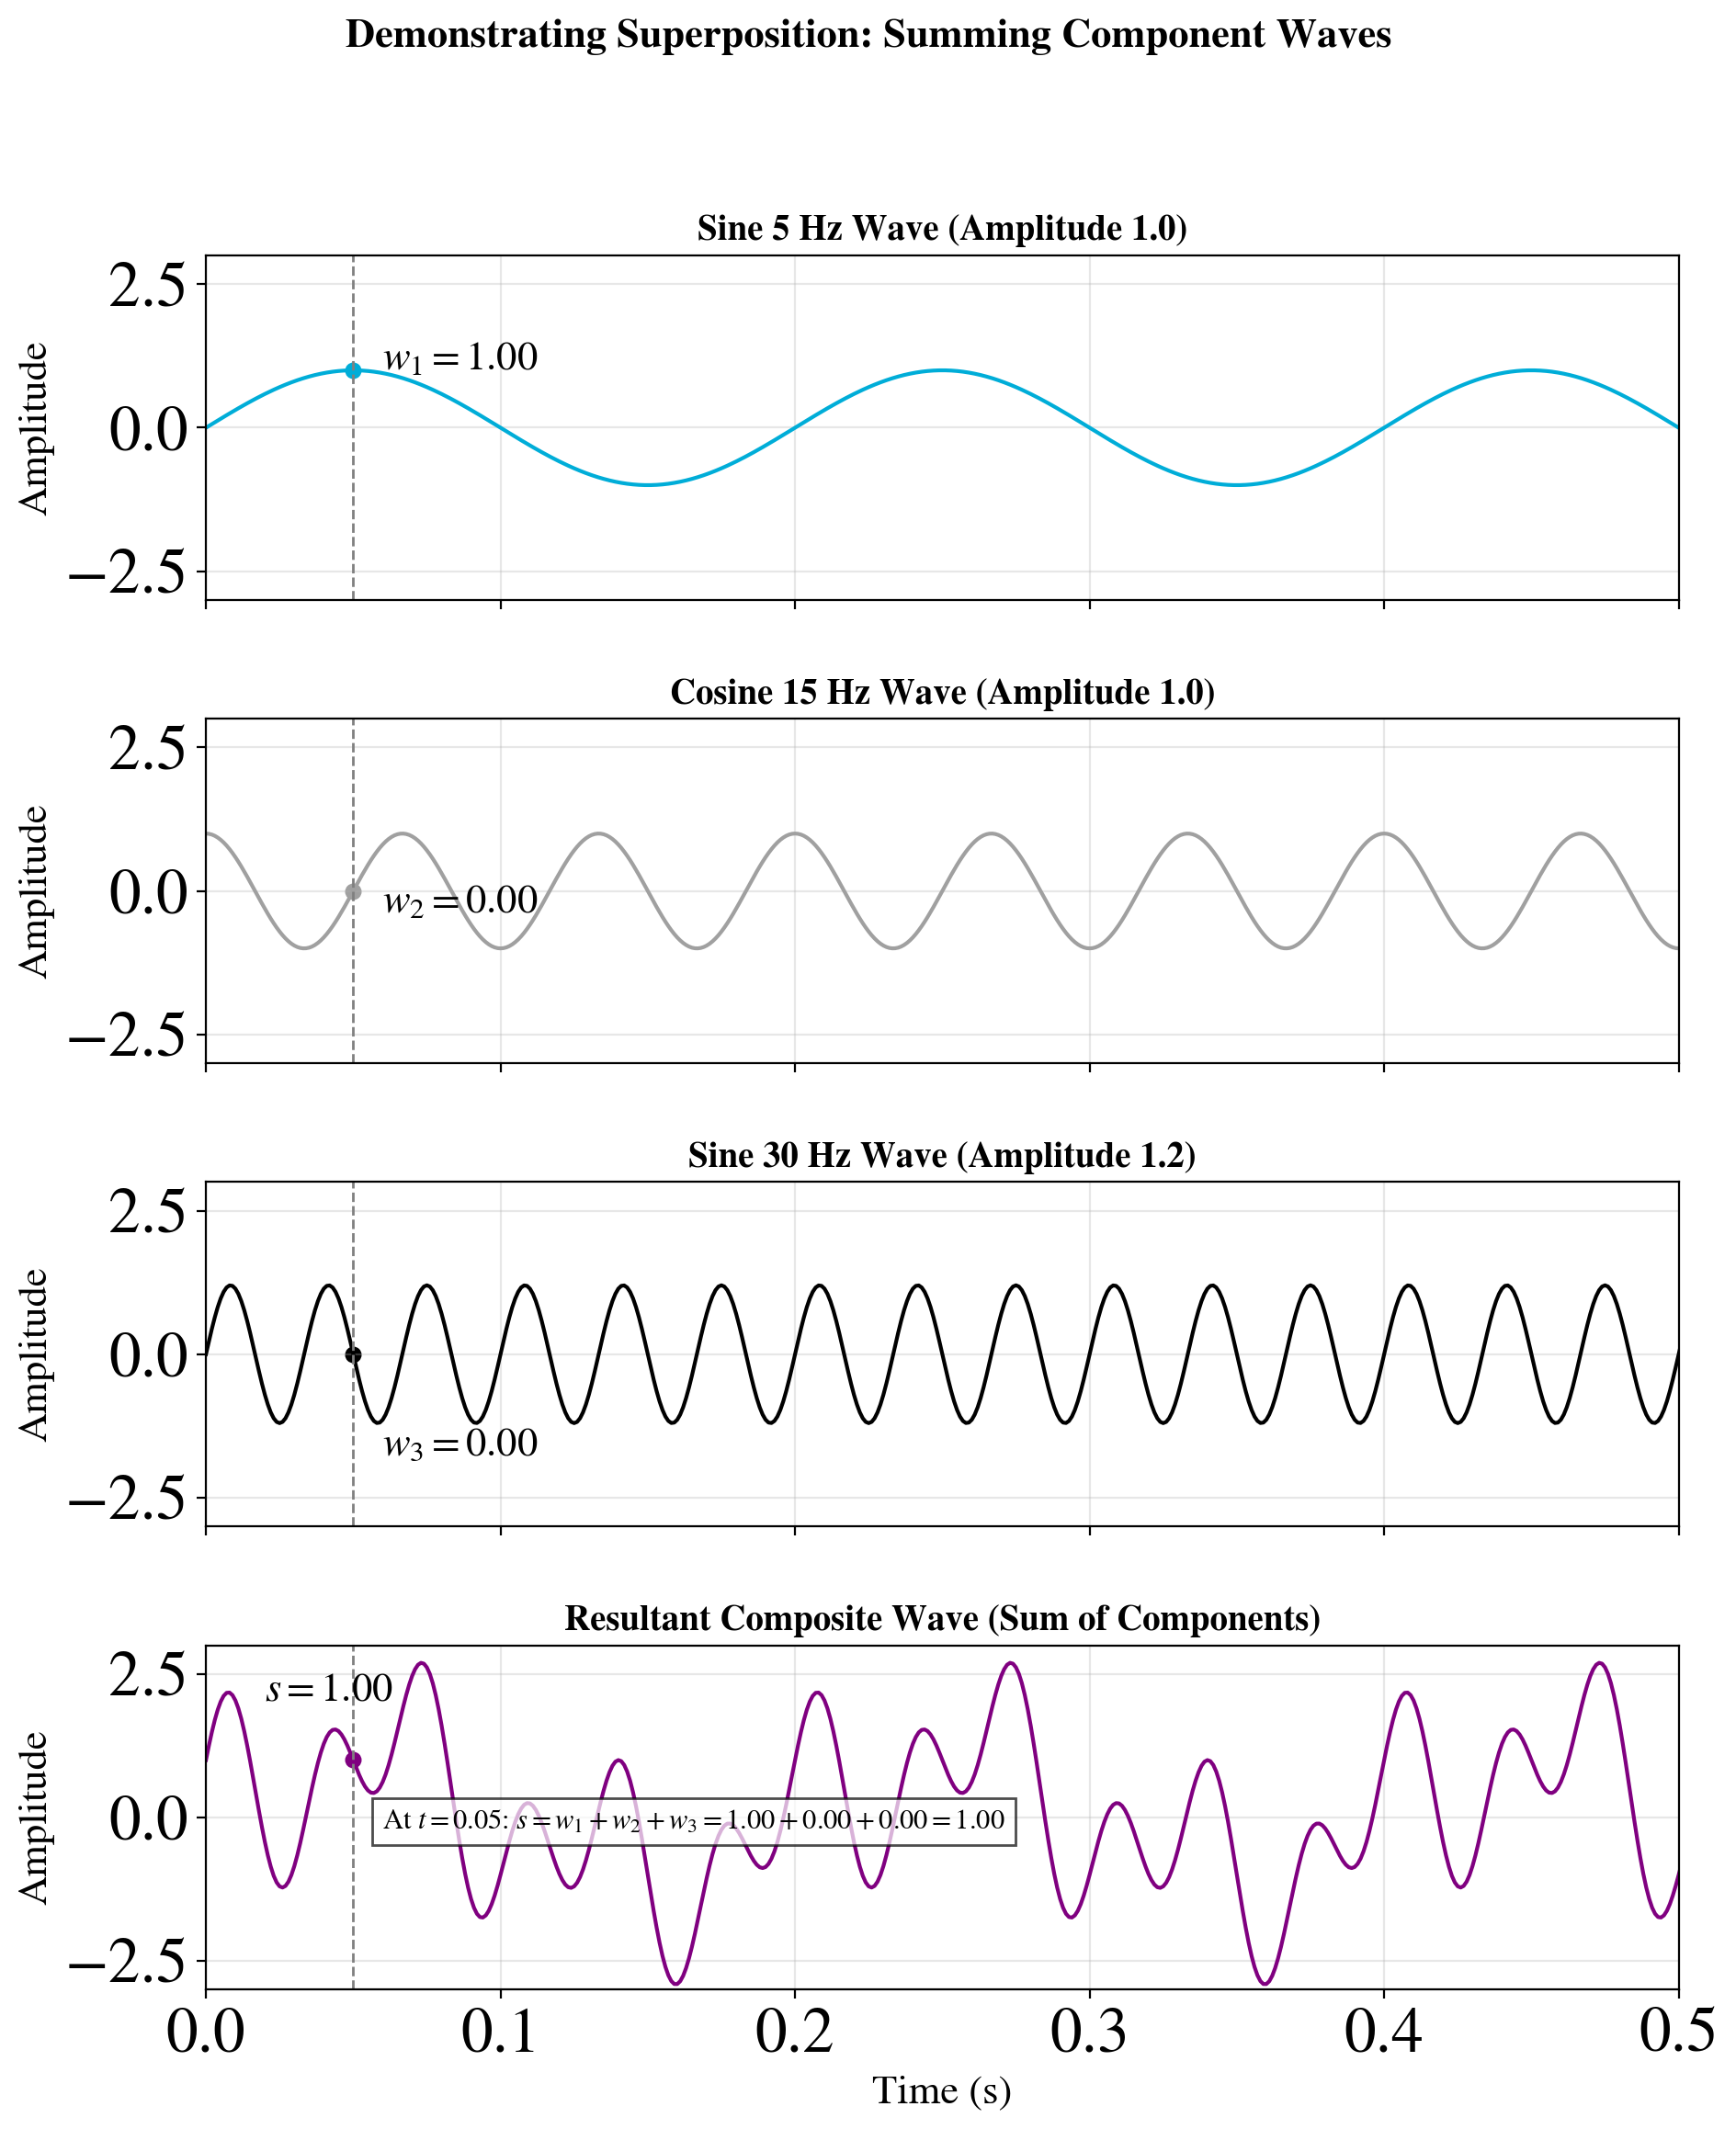

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# Optional: use STIX font to give the plot a math textbook aesthetic
plt.rcParams['mathtext.fontset'] = 'stix'
plt.rcParams['font.family'] = 'STIXGeneral'

def plot_superposition_illustrative(filename="waveform_superposition_demonstration.png"):
    fig, axs = plt.subplots(4, 1, figsize=(10, 12), dpi=200, sharex=True)

    # Parameters: Sampling freq, duration, time vector
    fs = 1000  # 1000 Hz sampling
    duration = 1.0 # 1 second duration
    t = np.linspace(0, duration, int(fs*duration), endpoint=False)

    # Individual wave components (same frequencies and amplitudes as before)
    # Generic description for visual tuning: use standard plotting functions for clean visual and distinctive colors for different waves and the resultant sum.
    w1 = 1.0 * np.sin(2 * np.pi * 5 * t)
    w2 = 1.0 * np.cos(2 * np.pi * 15 * t)
    w3 = 1.2 * np.sin(2 * np.pi * 30 * t)
    
    # Calculate resultant composite wave (Principle of Superposition)
    resultant = w1 + w2 + w3

    # Define vertical offset for illustration text/markers
    annotate_offset = 0.01
    
    # Determine points for t=0.05s calculation/annotation
    t_annotate = 0.05
    idx = int(t_annotate * fs) # index for t=0.05s for fs=1000, duration=1s
    y1_annotate = w1[idx]
    y2_annotate = 0.00# w2[idx]
    y3_annotate = w3[idx]
    yres_annotate = resultant[idx]
    # Calculate exact sum to avoid placeholders and maintain precision
    calculated_sum = y1_annotate + y2_annotate + y3_annotate

    # generic functional descriptions in annotations labels: Highlight specific point and display calculated values.
    # generic visual style description implicitly followed: Vertical lines/markers help clarify context.
    
    # 1. 5 Hz Component Plot
    axs[0].plot(t, w1, color='#00ADD8', lw=1.5) # generic description: use distinctive color for different component waves for visually clear separation.
    axs[0].set_title("Sine 5 Hz Wave (Amplitude 1.0)", fontsize=14, fontweight='bold')
    axs[0].set_ylabel("Amplitude", fontsize=16)
    axs[0].set_ylim(-3, 3)
    axs[0].grid(True, alpha=0.3)
    axs[0].axvline(t_annotate, color='gray', linestyle='--', lw=1) # generic description: use visual aid for time correlation across plots.
    axs[0].scatter(t_annotate, y1_annotate, color='#00ADD8', s=30)
    axs[0].text(t_annotate + annotate_offset, y1_annotate+0.2, f'$w_1={y1_annotate:.2f}$', va='center', fontsize=16, fontweight='bold')

    # 2. 15 Hz Component Plot
    axs[1].plot(t, w2, color='#A0A0A0', lw=1.5) # generic description: use another distinctive color for visually clear separation.
    axs[1].set_title("Cosine 15 Hz Wave (Amplitude 1.0)", fontsize=14, fontweight='bold')
    axs[1].set_ylabel("Amplitude", fontsize=16)
    axs[1].set_ylim(-3, 3)
    axs[1].grid(True, alpha=0.3)
    axs[1].axvline(t_annotate, color='gray', linestyle='--', lw=1) # generic description: use visual aid for time correlation across plots.
    axs[1].scatter(t_annotate, y2_annotate, color='#A0A0A0', s=30)
    axs[1].text(t_annotate + annotate_offset, y2_annotate-0.2, f'$w_2={y2_annotate:.2f}$', va='center', fontsize=16, fontweight='bold')

    # 3. 30 Hz Component Plot
    axs[2].plot(t, w3, color='black', lw=1.5) # generic description: use another distinctive color for visually clear separation.
    axs[2].set_title("Sine 30 Hz Wave (Amplitude 1.2)", fontsize=14, fontweight='bold')
    axs[2].set_ylabel("Amplitude", fontsize=16)
    axs[2].set_ylim(-3, 3)
    axs[2].grid(True, alpha=0.3)
    axs[2].axvline(t_annotate, color='gray', linestyle='--', lw=1) # generic description: use visual aid for time correlation across plots.
    axs[2].scatter(t_annotate, y3_annotate, color='black', s=30)
    axs[2].text(t_annotate + annotate_offset, y3_annotate-1.6, f'$w_3={y3_annotate:.2f}$', va='center', fontsize=16, fontweight='bold')

    # 4. Resultant Composite Wave Plot
    axs[3].plot(t, resultant, color='#800080', lw=1.5) # generic description: use yet another distinctive color for visually prominent resultant wave display.
    axs[3].set_title("Resultant Composite Wave (Sum of Components)", fontsize=14, fontweight='bold')
    axs[3].set_ylabel("Amplitude", fontsize=16)
    axs[3].set_ylim(-3, 3)
    axs[3].set_xlabel("Time (s)", fontsize=16)
    axs[3].set_xlim(0, 0.5) # generic description: zoom in contextually to see wave details and annotations clearly. sharex handles previous plots.
    axs[3].grid(True, alpha=0.3)
    axs[3].axvline(t_annotate, color='gray', linestyle='--', lw=1) # generic description: use visual aid for time correlation across plots.
    axs[3].scatter(t_annotate, yres_annotate, color='#800080', s=30)
    axs[3].text(t_annotate - 0.03, yres_annotate+1.2, f'$s={yres_annotate:.2f}$', va='center', fontsize=16, fontweight='bold')

    # generic functional description in annotation labels: Annotate values with rounding to derived contextual data.
    # Add an explicit superposition annotation near the selected point
    annotation_text = f"At $t=0.05$: $s = w_1 + w_2 + w_3 = {y1_annotate:.2f} + {y2_annotate:.2f} + {y3_annotate:.2f} = {calculated_sum:.2f}$"
    axs[3].text(t_annotate + annotate_offset , yres_annotate -1.2, annotation_text, fontsize=11, ha='left', bbox=dict(facecolor='white', alpha=0.7))

    fig.suptitle("Demonstrating Superposition: Summing Component Waves", fontsize=16, fontweight='bold', y=0.98)
    plt.tight_layout(rect=[0, 0, 1, 0.97])
    plt.savefig(figure_directory+filename, bbox_inches='tight', pad_inches=0.1)
    print(f"Success! Diagram demonstrating superposition saved to {filename}")

plot_superposition_illustrative()

The Fourier transform of a sine wave leads to the following fourier spectrum

Success! Plot saved as fourier_spectrum_for_sine_wave.png


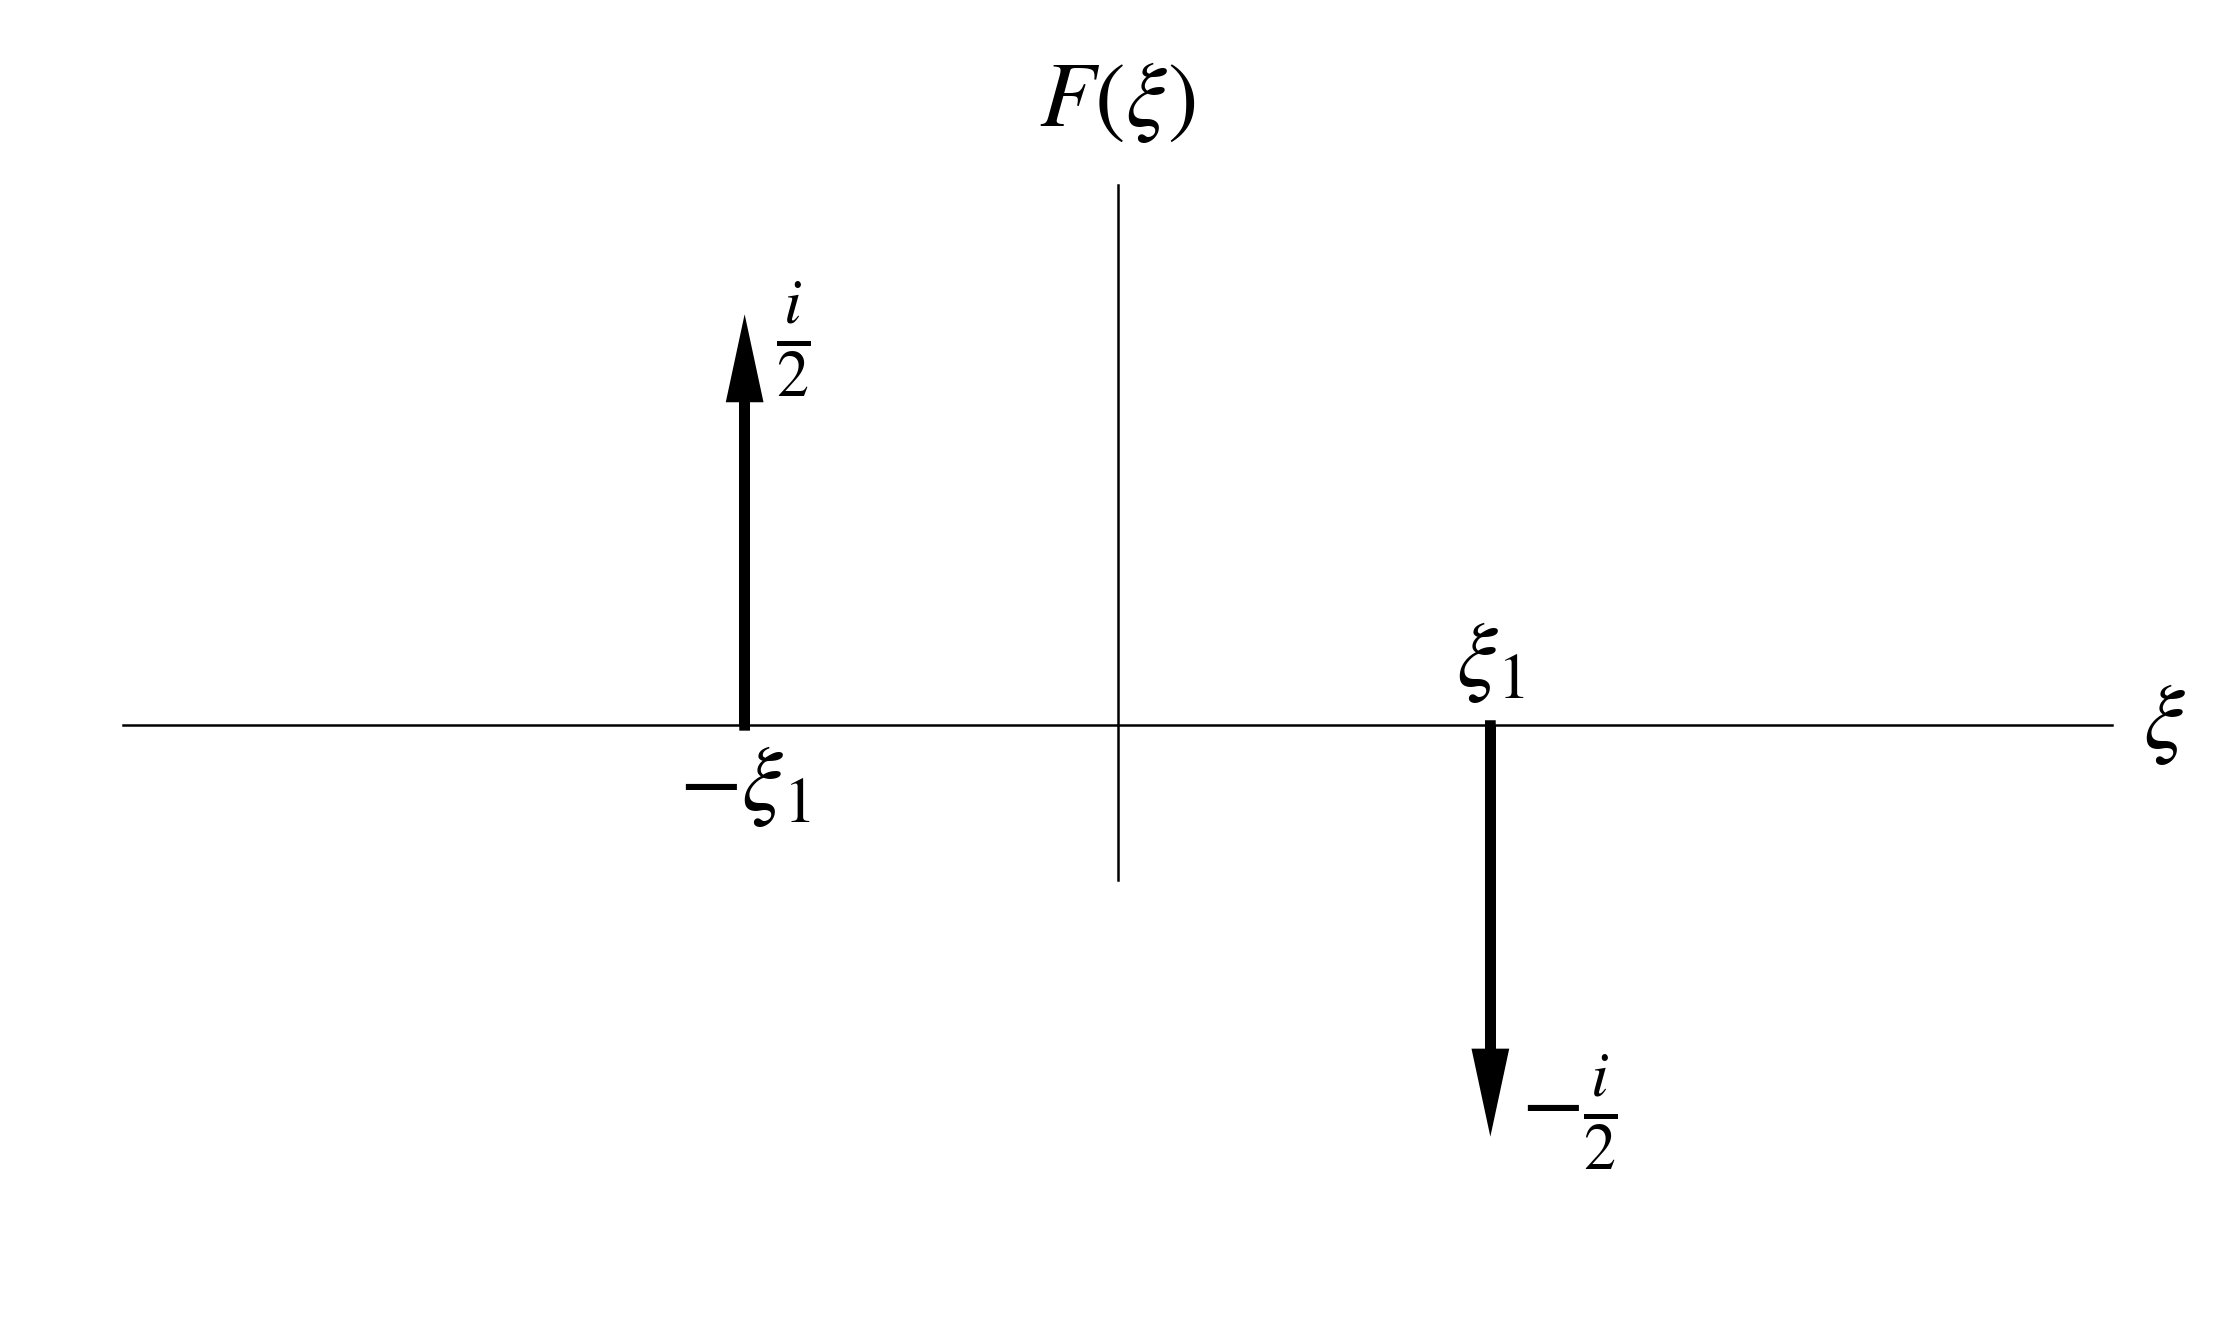

In [10]:
import matplotlib.pyplot as plt

# Force Matplotlib to use STIX for mathematical text rendering
plt.rcParams['mathtext.fontset'] = 'stix'
plt.rcParams['font.family'] = 'STIXGeneral'

def draw_fourier_spectrum(filename="fourier_spectrum_for_sine_wave.png"):
    fig, ax = plt.subplots(figsize=(8, 5), dpi=300)

    # Set axis limits for proper padding and aspect ratio
    ax.set_xlim(-3.5, 3.5)
    ax.set_ylim(-1.5, 1.8)

    # Hide all default axes/spines to draw custom ones
    ax.axis('off')

    # ==========================================
    # 1. DRAW AXES
    # ==========================================
    # Horizontal axis (omega)
    ax.plot([-3.2, 3.2], [0, 0], color='black', lw=0.6)
    ax.text(3.3, 0, r'$\xi$', fontsize=22, ha='left', va='center')

    # Vertical axis (F(omega))
    # Stops slightly below the origin to match the reference image
    ax.plot([0, 0], [-0.4, 1.4], color='black', lw=0.6)
    ax.text(0, 1.5, r'$F(\xi)$', fontsize=22, ha='center', va='bottom')

    # ==========================================
    # 2. DRAW IMPULSES (ARROWS)
    # ==========================================
    # Left impulse pointing up
    ax.arrow(-1.2, 0, 0, 1, 
             head_width=0.08, head_length=0.15, 
             fc='black', ec='black', lw=2.5, 
             length_includes_head=True, zorder=3)
             
    # Right impulse pointing down
    ax.arrow(1.2, 0, 0, -1, 
             head_width=0.08, head_length=0.15, 
             fc='black', ec='black', lw=2.5, 
             length_includes_head=True, zorder=3)

    # ==========================================
    # 3. ADD LABELS WITH REQUESTED CHANGES
    # ==========================================
    # Left impulse labels
    ax.text(-1.1, 1.0, r'$\frac{i}{2}$', fontsize=22, ha='left', va='center')
    ax.text(-1.2, -0.05, r'$-\xi_1$', fontsize=22, ha='center', va='top')

    # Right impulse labels
    ax.text(1.3, -1.0, r'$-\frac{i}{2}$', fontsize=22, ha='left', va='center')
    ax.text(1.2, 0.05, r'$\xi_1$', fontsize=22, ha='center', va='bottom')

    # Save and show
    plt.tight_layout()
    plt.savefig(figure_directory+filename, bbox_inches='tight', pad_inches=0.1)
    print(f"Success! Plot saved as {filename}")

# Execute the plot generation
draw_fourier_spectrum()

The Fourier transform of a cosine wave leads to the following fourier spectrum

Success! Plot saved as fourier_spectrum_for_cosine_wave.png


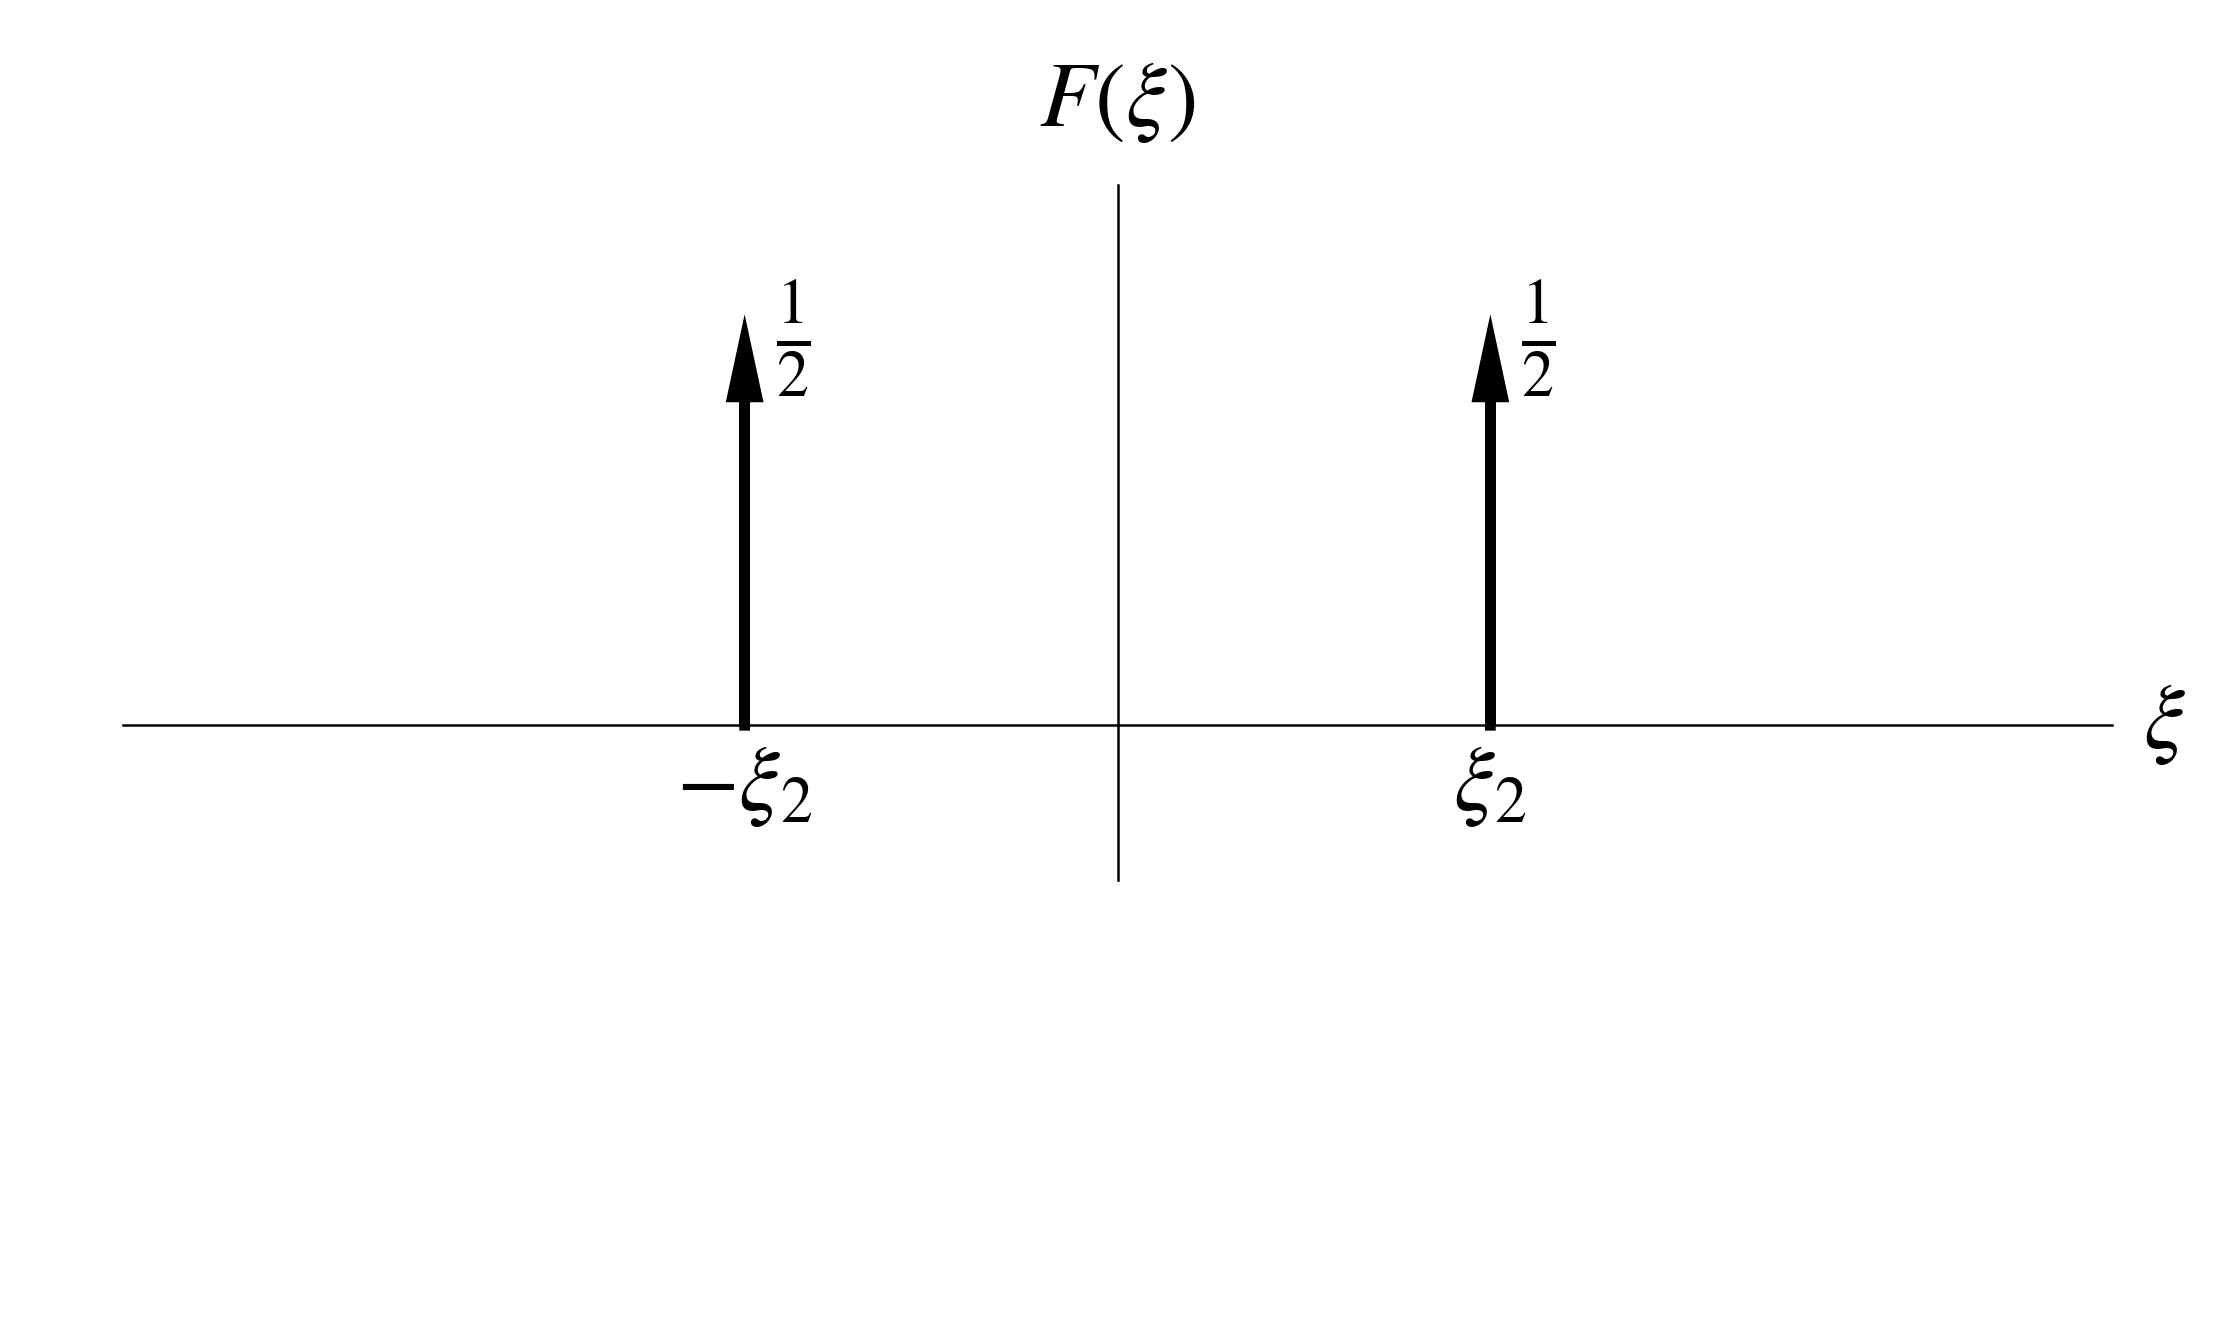

In [11]:
import matplotlib.pyplot as plt

# Force Matplotlib to use STIX for mathematical text rendering
plt.rcParams['mathtext.fontset'] = 'stix'
plt.rcParams['font.family'] = 'STIXGeneral'

def draw_fourier_spectrum(filename="fourier_spectrum_for_cosine_wave.png"):
    fig, ax = plt.subplots(figsize=(8, 5), dpi=300)

    # Set axis limits for proper padding and aspect ratio
    ax.set_xlim(-3.5, 3.5)
    ax.set_ylim(-1.5, 1.8)

    # Hide all default axes/spines to draw custom ones
    ax.axis('off')

    # ==========================================
    # 1. DRAW AXES
    # ==========================================
    # Horizontal axis (omega)
    ax.plot([-3.2, 3.2], [0, 0], color='black', lw=0.6)
    ax.text(3.3, 0, r'$\xi$', fontsize=22, ha='left', va='center')

    # Vertical axis (F(omega))
    # Stops slightly below the origin to match the reference image
    ax.plot([0, 0], [-0.4, 1.4], color='black', lw=0.6)
    ax.text(0, 1.5, r'$F(\xi)$', fontsize=22, ha='center', va='bottom')

    # ==========================================
    # 2. DRAW IMPULSES (ARROWS)
    # ==========================================
    # Left impulse pointing up
    ax.arrow(-1.2, 0, 0, 1, 
             head_width=0.08, head_length=0.15, 
             fc='black', ec='black', lw=2.5, 
             length_includes_head=True, zorder=3)
             
    # Right impulse pointing up
    ax.arrow(1.2, 0, 0, 1, 
             head_width=0.08, head_length=0.15, 
             fc='black', ec='black', lw=2.5, 
             length_includes_head=True, zorder=3)

    # ==========================================
    # 3. ADD LABELS WITH REQUESTED CHANGES
    # ==========================================
    # Left impulse labels
    ax.text(-1.1, 1.0, r'$\frac{1}{2}$', fontsize=22, ha='left', va='center')
    ax.text(-1.2, -0.05, r'$-\xi_2$', fontsize=22, ha='center', va='top')

    # Right impulse labels
    ax.text(1.3, 1.0, r'$\frac{1}{2}$', fontsize=22, ha='left', va='center')
    ax.text(1.2, -0.05, r'$\xi_2$', fontsize=22, ha='center', va='top')

    # Save and show
    plt.tight_layout()
    plt.savefig(figure_directory+filename, bbox_inches='tight', pad_inches=0.1)
    print(f"Success! Plot saved as {filename}")

# Execute the plot generation
draw_fourier_spectrum()

In [12]:
Magnitude of fourier transform of the composite waveform

SyntaxError: invalid syntax (2359047594.py, line 1)

Success! Plot saved as magnitude_of_fourier_spectrum_for_composite_waveform.png


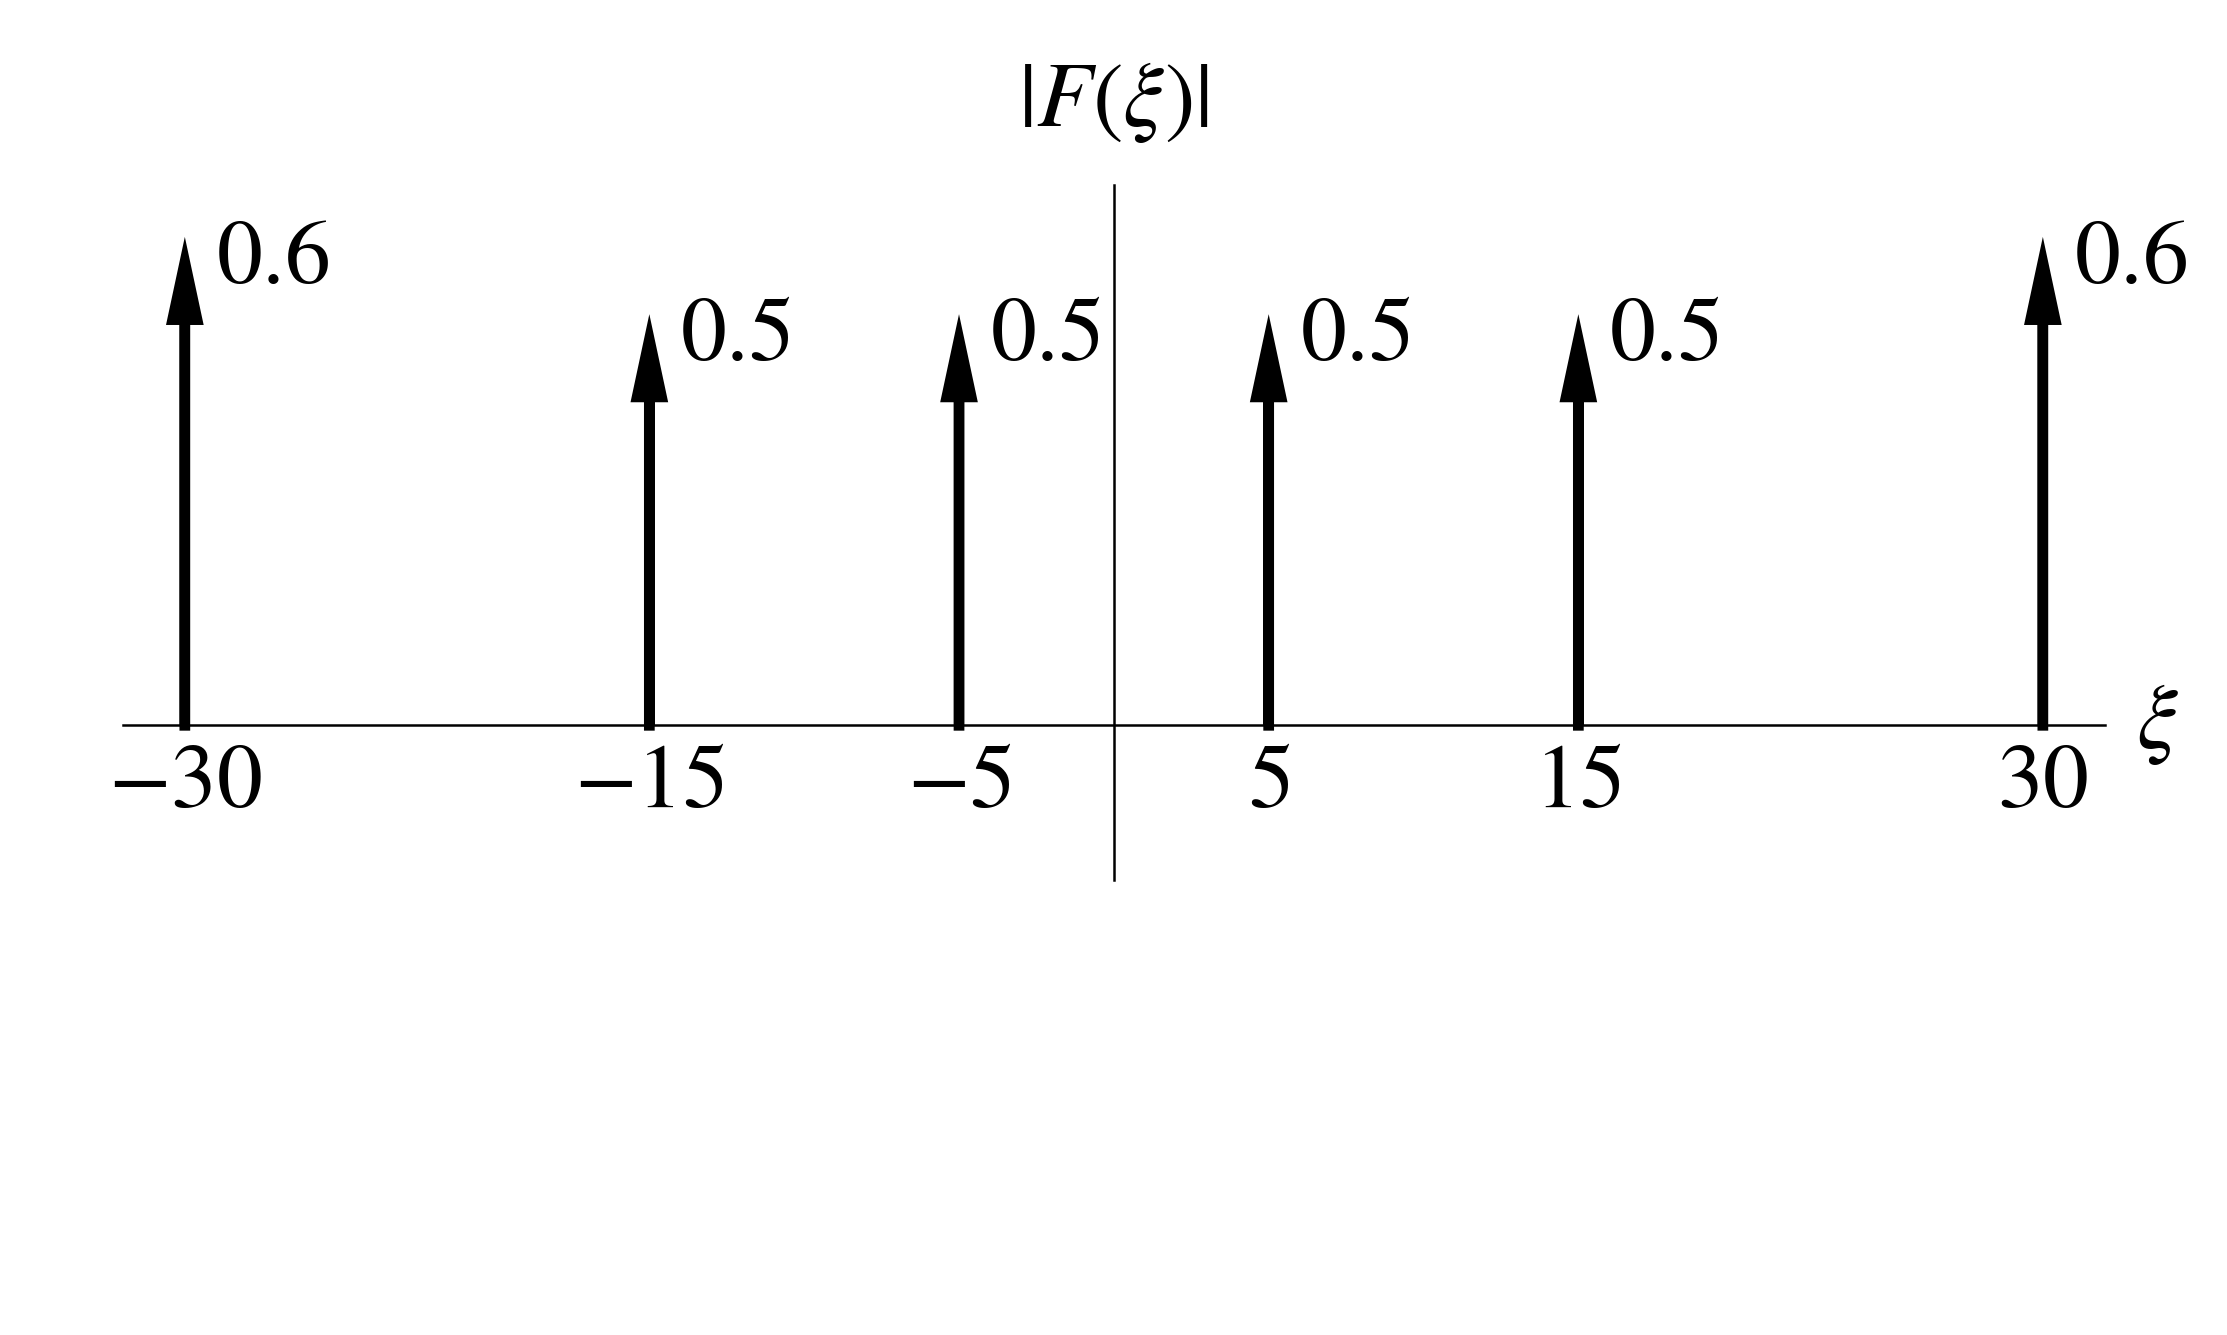

In [ ]:
import matplotlib.pyplot as plt

# Force Matplotlib to use STIX for mathematical text rendering
plt.rcParams['mathtext.fontset'] = 'stix'
plt.rcParams['font.family'] = 'STIXGeneral'

def draw_fourier_spectrum(filename="magnitude_of_fourier_spectrum_for_composite_waveform.png"):
    fig, ax = plt.subplots(figsize=(8, 5), dpi=300)

    # Set axis limits for proper padding and aspect ratio
    ax.set_xlim(-3.5, 3.5)
    ax.set_ylim(-1.5, 1.8)

    # Hide all default axes/spines to draw custom ones
    ax.axis('off')

    # ==========================================
    # 1. DRAW AXES
    # ==========================================
    # Horizontal axis (omega)
    ax.plot([-3.2, 3.2], [0, 0], color='black', lw=0.6)
    ax.text(3.3, 0, r'$\xi$', fontsize=22, ha='left', va='center')

    # Vertical axis (F(omega))
    # Stops slightly below the origin to match the reference image
    ax.plot([0, 0], [-0.4, 1.4], color='black', lw=0.6)
    ax.text(0, 1.5, r'$|F(\xi)|$', fontsize=22, ha='center', va='bottom')



    # ==========================================
    # 2. DRAW IMPULSES (ARROWS)
    # ==========================================
    # Left impulses pointing up
    ax.arrow(-0.5, 0, 0, 1, 
             head_width=0.08, head_length=0.15, 
             fc='black', ec='black', lw=2.5, 
             length_includes_head=True, zorder=3)
    ax.arrow(-1.5, 0, 0, 1.0, 
             head_width=0.08, head_length=0.15, 
             fc='black', ec='black', lw=2.5, 
             length_includes_head=True, zorder=3)
    ax.arrow(-3.0, 0, 0, 1.2, 
             head_width=0.08, head_length=0.15, 
             fc='black', ec='black', lw=2.5, 
             length_includes_head=True, zorder=3)

    # Right impulses pointing up
    ax.arrow(0.5, 0, 0, 1, 
             head_width=0.08, head_length=0.15, 
             fc='black', ec='black', lw=2.5, 
             length_includes_head=True, zorder=3)
    ax.arrow(1.5, 0, 0, 1.0, 
             head_width=0.08, head_length=0.15, 
             fc='black', ec='black', lw=2.5, 
             length_includes_head=True, zorder=3)
    ax.arrow(3.0, 0, 0, 1.2, 
             head_width=0.08, head_length=0.15, 
             fc='black', ec='black', lw=2.5, 
             length_includes_head=True, zorder=3)

    # ==========================================
    # 3. ADD LABELS WITH REQUESTED CHANGES
    # ==========================================
    # Left impulse labels
    ax.text(-0.4, 1.0, r'$0.5$', fontsize=22, ha='left', va='center')
    ax.text(-0.5, -0.05, r'$-5$', fontsize=22, ha='center', va='top')
    ax.text(-1.4, 1.0, r'$0.5$', fontsize=22, ha='left', va='center')
    ax.text(-1.5, -0.05, r'$-15$', fontsize=22, ha='center', va='top')
    ax.text(-2.9, 1.2, r'$0.6$', fontsize=22, ha='left', va='center')
    ax.text(-3.0, -0.05, r'$-30$', fontsize=22, ha='center', va='top')

    # Right impulse labels
    ax.text(0.6, 1.0, r'$0.5$', fontsize=22, ha='left', va='center')
    ax.text(0.5, -0.05, r'$5$', fontsize=22, ha='center', va='top')
    ax.text(1.6, 1.0, r'$0.5$', fontsize=22, ha='left', va='center')
    ax.text(1.5, -0.05, r'$15$', fontsize=22, ha='center', va='top')
    ax.text(3.1, 1.2, r'$0.6$', fontsize=22, ha='left', va='center')
    ax.text(3.0, -0.05, r'$30$', fontsize=22, ha='center', va='top')

    # Save and show
    plt.tight_layout()
    plt.savefig(figure_directory+filename, bbox_inches='tight', pad_inches=0.1)
    print(f"Success! Plot saved as {filename}")

# Execute the plot generation
draw_fourier_spectrum()

## Quantum Fourier Transform Circuit

In [13]:
import numpy as np
from qiskit import QuantumCircuit

def create_nc_qft_circuit(n):
    """
    Constructs the Quantum Fourier Transform circuit matching 
    Figure 5.1 from Nielsen and Chuang for n qubits.
    """
    qc = QuantumCircuit(n, name="QFT")
    
    # Apply Hadamard and controlled-phase rotations for each qubit
    for j in range(n):
        qc.h(j)
        for k in range(j + 1, n):
            # Angle corresponds to R_{k - j + 1} rotation: 2*pi / 2^(k - j + 1) = pi / 2^(k - j)
            angle = np.pi / (2 ** (k - j))
            qc.cp(angle, k, j)
            
    # Swap gates at the end to reverse qubit order (as specified in N&C Fig. 5.1 notes)
    for i in range(n // 2):
        qc.swap(i, n - i - 1)
        
    return qc

# Generate a 3-qubit QFT circuit matching N&C Figure 5.1
n_qubits = 3
qft_circuit = create_nc_qft_circuit(n_qubits)

# Draw the circuit in text format
print(qft_circuit.draw())

     ┌───┐                                        
q_0: ┤ H ├─■────────■───────────────────────────X─
     └───┘ │P(π/2)  │       ┌───┐               │ 
q_1: ──────■────────┼───────┤ H ├─■─────────────┼─
                    │P(π/4) └───┘ │P(π/2) ┌───┐ │ 
q_2: ───────────────■─────────────■───────┤ H ├─X─
                                          └───┘   


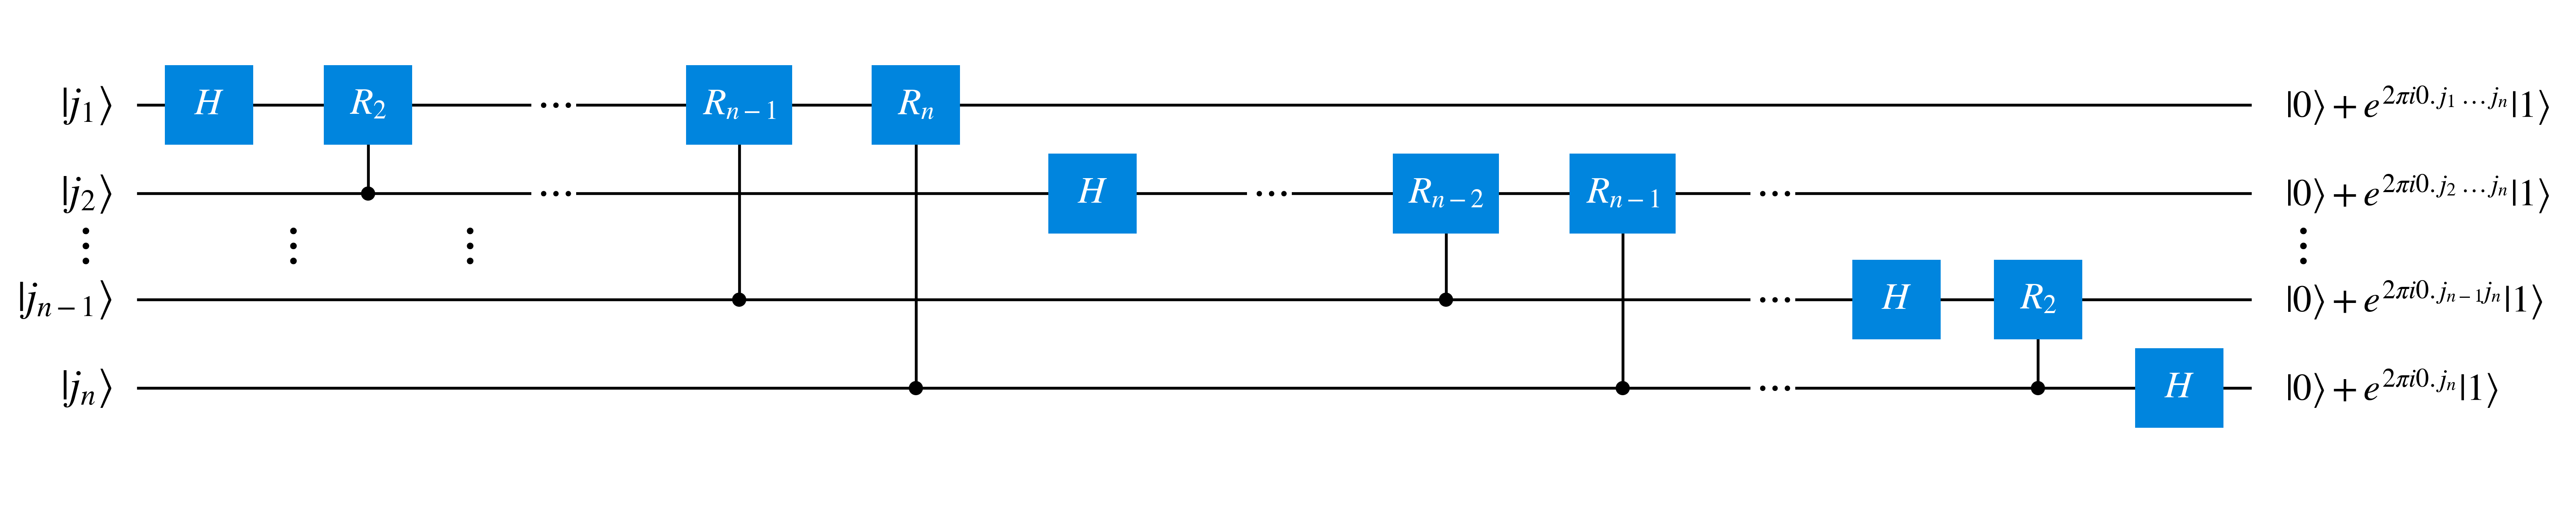

In [24]:

import matplotlib.pyplot as plt
import matplotlib.patches as patches

# Force Matplotlib to use STIX for mathematical text rendering
plt.rcParams['mathtext.fontset'] = 'stix'
plt.rcParams['font.family'] = 'STIXGeneral'

def draw_qft_circuit(filename="qft_circuit_without_swaps.png"):
    # Set up a compact, balanced figure and axis
    fig, ax = plt.subplots(figsize=(16, 6))
    
    x_wire_start = 0.8
    x_wire_end = 24.7

    ax.set_xlim(0.2, x_wire_end + 3.5)
    ax.set_ylim(-0.5, 5.0)
    ax.axis('off')
    ax.set_aspect('equal')

    BLUE = '#0085DE'
    BLACK = 'black'

    def draw_gate(x, y, text, w=1.0, h=0.9, color=BLUE):
        rect = patches.Rectangle((x - w/2, y - h/2), w, h, facecolor=color, zorder=3)
        ax.add_patch(rect)
        ax.text(x, y, text, color='white', fontsize=16, ha='center', va='center', zorder=4)

    def draw_control(x, y_ctrl, y_target):
        ax.plot([x, x], [y_ctrl, y_target], color=BLACK, lw=1.2, zorder=1)
        circle = patches.Circle((x, y_ctrl), 0.08, facecolor=BLACK, zorder=4)
        ax.add_patch(circle)

    y_coords = [4.0, 3.0, 1.8, 0.8]
    
    input_labels = [r'$|j_1\rangle$', r'$|j_2\rangle$', r'$|j_{n-1}\rangle$', r'$|j_n\rangle$']
    output_labels = [
        r'$|0\rangle + e^{2\pi i 0.j_1 \dots j_n}|1\rangle$',
        r'$|0\rangle + e^{2\pi i 0.j_2 \dots j_n}|1\rangle$',
        r'$|0\rangle + e^{2\pi i 0.j_{n-1} j_n}|1\rangle$',
        r'$|0\rangle + e^{2\pi i 0.j_n}|1\rangle$'
    ]

    for i, y in enumerate(y_coords):
        ax.plot([x_wire_start, x_wire_end], [y, y], color=BLACK, lw=1.2, zorder=1)
        ax.text(0.5, y, input_labels[i], fontsize=18, ha='right', va='center')
        ax.text(x_wire_end + 0.4, y, output_labels[i], fontsize=16, ha='left', va='center')

    # ==========================================
    # GATES & CONTROLS LAYOUT (Compacted & Enlarged)
    # ==========================================
    # Row 1 (y = 4.0)
    draw_gate(1.6, 4.0, r'$H$')
    draw_gate(3.4, 4.0, r'$R_2$')
    draw_control(3.4, 3.0, 4.0)

    ax.text(5.5, 4.0, r'$\cdots$', fontsize=18, ha='center', va='center', bbox=dict(facecolor='white', edgecolor='none', pad=2), zorder=2)
    ax.text(5.5, 3.0, r'$\cdots$', fontsize=18, ha='center', va='center', bbox=dict(facecolor='white', edgecolor='none', pad=2), zorder=2)

    draw_gate(7.6, 4.0, r'$R_{n-1}$', w=1.2)
    draw_control(7.6, 1.8, 4.0)

    draw_gate(9.6, 4.0, r'$R_n$', w=1.0)
    draw_control(9.6, 0.8, 4.0)

    # Row 2 (y = 3.0)
    draw_gate(11.6, 3.0, r'$H$')
    ax.text(13.6, 3.0, r'$\cdots$', fontsize=18, ha='center', va='center', bbox=dict(facecolor='white', edgecolor='none', pad=2), zorder=2)

    draw_gate(15.6, 3.0, r'$R_{n-2}$', w=1.2)
    draw_control(15.6, 1.8, 3.0)

    draw_gate(17.6, 3.0, r'$R_{n-1}$', w=1.2)
    draw_control(17.6, 0.8, 3.0)
    
    # Row 2 trailing ellipsis
    ax.text(19.3, 3.0, r'$\cdots$', fontsize=18, ha='center', va='center', bbox=dict(facecolor='white', edgecolor='none', pad=2), zorder=2)

    # Row 3 (y = 1.8)
    ax.text(19.3, 1.8, r'$\cdots$', fontsize=18, ha='center', va='center', bbox=dict(facecolor='white', edgecolor='none', pad=2), zorder=2)
    draw_gate(20.7, 1.8, r'$H$')
    draw_gate(22.3, 1.8, r'$R_2$')
    draw_control(22.3, 0.8, 1.8)

    # Row 4 (y = 0.8)
    ax.text(19.3, 0.8, r'$\cdots$', fontsize=18, ha='center', va='center', bbox=dict(facecolor='white', edgecolor='none', pad=2), zorder=2)
    draw_gate(23.9, 0.8, r'$H$')

    # ==========================================
    # VERTICAL ELLIPSES ($\vdots$)
    # ==========================================
    ax.text(0.15, 2.4, r'$\vdots$', fontsize=22, ha='center', va='center', bbox=dict(facecolor='white', edgecolor='none', pad=2), zorder=2)
    ax.text(25.25, 2.4, r'$\vdots$', fontsize=22, ha='center', va='center', bbox=dict(facecolor='white', edgecolor='none', pad=2), zorder=2)
    ax.text(4.5, 2.4, r'$\vdots$', fontsize=22, ha='center', va='center', bbox=dict(facecolor='white', edgecolor='none', pad=2), zorder=2)
    ax.text(2.5, 2.4, r'$\vdots$', fontsize=22, ha='center', va='center', bbox=dict(facecolor='white', edgecolor='none', pad=2), zorder=2)

    plt.tight_layout()
    plt.savefig(figure_directory+filename, bbox_inches='tight', pad_inches=0.2)
    plt.show()

if __name__ == '__main__':
    draw_qft_circuit()


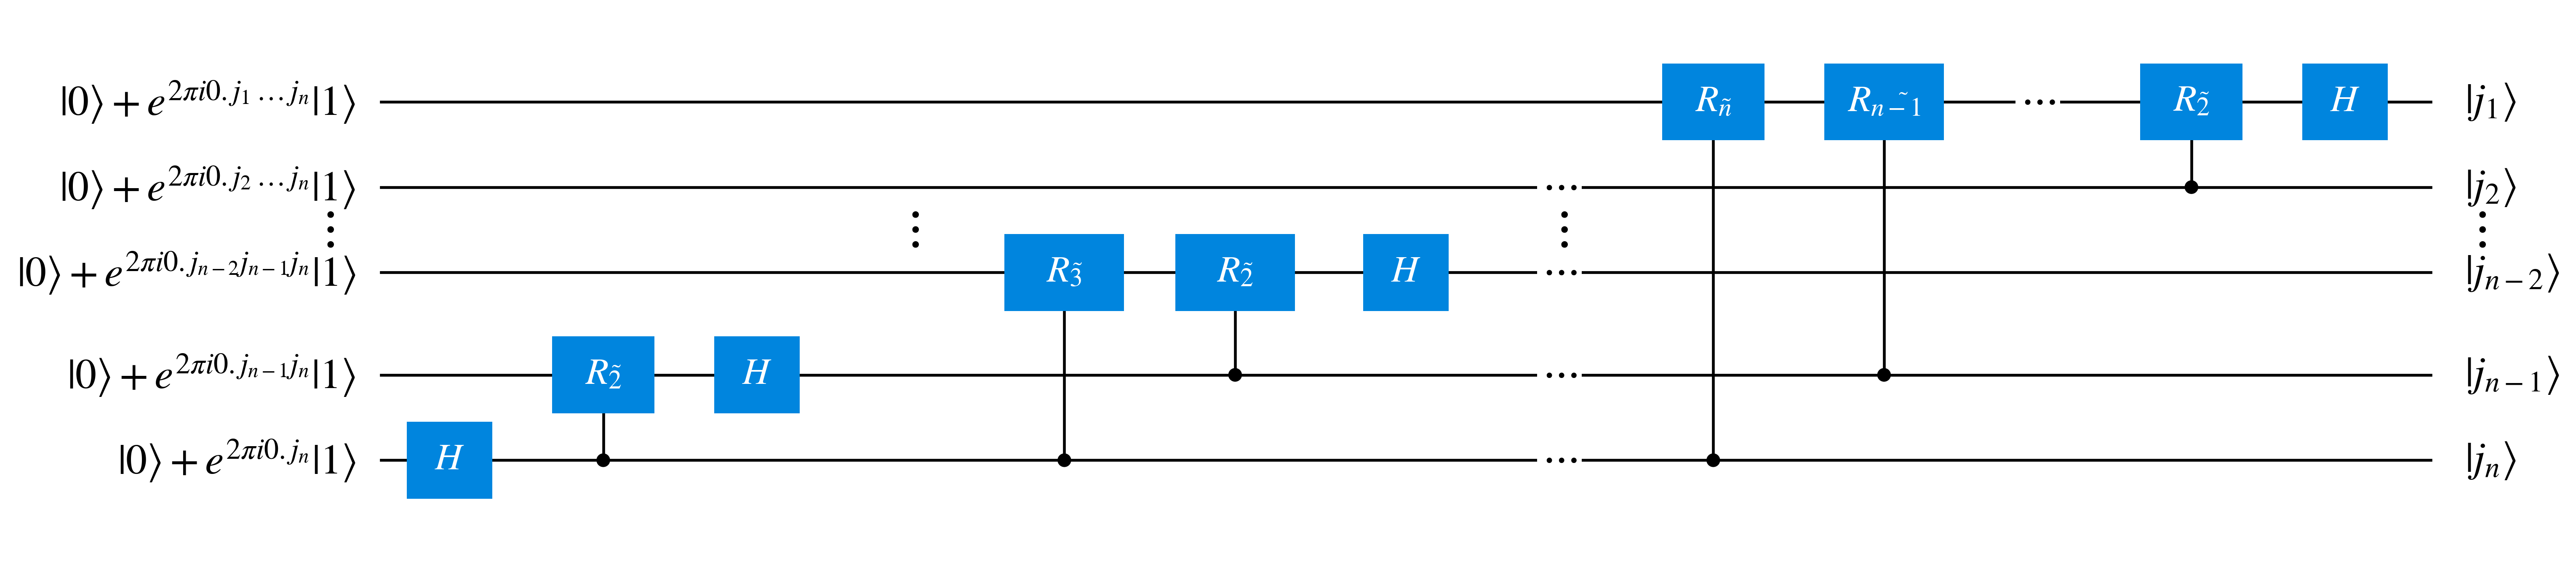

In [27]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# Force Matplotlib to use STIX for mathematical text rendering
plt.rcParams['mathtext.fontset'] = 'stix'
plt.rcParams['font.family'] = 'STIXGeneral'

def draw_inverse_qft_circuit(filename="inverse_qft_circuit_without_swaps.png"):
    # Set up a compact, balanced figure and axis
    fig, ax = plt.subplots(figsize=(16, 6))
    
    x_wire_start = 0.8
    x_wire_end = 24.8

    # Adjusted xlim left bound closer to reduce excess whitespace on the left
    ax.set_xlim(-1.2, x_wire_end + 1.5)
    ax.set_ylim(-0.5, 6.0)
    ax.axis('off')
    ax.set_aspect('equal')

    BLUE = '#0085DE'
    BLACK = 'black'

    def draw_gate(x, y, text, w=1.0, h=0.9, color=BLUE):
        rect = patches.Rectangle((x - w/2, y - h/2), w, h, facecolor=color, zorder=3)
        ax.add_patch(rect)
        ax.text(x, y, text, color='white', fontsize=16, ha='center', va='center', zorder=4)

    def draw_control(x, y_ctrl, y_target):
        ax.plot([x, x], [y_ctrl, y_target], color=BLACK, lw=1.2, zorder=1)
        circle = patches.Circle((x, y_ctrl), 0.08, facecolor=BLACK, zorder=4)
        ax.add_patch(circle)

    y_coords = [5.0, 4.0, 3.0, 1.8, 0.8]
    
    # Input labels are now the phase states (QFT outputs)
    input_labels = [
        r'$|0\rangle + e^{2\pi i 0.j_1 \dots j_n}|1\rangle$',
        r'$|0\rangle + e^{2\pi i 0.j_2 \dots j_n}|1\rangle$',
        r'$|0\rangle + e^{2\pi i 0.j_{n-2} j_{n-1} j_n}|1\rangle$',
        r'$|0\rangle + e^{2\pi i 0.j_{n-1} j_n}|1\rangle$',
        r'$|0\rangle + e^{2\pi i 0.j_n}|1\rangle$'
    ]
    
    # Output labels are the basis states
    output_labels = [r'$|j_1\rangle$', r'$|j_2\rangle$', r'$|j_{n-2}\rangle$', r'$|j_{n-1}\rangle$', r'$|j_n\rangle$']

    for i, y in enumerate(y_coords):
        ax.plot([x_wire_start, x_wire_end], [y, y], color=BLACK, lw=1.2, zorder=1)
        ax.text(0.5, y, input_labels[i], fontsize=18, ha='right', va='center')
        ax.text(x_wire_end + 0.4, y, output_labels[i], fontsize=18, ha='left', va='center')

    # ==========================================
    # GATES & CONTROLS LAYOUT (Inverse QFT)
    # Applied in reverse order, starting from the nth qubit
    # ==========================================
    
    # --- Step 1: nth and (n-1)th qubits ---
    # Row n (y = 0.8)
    draw_gate(1.6, 0.8, r'$H$')
    draw_control(3.4, 0.8, 1.8)
    
    # Row n-1 (y = 1.8)
    draw_gate(3.4, 1.8, r'$R_{\tilde{2}}$', w=1.2)
    draw_gate(5.2, 1.8, r'$H$')

    ax.text(7.0, 3.5, r'$\vdots$', fontsize=22, ha='center', va='center', bbox=dict(facecolor='white', edgecolor='none', pad=2), zorder=2)

    ax.text(0.15, 3.5, r'$\vdots$', fontsize=22, ha='center', va='center', bbox=dict(facecolor='white', edgecolor='none', pad=2), zorder=2)
    ax.text(25.35, 3.5, r'$\vdots$', fontsize=22, ha='center', va='center', bbox=dict(facecolor='white', edgecolor='none', pad=2), zorder=2)

    # --- Step 2: 2nd qubit ---
    # Controls from n and n-1 targeting 2
    draw_control(8.8, 0.8, 3.0)
    draw_control(10.8, 1.8, 3.0)
    
    # Row 2 (y = 3.0)
    draw_gate(8.8, 3.0, r'$R_{\tilde{3}}$', w=1.4)
    draw_gate(10.8, 3.0, r'$R_{\tilde{2}}$', w=1.4)
    draw_gate(12.8, 3.0, r'$H$')

    # Second layout break (Ellipses)
    ax.text(14.6, 0.8, r'$\cdots$', fontsize=18, ha='center', va='center', bbox=dict(facecolor='white', edgecolor='none', pad=2), zorder=2)
    ax.text(14.6, 1.8, r'$\cdots$', fontsize=18, ha='center', va='center', bbox=dict(facecolor='white', edgecolor='none', pad=2), zorder=2)
    ax.text(14.6, 3.0, r'$\cdots$', fontsize=18, ha='center', va='center', bbox=dict(facecolor='white', edgecolor='none', pad=2), zorder=2)
    ax.text(14.6, 4.0, r'$\cdots$', fontsize=18, ha='center', va='center', bbox=dict(facecolor='white', edgecolor='none', pad=2), zorder=2)
    ax.text(14.6, 3.5, r'$\vdots$', fontsize=22, ha='center', va='center', bbox=dict(facecolor='white', edgecolor='none', pad=2), zorder=2)

    # --- Step 3: 1st qubit ---
    # Controls from n, n-1, and 2 targeting 1
    draw_control(16.4, 0.8, 5.0)
    draw_control(18.4, 1.8, 5.0)
    
    # Row 1 intermediate ellipsis (skipping n-2 down to 3)
    ax.text(20.2, 5.0, r'$\cdots$', fontsize=18, ha='center', va='center', bbox=dict(facecolor='white', edgecolor='none', pad=2), zorder=2)
    
    draw_control(22.0, 4.0, 5.0)

    # Row 1 (y = 4.0)
    draw_gate(16.4, 5.0, r'$R_{\tilde{n}}$', w=1.2)
    draw_gate(18.4, 5.0, r'$R_{\tilde{n-1}}$', w=1.4)
    draw_gate(22.0, 5.0, r'$R_{\tilde{2}}$', w=1.2)
    draw_gate(23.8, 5.0, r'$H$')

    plt.tight_layout()
    plt.savefig(figure_directory+filename, bbox_inches='tight', pad_inches=0.1)
    plt.show()

if __name__ == '__main__':
    draw_inverse_qft_circuit()

In [32]:
from qiskit.visualization import plot_histogram, plot_bloch_multivector
from qiskit import QuantumCircuit 
from qiskit.circuit.library import QFTGate

# Import a local fake backend instead of using QiskitRuntimeService
from qiskit_ibm_runtime.fake_provider import FakeManilaV2
from qiskit.primitives import BackendSamplerV2


# Load the Aer simulator and generate a noise model locally
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel

# Instantiate the fake backend (no cloud connection required)
backend = FakeManilaV2()

# Generate the noise model based on the local fake backend
noise_model = NoiseModel.from_backend(backend)

# Define a simulator using Aer, and use it in Sampler.
backend_sim = AerSimulator(noise_model=noise_model)
sampler_sim = BackendSamplerV2(backend=backend_sim)

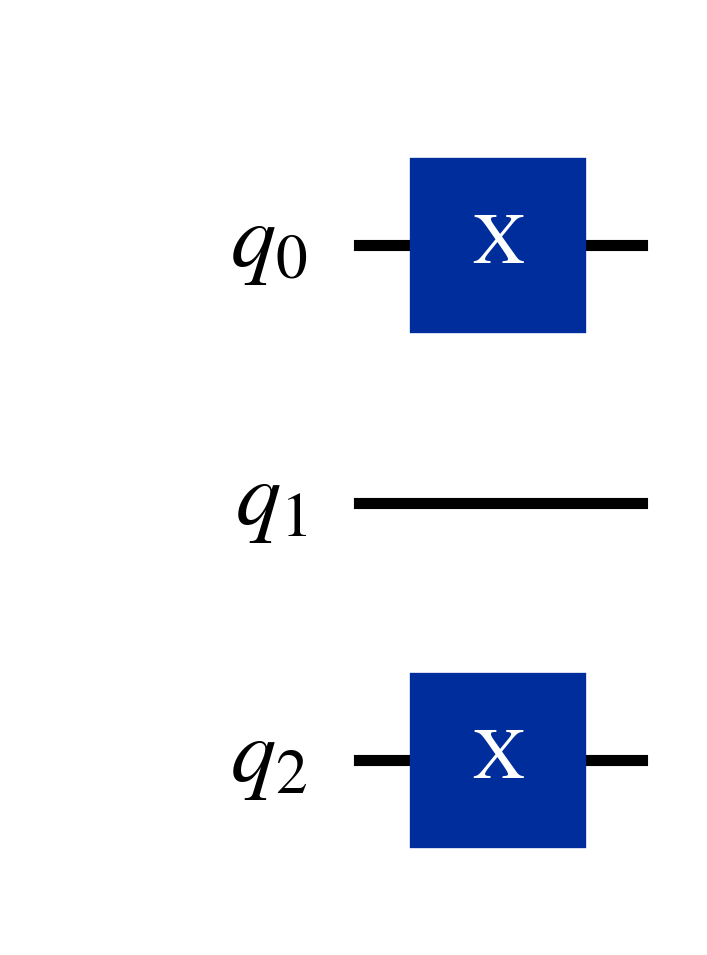

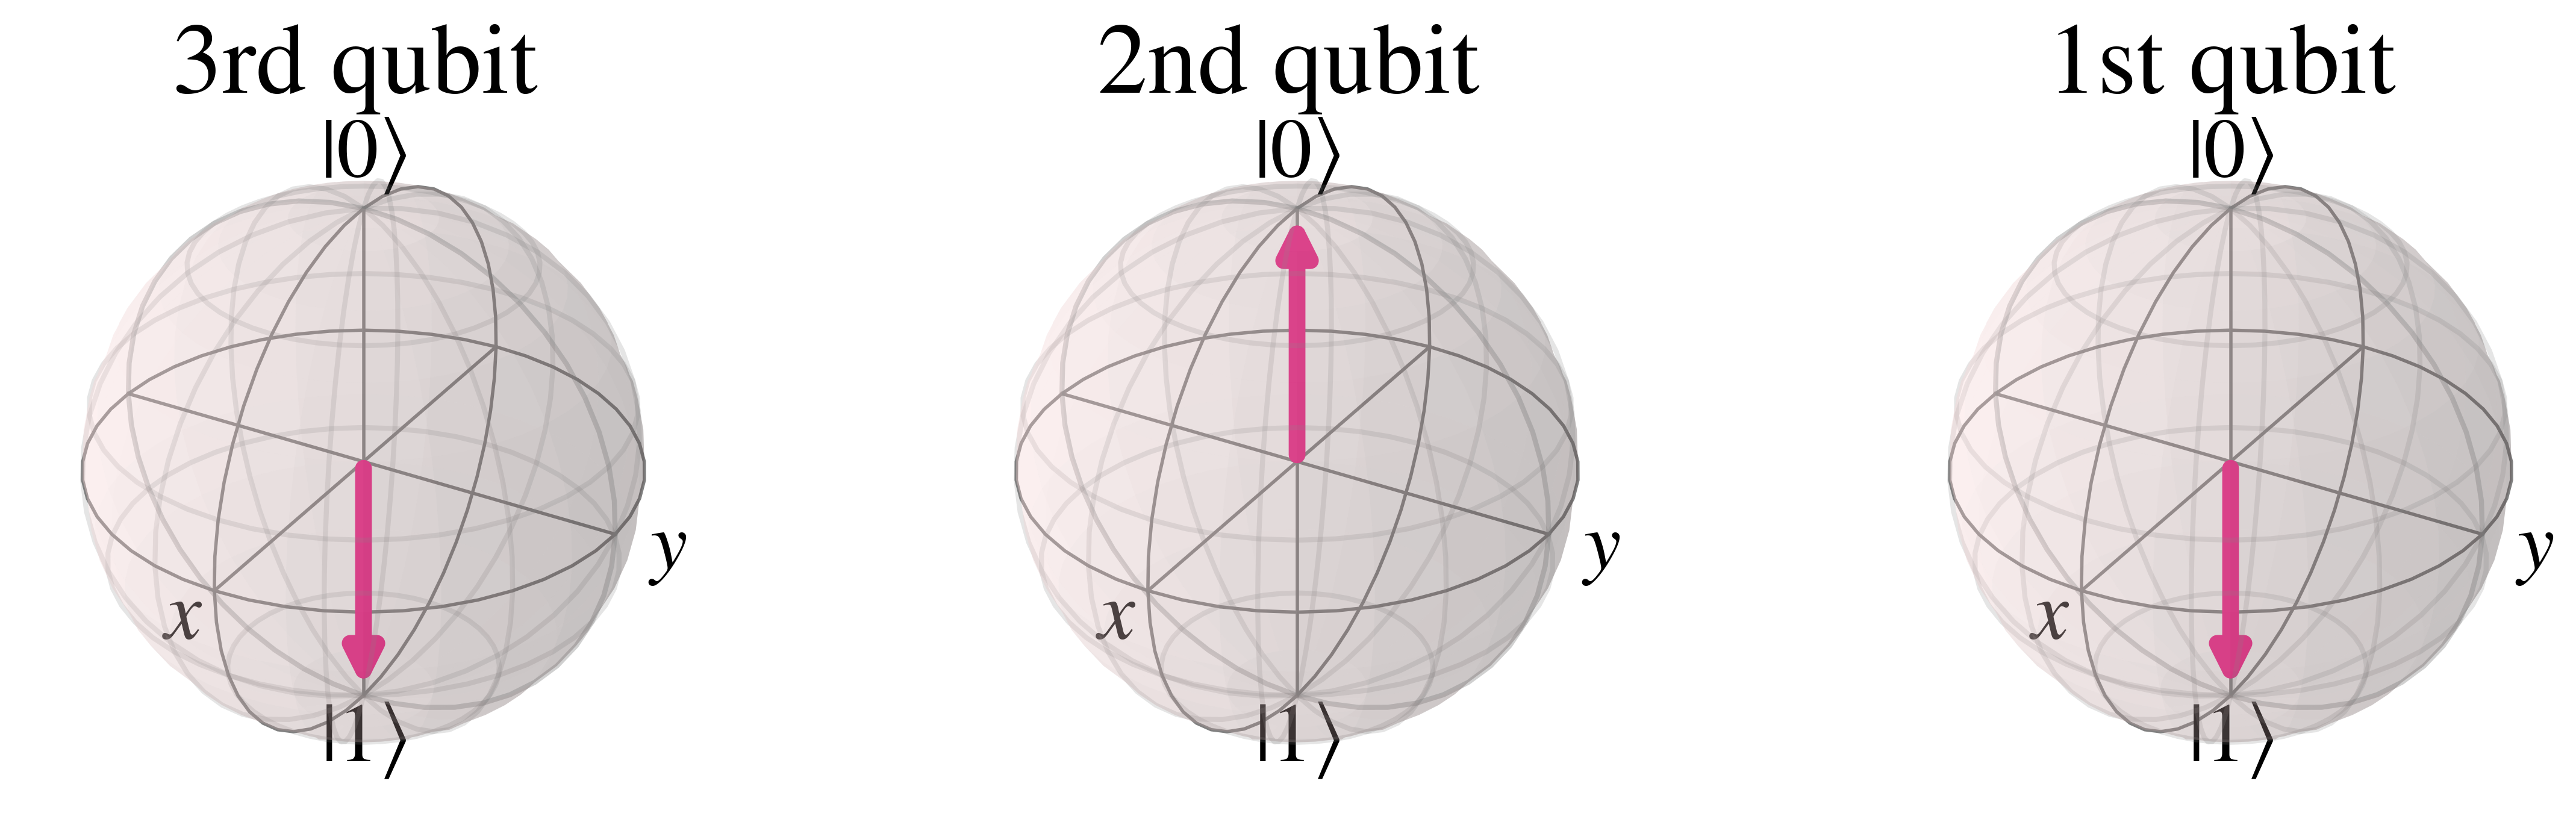

In [64]:
# Create the circuit
qc = QuantumCircuit(3)

# Encode the state 5
qc.x(0)
qc.x(2)
fig=qc.draw("mpl")
fig.show()

qc_init = qc.copy()
qc_init.save_statevector()
statevector = backend_sim.run(qc_init).result().get_statevector()
fig = plot_bloch_multivector(statevector, title_pad=2)

# Access axes or modify titles/labels via matplotlib
# Note: plot_bloch_multivector creates subplots for each qubit
axes = fig.axes
label_numbers = ['3rd', '2nd', '1st']
for i, ax in enumerate(axes):
    # Example: change or set a custom title/label for each subplot
    ax.set_title(label_numbers[i] + ' qubit', pad=30)

#plt.show()
plt.savefig(figure_directory+'blochvectors_of_101.png', bbox_inches='tight', pad_inches=0.1)
#fig.show()


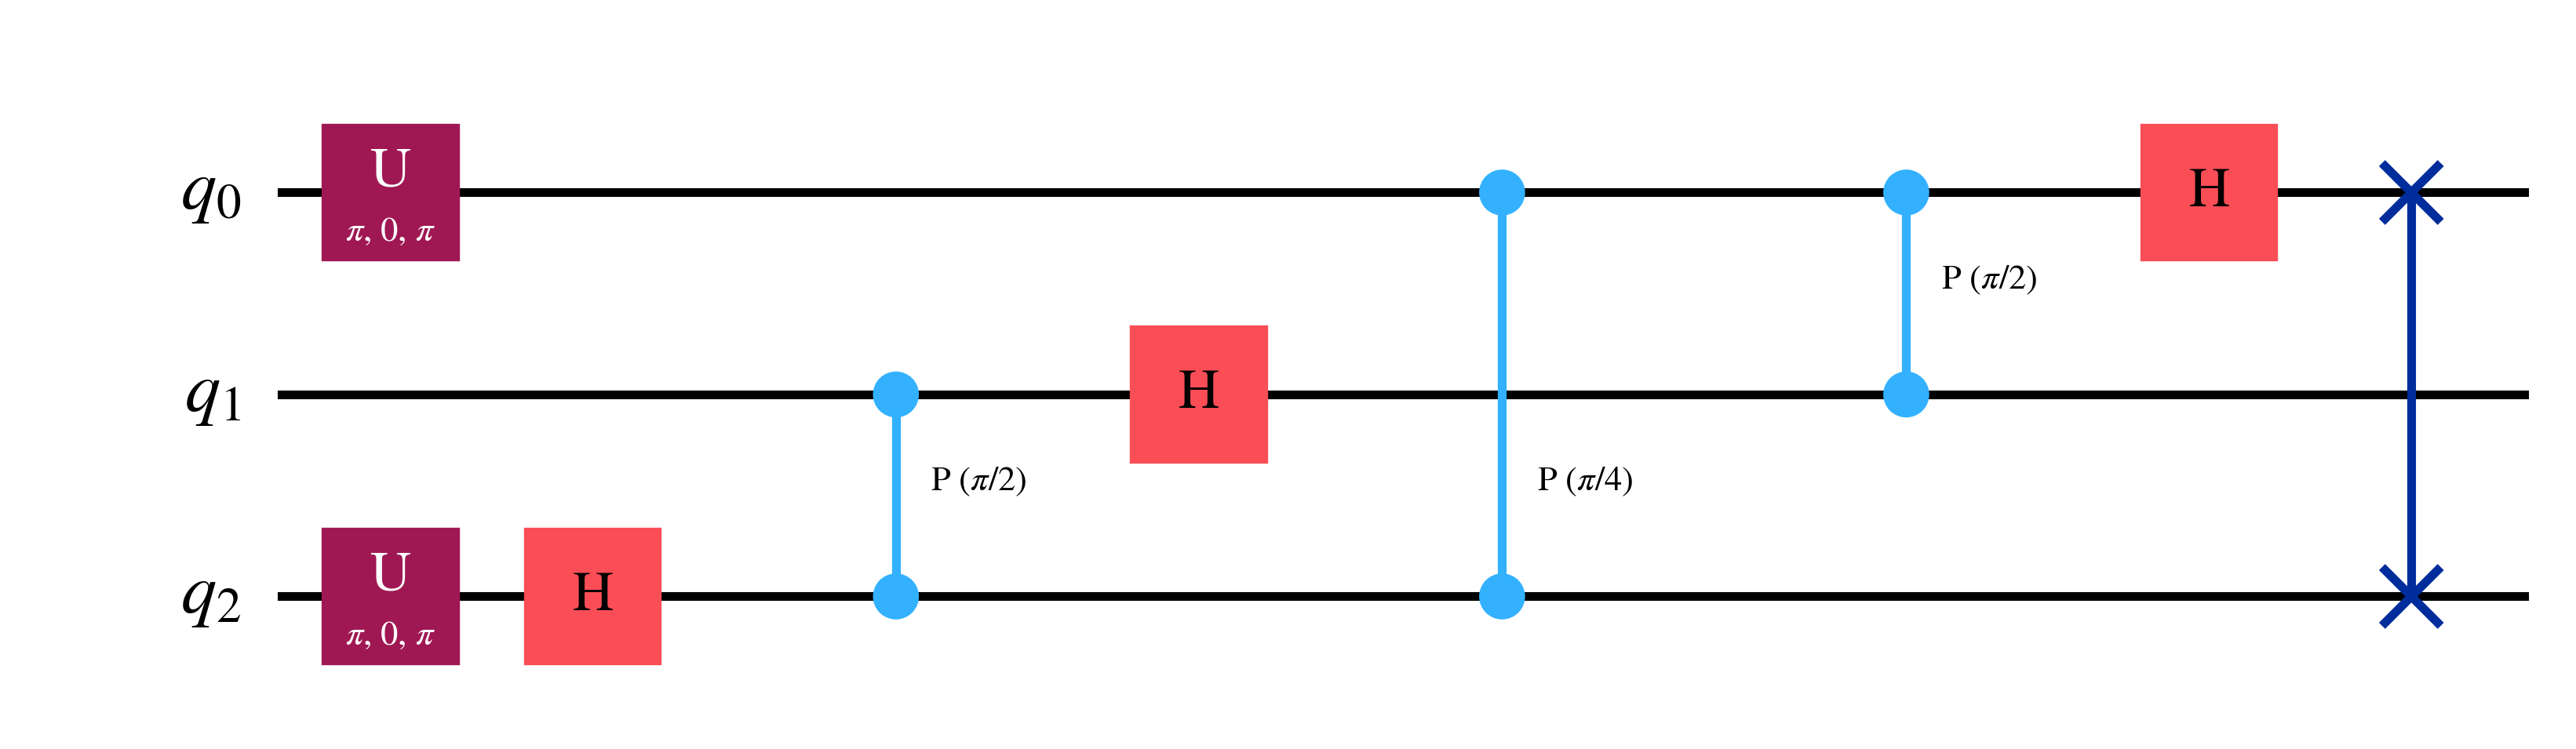

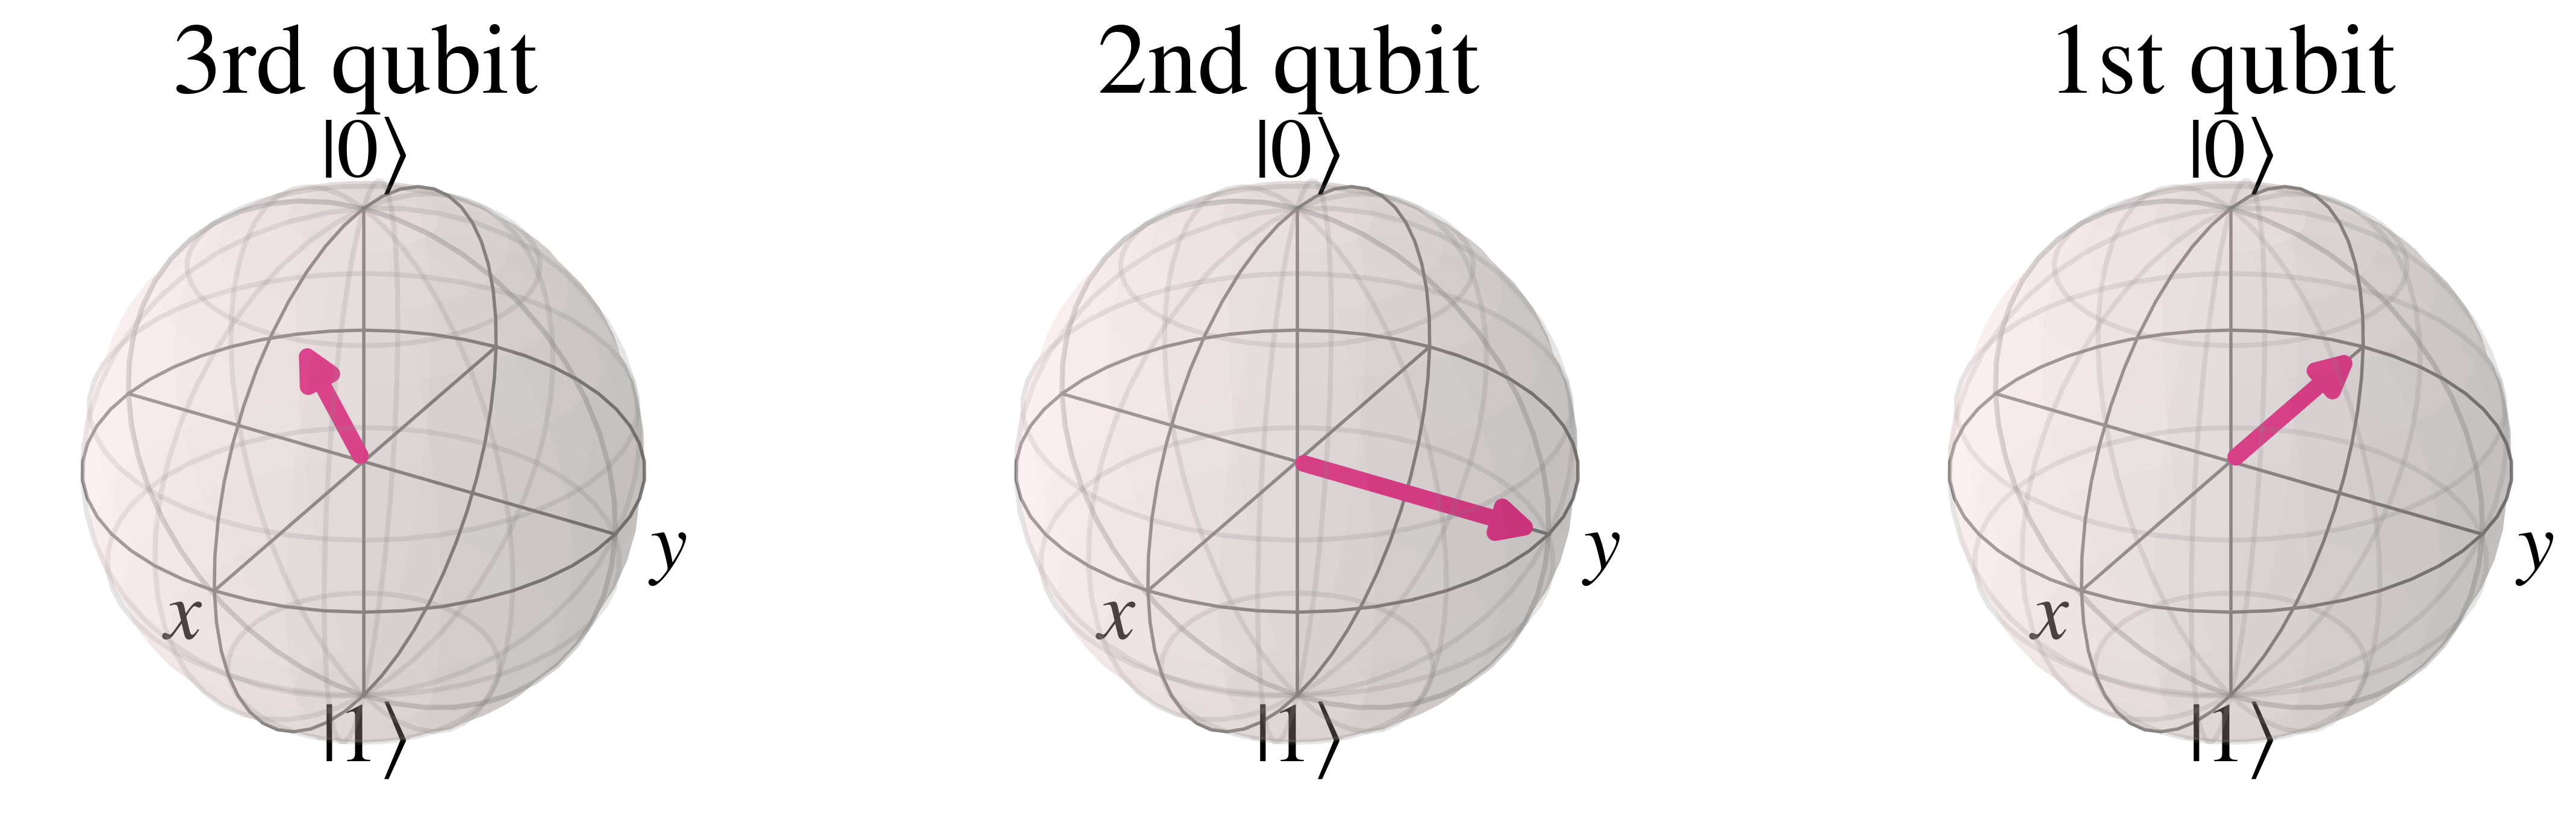

In [67]:
# Step 1: Create circuit
qc_qft = QuantumCircuit(3)
qc_qft.x(0)
qc_qft.x(2)
qc_qft.compose(QFTGate(3), inplace=True)
qc_qft = qc_qft.decompose()
#qc_qft.measure_all()
fig=qc_qft.draw("mpl")
fig.show()

qc_qft.save_statevector()
statevector = backend_sim.run(qc_qft).result().get_statevector()
fig = plot_bloch_multivector(statevector)

# Access axes or modify titles/labels via matplotlib
# Note: plot_bloch_multivector creates subplots for each qubit
axes = fig.axes
label_numbers = ['3rd', '2nd', '1st']
for i, ax in enumerate(axes):
    # Example: change or set a custom title/label for each subplot
    ax.set_title(label_numbers[i] + ' qubit', pad=30)

#plt.show()
plt.savefig(figure_directory+'blochvectors_of_QFT_transform_of_101.png', bbox_inches='tight', pad_inches=0.1)
#fig.show()

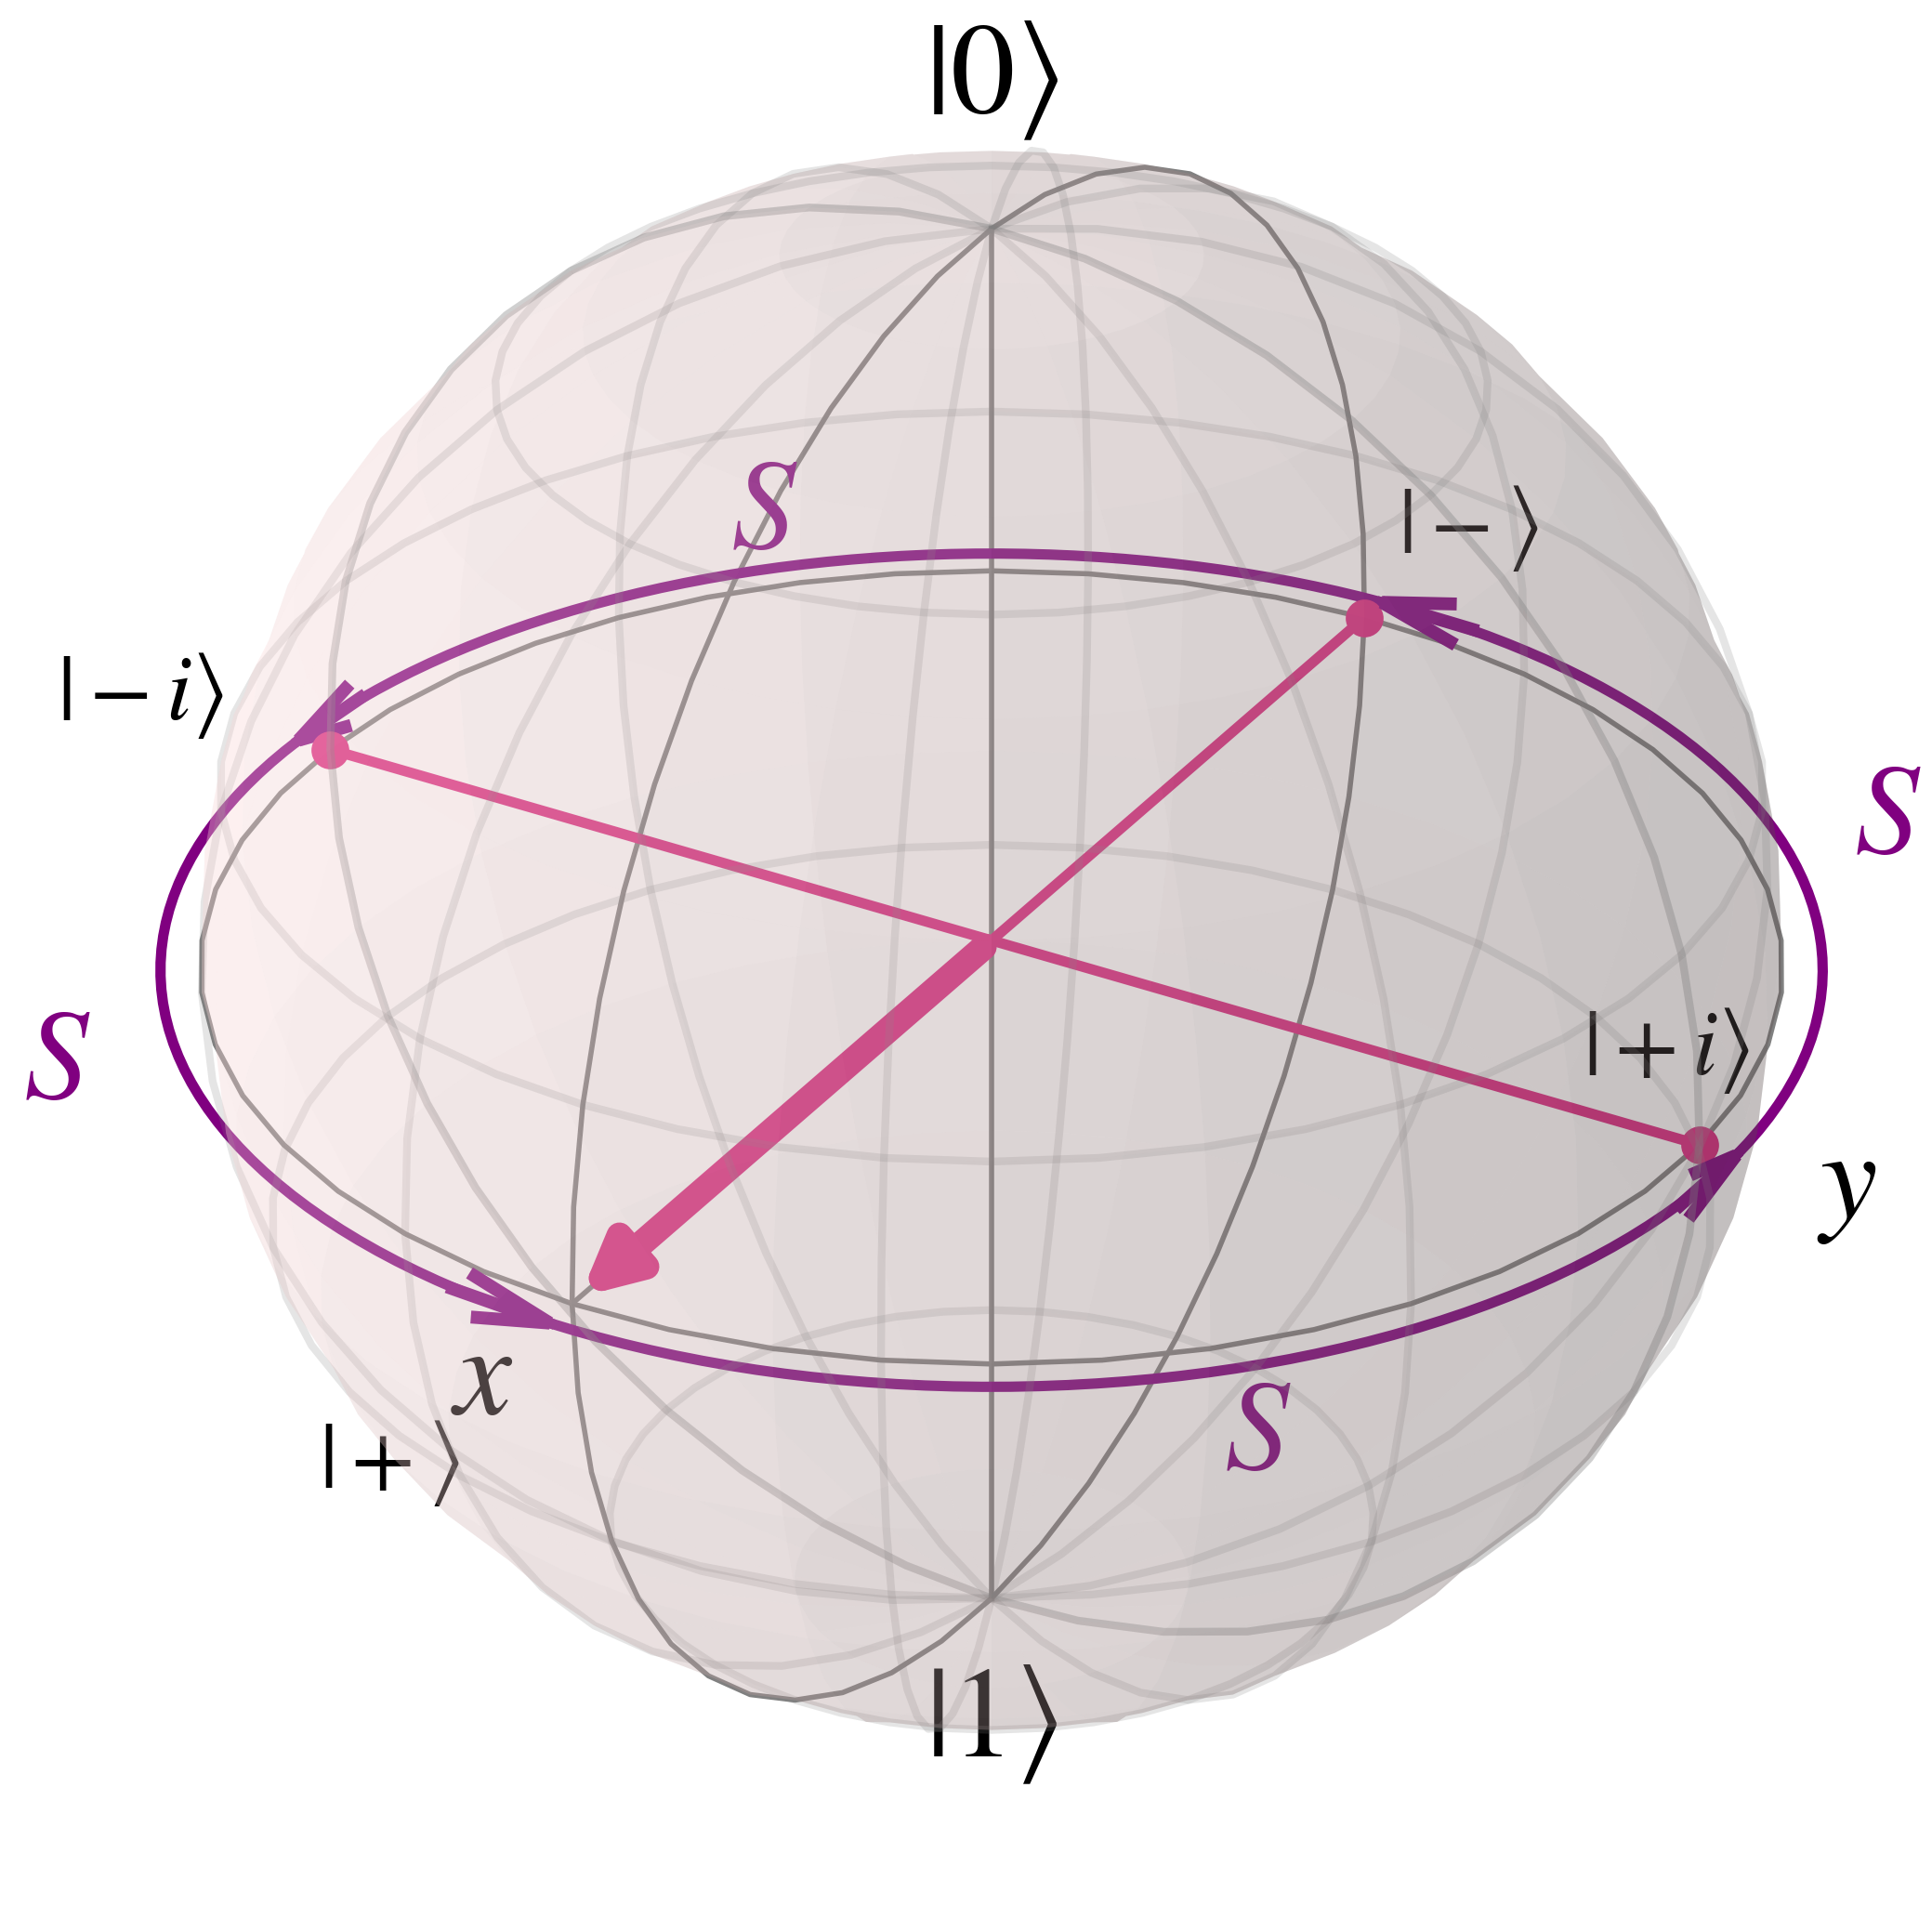

In [57]:
# Note: the following figure made use of AI assistance.

import numpy as np
import matplotlib.pyplot as plt
from qiskit.visualization import plot_bloch_vector
import warnings

warnings.filterwarnings("ignore", category=UserWarning)

# 1. Start with a sphere showing the initial |+> state
fig_s_gate = plot_bloch_vector([1, np.pi/2, 0], coord_type='spherical')
ax = fig_s_gate.axes[0]

def q_to_m(qx, qy, qz):
    """Maps Quantum [x,y,z] to Matplotlib [y, -x, z] to match Qiskit's backend"""
    return qy, -qx, qz

# 2. Draw the other three states on the equator
vector_color = '#dc267f'

states = {
    r'$|+i\rangle$': (0, 1, 0),
    r'$|-\rangle$': (-1, 0, 0),
    r'$|-i\rangle$': (0, -1, 0)
}

for label, (qx, qy, qz) in states.items():
    mx, my, mz = q_to_m(qx, qy, qz)
    ax.plot([0, mx], [0, my], [0, mz], color=vector_color, linewidth=2)
    ax.scatter([mx], [my], [mz], color=vector_color, s=40)

# 3. Add text labels for all four states
labels = {
    r'$|+\rangle$': (1.4, 0, 0),
    r'$|+i\rangle$': (0, 0.95, 0.12),
    r'$|-\rangle$': (-1.3, 0, 0),
    r'$|-i\rangle$': (0, -1.3, 0)
}

font_style = {'fontsize': 18, 'verticalalignment': 'center', 'horizontalalignment': 'center'}
for text, (qx, qy, qz) in labels.items():
    mx, my, mz = q_to_m(qx, qy, qz)
    ax.text(mx, my, mz, text, **font_style)

# =========================================================================
# --- MODIFIED: Fixed the 3D Quiver Arrowhead Arguments ---
# =========================================================================
ring_color = 'purple'
radius = 1.05

def draw_equatorial_arc_with_arrow(start_phi, end_phi):
    # 1. Draw solid arc segment
    phi_angles = np.linspace(start_phi, end_phi, 50)
    q_arc_x = radius * np.cos(phi_angles)
    q_arc_y = radius * np.sin(phi_angles)
    q_arc_z = np.zeros(50)
    m_arc_x, m_arc_y, m_arc_z = q_to_m(q_arc_x, q_arc_y, q_arc_z)
    
    ax.plot(m_arc_x, m_arc_y, m_arc_z, color=ring_color, linewidth=2)

    # 2. Draw arrowhead at the end point using the correct 3D arguments
    qx_head = radius * np.cos(end_phi)
    qy_head = radius * np.sin(end_phi)
    mx_head, my_head, mz_head = q_to_m(qx_head, qy_head, 0)
    
    phi_prev = end_phi - 0.1
    qx_prev = radius * np.cos(phi_prev)
    qy_prev = radius * np.sin(phi_prev)
    mx_prev, my_prev, mz_prev = q_to_m(qx_prev, qy_prev, 0)
    
    v_dir = (mx_head - mx_prev, my_head - my_prev, mz_head - mz_prev)
    v_dir_norm = v_dir / np.linalg.norm(v_dir)
    
    # FIXED: Replaced headlength/headwidth with arrow_length_ratio and added pivot='tip'
    ax.quiver(mx_head, my_head, mz_head, v_dir_norm[0], v_dir_norm[1], v_dir_norm[2], 
              color=ring_color, length=0.15, normalize=False, 
              arrow_length_ratio=0.8, pivot='tip', linewidth=2.5)

# Quadrant 1: |+> to |+i>
draw_equatorial_arc_with_arrow(0, np.pi/2)
# Quadrant 2: |+i> to |->
draw_equatorial_arc_with_arrow(np.pi/2, np.pi)
# Quadrant 3: |-> to |-i>
draw_equatorial_arc_with_arrow(np.pi, 1.5*np.pi)
# Quadrant 4: |-i> to |+>
draw_equatorial_arc_with_arrow(1.5*np.pi, 2*np.pi)
# =========================================================================

# 5. Add "S" labels
s_label_angles = [np.pi/4, 3*np.pi/4, 5*np.pi/4, 7*np.pi/4]
for angle in s_label_angles:
    qx = 1.2 * np.cos(angle)
    qy = 1.2 * np.sin(angle)
    mx, my, mz = q_to_m(qx, qy, 0)
    ax.text(mx, my, mz, r'$S$', color=ring_color, fontsize=25, fontweight='bold',
            ha='center', va='center')

plt.savefig(figure_directory+'s_gate_rotations.png', bbox_inches='tight', pad_inches=0.1)
plt.show()

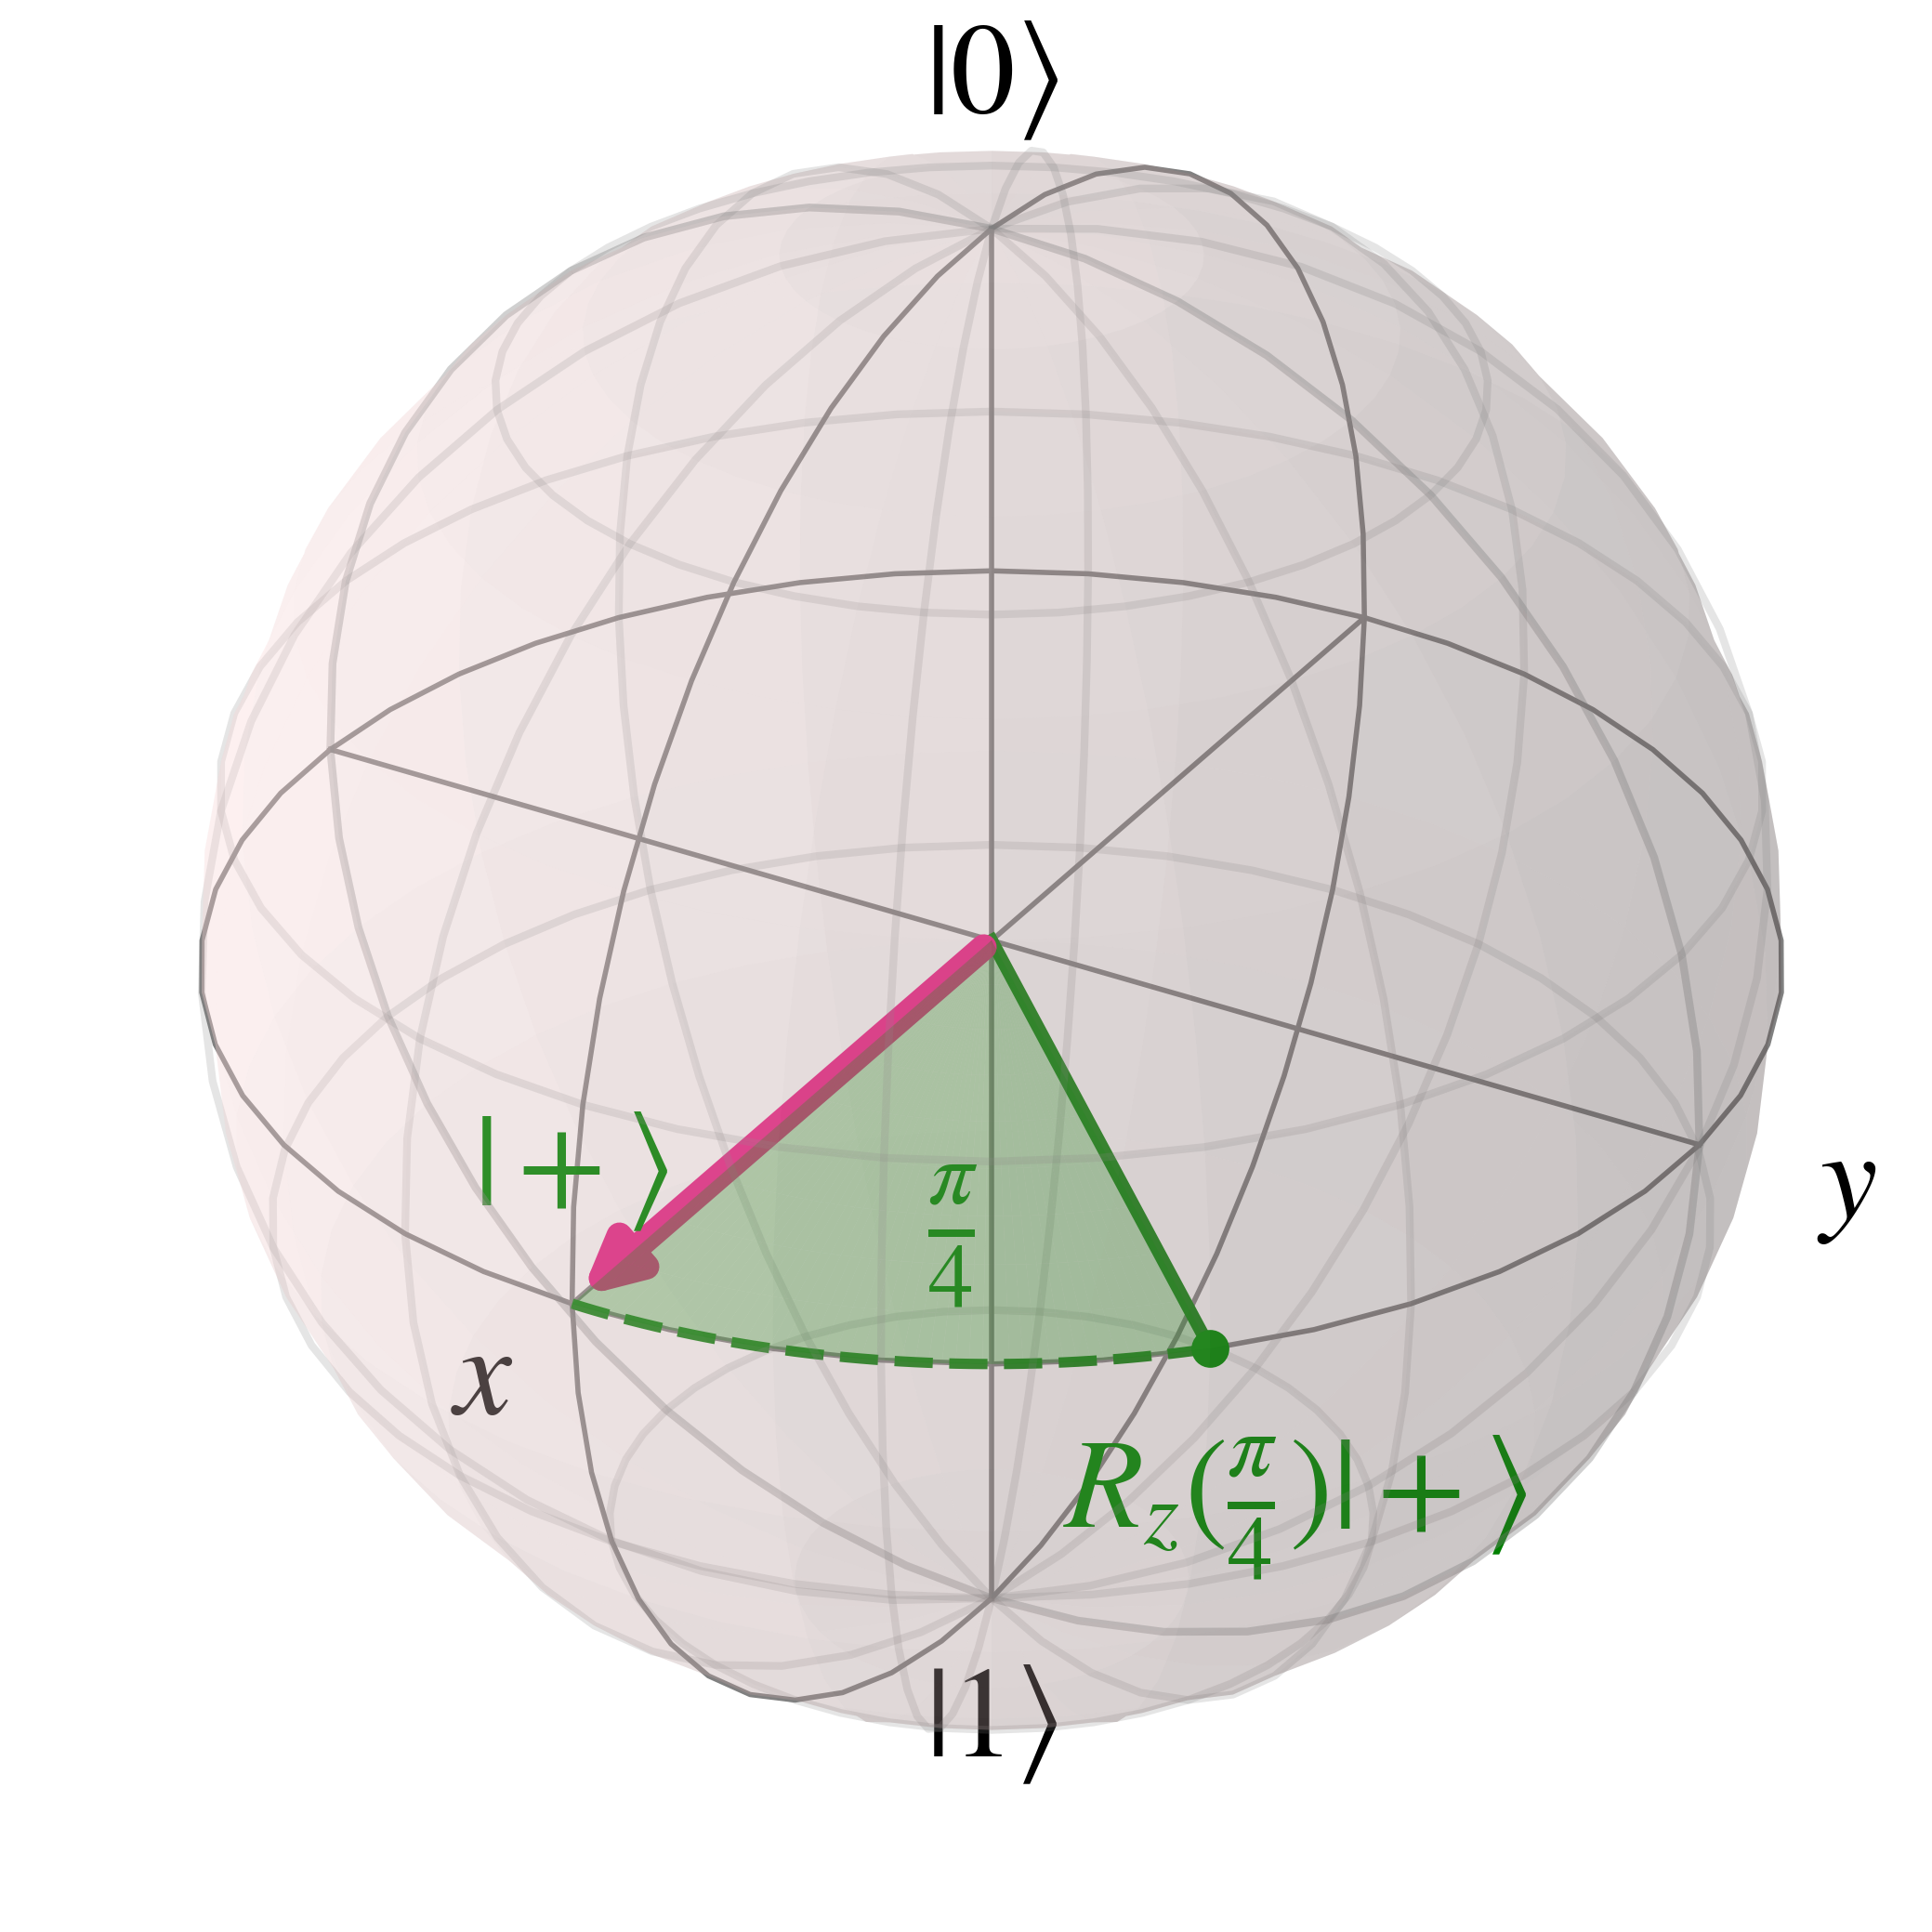

In [63]:
# Note: the following figure made use of AI assistance.

import numpy as np
import matplotlib.pyplot as plt
from qiskit.visualization import plot_bloch_vector
import warnings

warnings.filterwarnings("ignore", category=UserWarning)

def q_to_m(qx, qy, qz):
    """Maps Quantum [x,y,z] to Matplotlib [y, -x, z] to match Qiskit's backend"""
    return qy, -qx, qz

# Rotation angle
gamma = np.pi / 4 

# Vector drawing helper function
def draw_vector(ax, qx, qy, qz, color, label='', label_offset=(0,0,0)):
    mx, my, mz = q_to_m(qx, qy, qz)
    ax.plot([0, mx], [0, my], [0, mz], color=color, linewidth=2.5)
    ax.scatter([mx], [my], [mz], color=color, s=40)
    if label:
        lx, ly, lz = q_to_m(qx + label_offset[0], qy + label_offset[1], qz + label_offset[2])
        ax.text(lx, ly, lz, label, color=color, fontsize=25, ha='center', va='center')

# # ==========================================
# # --- FIGURE 1: Rx(pi/4) on |0> ------------
# # ==========================================
# # Pass [0,0,1] so Qiskit natively draws the initial |0> state
# fig_rx = plot_bloch_vector([0, 0, 1])#, title=r'$R_x(\pi/4)$ applied to $|0\rangle$')
# ax_rx = fig_rx.axes[0]

# # Label the initial |0> state (Qiskit draws it in pink: #dc267f)
# # lx, ly, lz = q_to_m(0, 0, 1.15)
# #ax_rx.text(lx, ly, lz, r'$|0\rangle$', color='#dc267f', fontsize=14, ha='center', va='center')

# # Final State Rx|0> (Red)
# # Rotation around X drops the vector towards the -Y axis
# rx_qx, rx_qy, rx_qz = 0, -np.sin(gamma), np.cos(gamma)
# draw_vector(ax_rx, rx_qx, rx_qy, rx_qz, 'red', r'$R_x(\frac{\pi}{4})|0\rangle$', label_offset=(0, -0.35, 0))

# # The Shaded Arc (Red)
# angles = np.linspace(0, gamma, 50)
# m_arc_x, m_arc_y, m_arc_z = q_to_m(np.zeros(50), -np.sin(angles), np.cos(angles))
# ax_rx.plot(m_arc_x, m_arc_y, m_arc_z, color='red', linestyle='dashed', linewidth=2)

# r_val = np.linspace(0, 1, 10)
# T, R = np.meshgrid(angles, r_val)
# m_surf_x, m_surf_y, m_surf_z = q_to_m(np.zeros_like(T), -R * np.sin(T), R * np.cos(T))
# ax_rx.plot_surface(m_surf_x, m_surf_y, m_surf_z, color='red', alpha=0.3, shade=False)

# # Annotation
# t_x, t_y, t_z = q_to_m(0, -0.6 * np.sin(gamma/2), 0.6 * np.cos(gamma/2))
# ax_rx.text(t_x, t_y - 0.1, t_z, r'$\frac{\pi}{4}$', color='red')

# fig_rx.savefig("rx_pi4_rotation.png", bbox_inches="tight")


# # ==========================================
# # --- FIGURE 2: Ry(pi/4) on |0> ------------
# # ==========================================
# fig_ry = plot_bloch_vector([0, 0, 1])#, title=r'$R_y(\pi/4)$ applied to $|0\rangle$')
# ax_ry = fig_ry.axes[0]

# # Label the initial |0> state
# # lx, ly, lz = q_to_m(0, 0, 1.15)
# #ax_ry.text(lx, ly, lz, r'$|0\rangle$', color='#dc267f', fontsize=14, ha='center', va='center')

# # Final State Ry|0> (Blue)
# # Rotation around Y drops the vector towards the +X axis
# ry_qx, ry_qy, ry_qz = np.sin(gamma), 0, np.cos(gamma)
# draw_vector(ax_ry, ry_qx, ry_qy, ry_qz, 'blue', r'$R_y(\frac{\pi}{4})|0\rangle$', label_offset=(0.35, 0, 0))

# # The Shaded Arc (Blue)
# m_arc_x, m_arc_y, m_arc_z = q_to_m(np.sin(angles), np.zeros(50), np.cos(angles))
# ax_ry.plot(m_arc_x, m_arc_y, m_arc_z, color='blue', linestyle='dashed', linewidth=2)

# m_surf_x, m_surf_y, m_surf_z = q_to_m(R * np.sin(T), np.zeros_like(T), R * np.cos(T))
# ax_ry.plot_surface(m_surf_x, m_surf_y, m_surf_z, color='blue', alpha=0.3, shade=False)

# # Annotation
# t_x, t_y, t_z = q_to_m(0.6 * np.sin(gamma/2), 0, 0.6 * np.cos(gamma/2))
# ax_ry.text(t_x, t_y, t_z - 0.1, r'$\frac{\pi}{4}$', color='blue')

# fig_ry.savefig("ry_pi4_rotation.png", bbox_inches="tight")


# ==========================================
# --- FIGURE 3: Rz(pi/4) on |+> ------------
# ==========================================
fig_rz = plot_bloch_vector([1, 0, 0])#, title=r'$R_z(\pi/4)$ applied to $|+\rangle$')
ax_rz = fig_rz.axes[0]

# Final State Rz|+> (Green)
# FIX: Positive rotation around Z moves from X towards Y
rz_qx, rz_qy, rz_qz = np.cos(gamma), np.sin(gamma), 0
draw_vector(ax_rz, rz_qx, rz_qy, rz_qz, 'green', r'$R_z(\frac{\pi}{4})|+\rangle$', label_offset=(0.25, 0.25, 0))

# The Shaded Arc (Green)
angles = np.linspace(0, gamma, 50)
m_arc_x, m_arc_y, m_arc_z = q_to_m(np.cos(angles), np.sin(angles), np.zeros(50))
ax_rz.plot(m_arc_x, m_arc_y, m_arc_z, color='green', linestyle='dashed', linewidth=2)

r_val = np.linspace(0, 1, 10)
T, R = np.meshgrid(angles, r_val)
m_surf_x, m_surf_y, m_surf_z = q_to_m(R * np.cos(T), R * np.sin(T), np.zeros_like(T))
ax_rz.plot_surface(m_surf_x, m_surf_y, m_surf_z, color='green', alpha=0.3, shade=False)

# Annotation
lx, ly, lz = q_to_m(1.0, 0, 0.1)
ax_rz.text(lx, ly, lz, r'$|+\rangle$', color='green', ha='center', va='bottom')

t_x, t_y, t_z = q_to_m(0.6 * np.cos(gamma/2), 0.6 * np.sin(gamma/2), 0)
ax_rz.text(t_x, t_y, t_z - 0.1, r'$\frac{\pi}{4}$', color='green')

fig_rz.savefig(figure_directory+"rz_pi4_rotation.png", bbox_inches="tight")

plt.show()

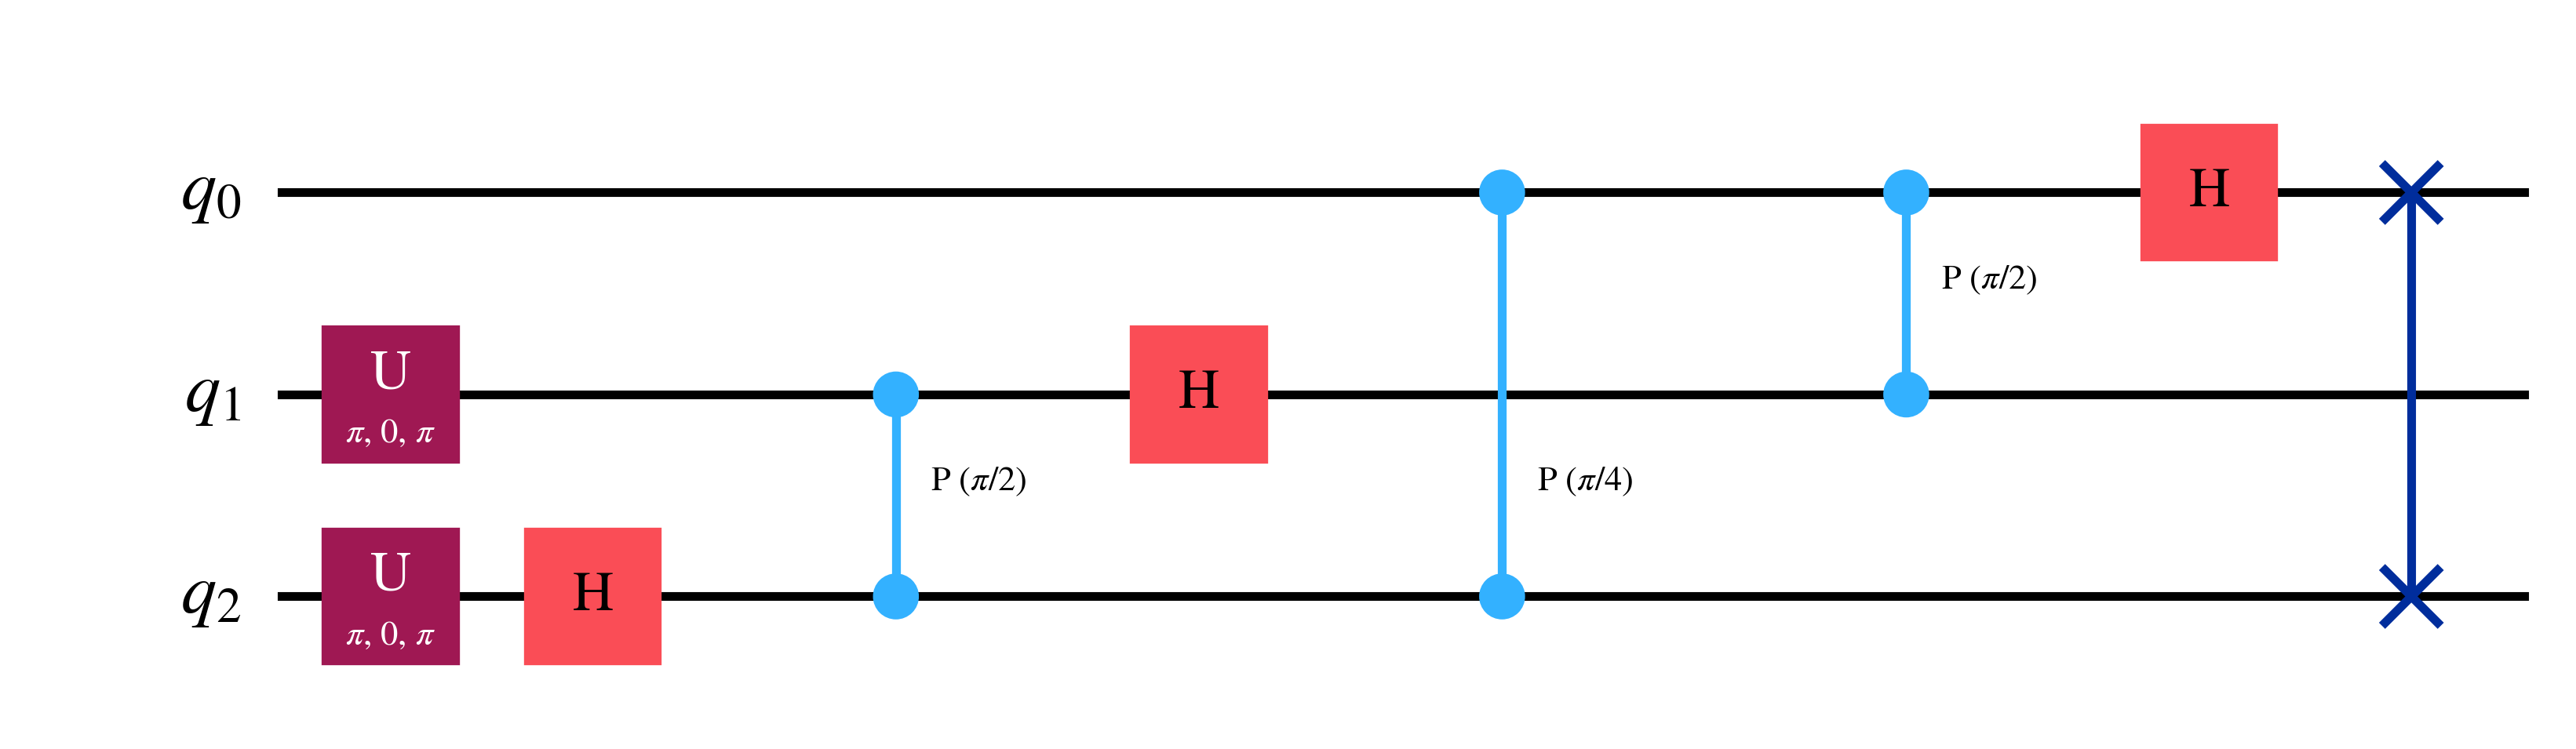

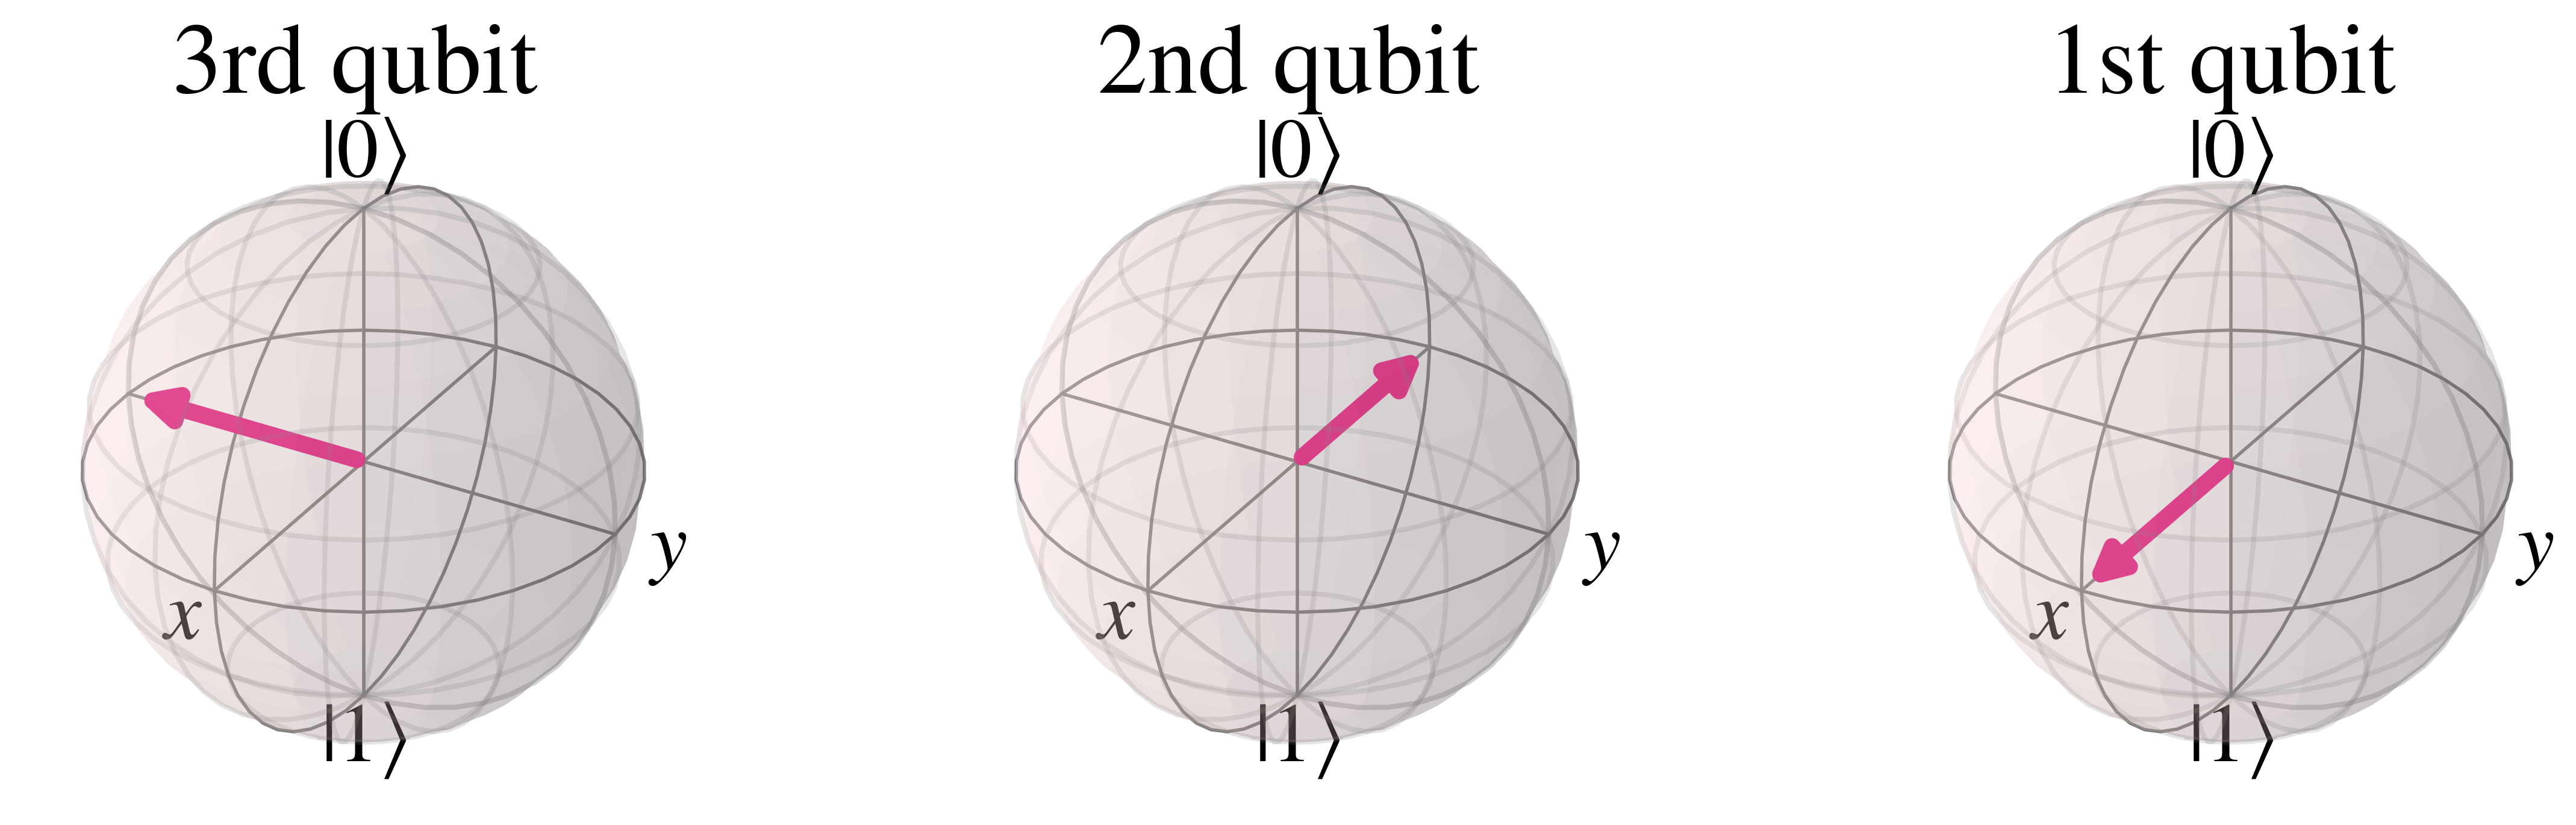

In [68]:
# Step 1: Create circuit
qc_qft = QuantumCircuit(3)
qc_qft.x(1)
qc_qft.x(2)
qc_qft.compose(QFTGate(3), inplace=True)
qc_qft = qc_qft.decompose()
#qc_qft.measure_all()
fig=qc_qft.draw("mpl")
fig.show()

qc_qft.save_statevector()
statevector = backend_sim.run(qc_qft).result().get_statevector()
fig = plot_bloch_multivector(statevector)

# Access axes or modify titles/labels via matplotlib
# Note: plot_bloch_multivector creates subplots for each qubit
axes = fig.axes
label_numbers = ['3rd', '2nd', '1st']
for i, ax in enumerate(axes):
    # Example: change or set a custom title/label for each subplot
    ax.set_title(label_numbers[i] + ' qubit', pad=30)

#plt.show()
plt.savefig(figure_directory+'blochvectors_of_QFT_transform_of_110.png', bbox_inches='tight', pad_inches=0.1)
#fig.show()

## Phase Estimation

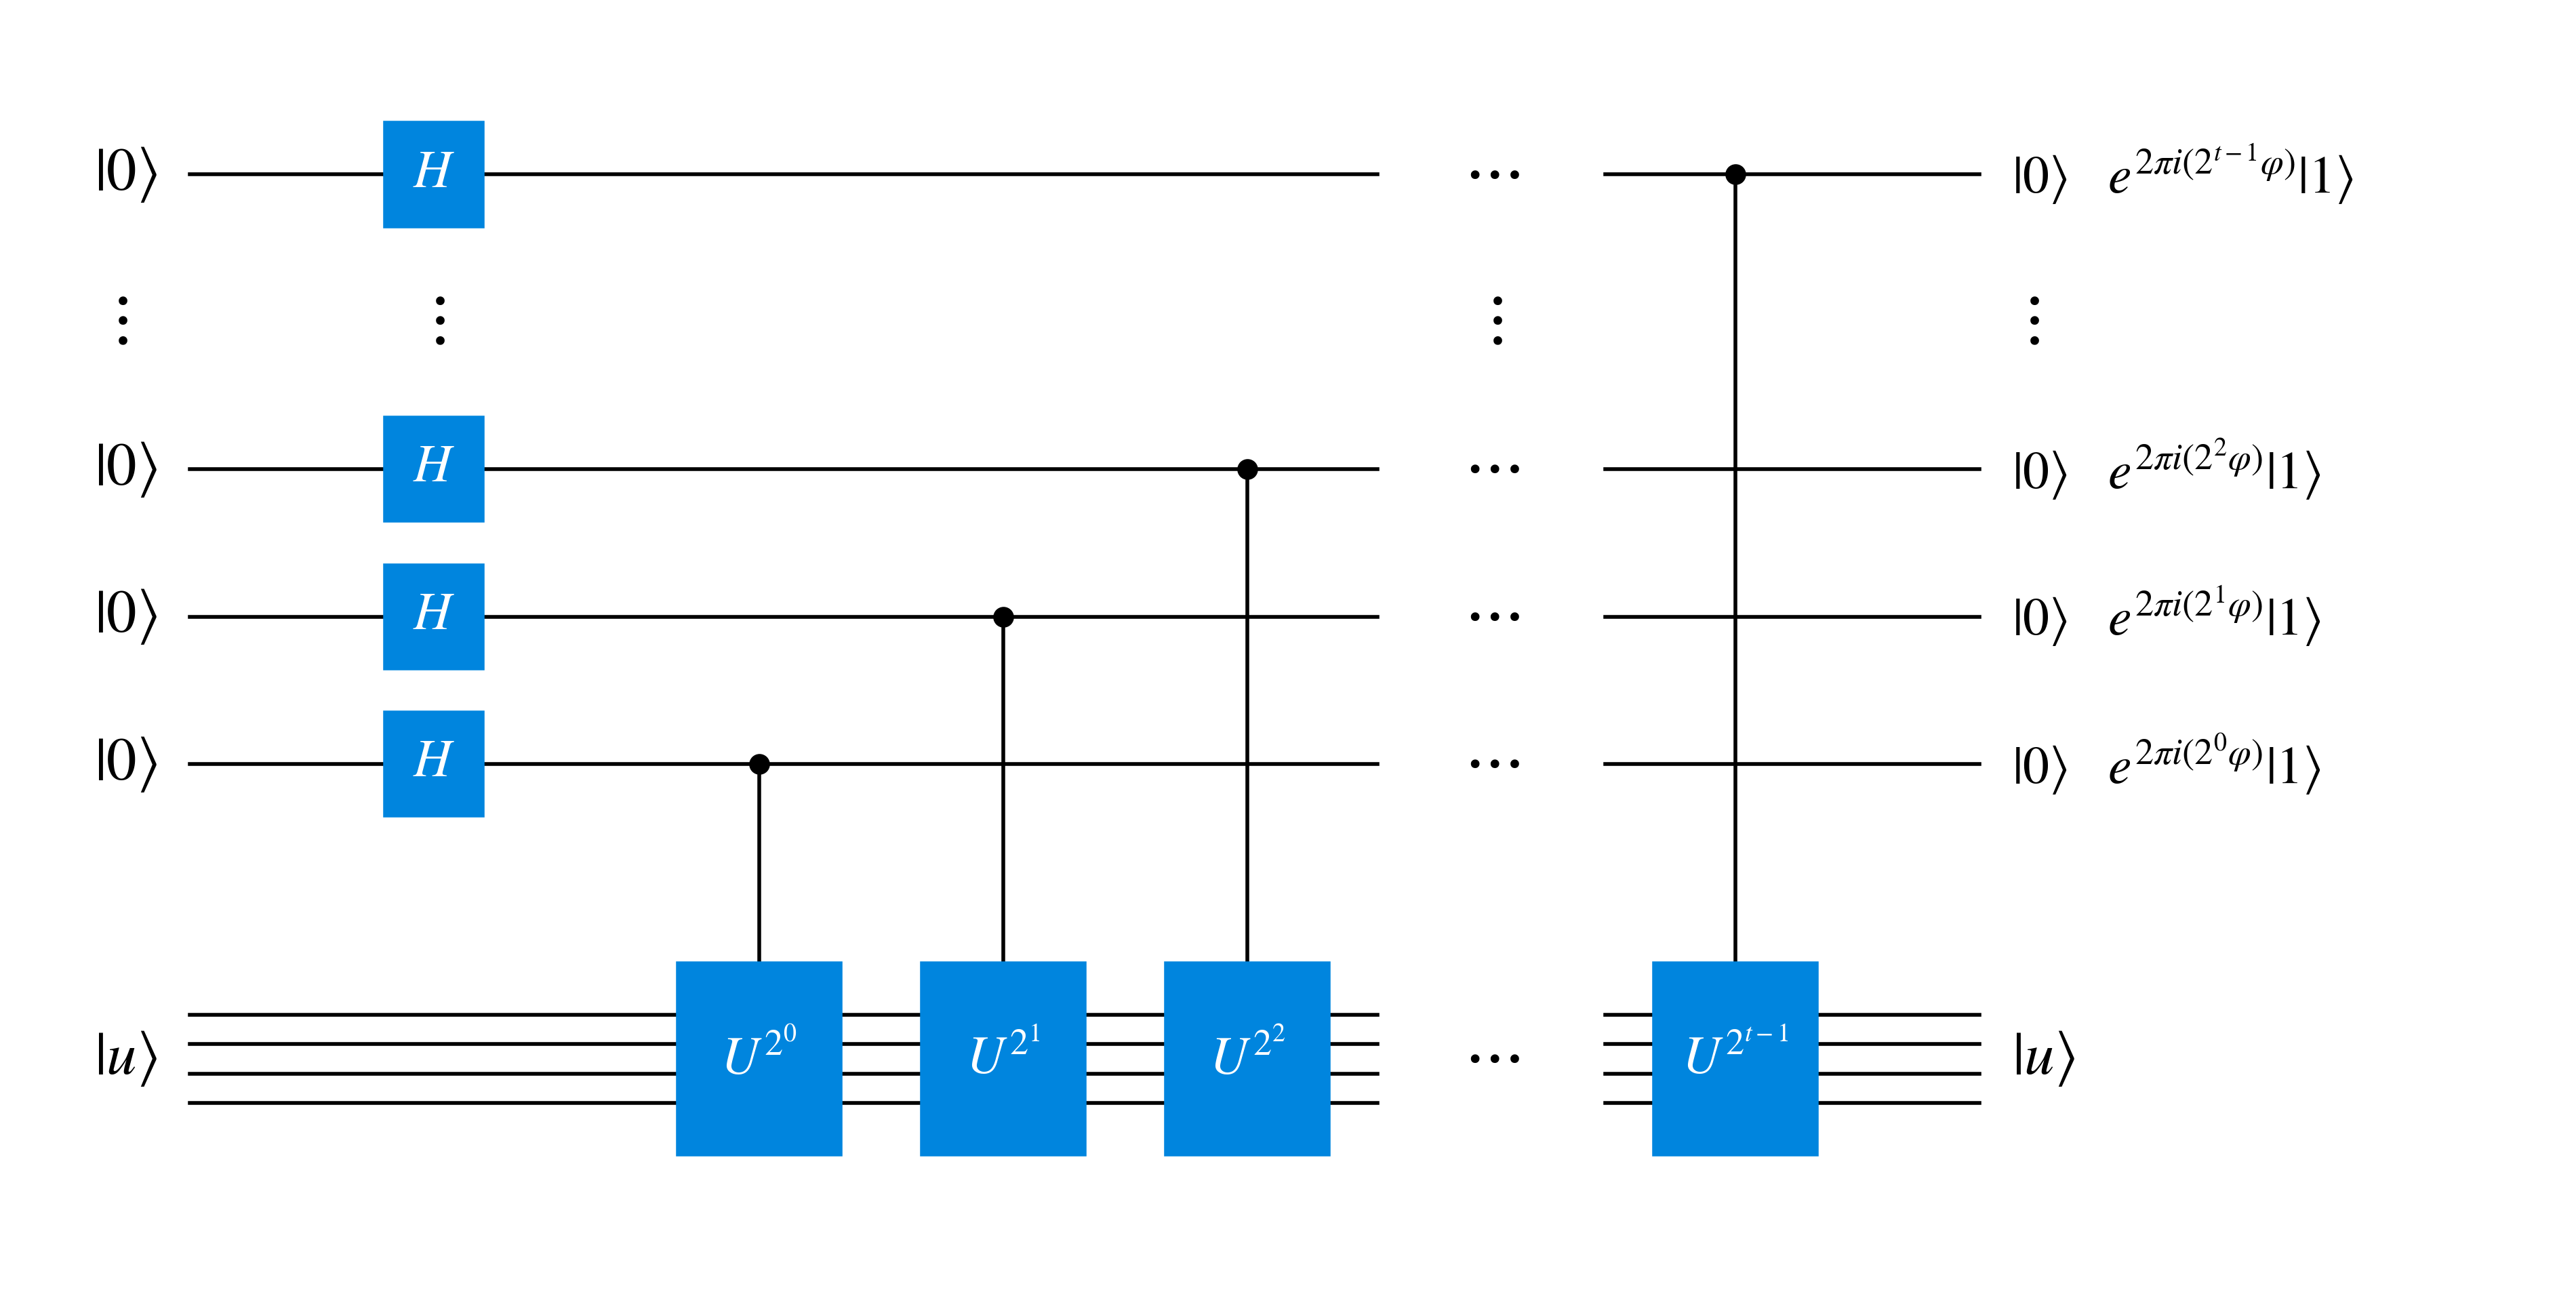

In [20]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

def draw_phase_estimation_circuit():
    # Setup figure and hide axes for a clean circuit look
    fig, ax = plt.subplots(figsize=(12, 6))
    ax.axis('off')

    # Y-coordinates for the horizontal wires
    y_u = 0          # Center of the multi-wire target register
    y_ctrl0 = 2      # Wire controlling U^{2^0}
    y_ctrl1 = 3      # Wire controlling U^{2^1}
    y_ctrl2 = 4      # Wire controlling U^{2^2}
    y_ctrlt = 6      # Wire controlling U^{2^{t-1}}
    
    y_wires = [y_ctrlt, y_ctrl2, y_ctrl1, y_ctrl0]

    # X-coordinates for horizontal alignment
    x_start = 0
    x_h = 1.5        # Hadamard gates
    x_u0 = 3.5       # First controlled U
    x_u1 = 5.0       # Second controlled U
    x_u2 = 6.5       # Third controlled U
    x_ell = 8.0      # Ellipses (...)
    x_ut = 9.5       # Final controlled U
    x_end = 11.0     # End of the wire lines

    # 1. Draw target register lines (4 closely spaced lines)
    for dy in [0.3, 0.1, -0.1, -0.3]:
        # Draw from start to before ellipsis, then after ellipsis to end
        ax.plot([x_start, x_ell - 0.7], [y_u + dy, y_u + dy], color='black', lw=1, zorder=1)
        ax.plot([x_ell + 0.7, x_end], [y_u + dy, y_u + dy], color='black', lw=1, zorder=1)

    # 2. Draw control wires
    for y in y_wires:
        ax.plot([x_start, x_ell - 0.7], [y, y], color='black', lw=1, zorder=1)
        ax.plot([x_ell + 0.7, x_end], [y, y], color='black', lw=1, zorder=1)

    # 3. Add ellipses (...)
    ax.text(x_ell, y_u, r'$\cdots$', fontsize=18, ha='center', va='center')
    for y in y_wires:
        ax.text(x_ell, y, r'$\cdots$', fontsize=18, ha='center', va='center')

    ax.text(x_start-0.45, 5, r'$\vdots$', fontsize=18, ha='center', va='center')
    ax.text(x_h, 5, r'$\vdots$', fontsize=18, ha='center', va='center')
    ax.text(x_ell, 5, r'$\vdots$', fontsize=18, ha='center', va='center')
    ax.text(x_end+0.3, 5, r'$\vdots$', fontsize=18, ha='center', va='center')

    # Helper function to draw blue-filled boxes with white text
    def draw_gate_box(x, y, text, width=0.8, height=0.8):
        rect = patches.Rectangle((x - width/2, y - height/2), width, height,
                                 facecolor='#0085DE', edgecolor='#0085DE', lw=1, zorder=2)
        ax.add_patch(rect)
        ax.text(x, y, text, fontsize=14, color='white', ha='center', va='center', zorder=3)

    # 4. Draw H gates
    for y in y_wires:
        draw_gate_box(x_h, y, '$H$', width=0.6, height=0.7)

    # 5. Draw U gates and their vertical control lines
    u_data = [
        (x_u0, y_ctrl0, r'$U^{2^0}$'),
        (x_u1, y_ctrl1, r'$U^{2^1}$'),
        (x_u2, y_ctrl2, r'$U^{2^2}$'),
        (x_ut, y_ctrlt, r'$U^{2^{t-1}}$')
    ]

    for x, y_ctrl, label in u_data:
        # Vertical line from control dot down to target register
        ax.plot([x, x], [y_ctrl, y_u + 0.5], color='black', lw=1, zorder=1)
        # Control dot
        ax.plot([x], [y_ctrl], marker='o', color='black', markersize=4.5, zorder=2)
        # U box (drawn slightly taller to cover the 4 target lines)
        draw_gate_box(x, y_u, label, width=1.0, height=1.3)

    # 6. Add initial state labels (Left side)
    ax.text(x_start - 0.2, y_ctrlt, r'$|0\rangle$', fontsize=16, ha='right', va='center')
    ax.text(x_start - 0.2, y_ctrl2, r'$|0\rangle$', fontsize=16, ha='right', va='center')
    ax.text(x_start - 0.2, y_ctrl1, r'$|0\rangle$', fontsize=16, ha='right', va='center')
    ax.text(x_start - 0.2, y_ctrl0, r'$|0\rangle$', fontsize=16, ha='right', va='center')
    ax.text(x_start - 0.2, y_u, r'$|u\rangle$', fontsize=16, ha='right', va='center')

    # 7. Add final state labels (Right side)
    ax.text(x_end + 0.2, y_ctrlt, r'$|0\rangle \quad e^{2\pi i(2^{t-1}\varphi)}|1\rangle$', fontsize=14, ha='left', va='center')
    ax.text(x_end + 0.2, y_ctrl2, r'$|0\rangle \quad e^{2\pi i(2^2\varphi)}|1\rangle$', fontsize=14, ha='left', va='center')
    ax.text(x_end + 0.2, y_ctrl1, r'$|0\rangle \quad e^{2\pi i(2^1\varphi)}|1\rangle$', fontsize=14, ha='left', va='center')
    ax.text(x_end + 0.2, y_ctrl0, r'$|0\rangle \quad e^{2\pi i(2^0\varphi)}|1\rangle$', fontsize=14, ha='left', va='center')
    ax.text(x_end + 0.2, y_u, r'$|u\rangle$', fontsize=16, ha='left', va='center')

    # Ensure boundaries fit cleanly around the text
    ax.set_xlim(-1, 14.5)
    ax.set_ylim(-1.5, 7)
    
    return fig

# Generate and save the figure
fig = draw_phase_estimation_circuit()
fig.savefig(figure_directory + 'phase_estimation_circuit_without_inverse_QFT.png', bbox_inches='tight')
#fig

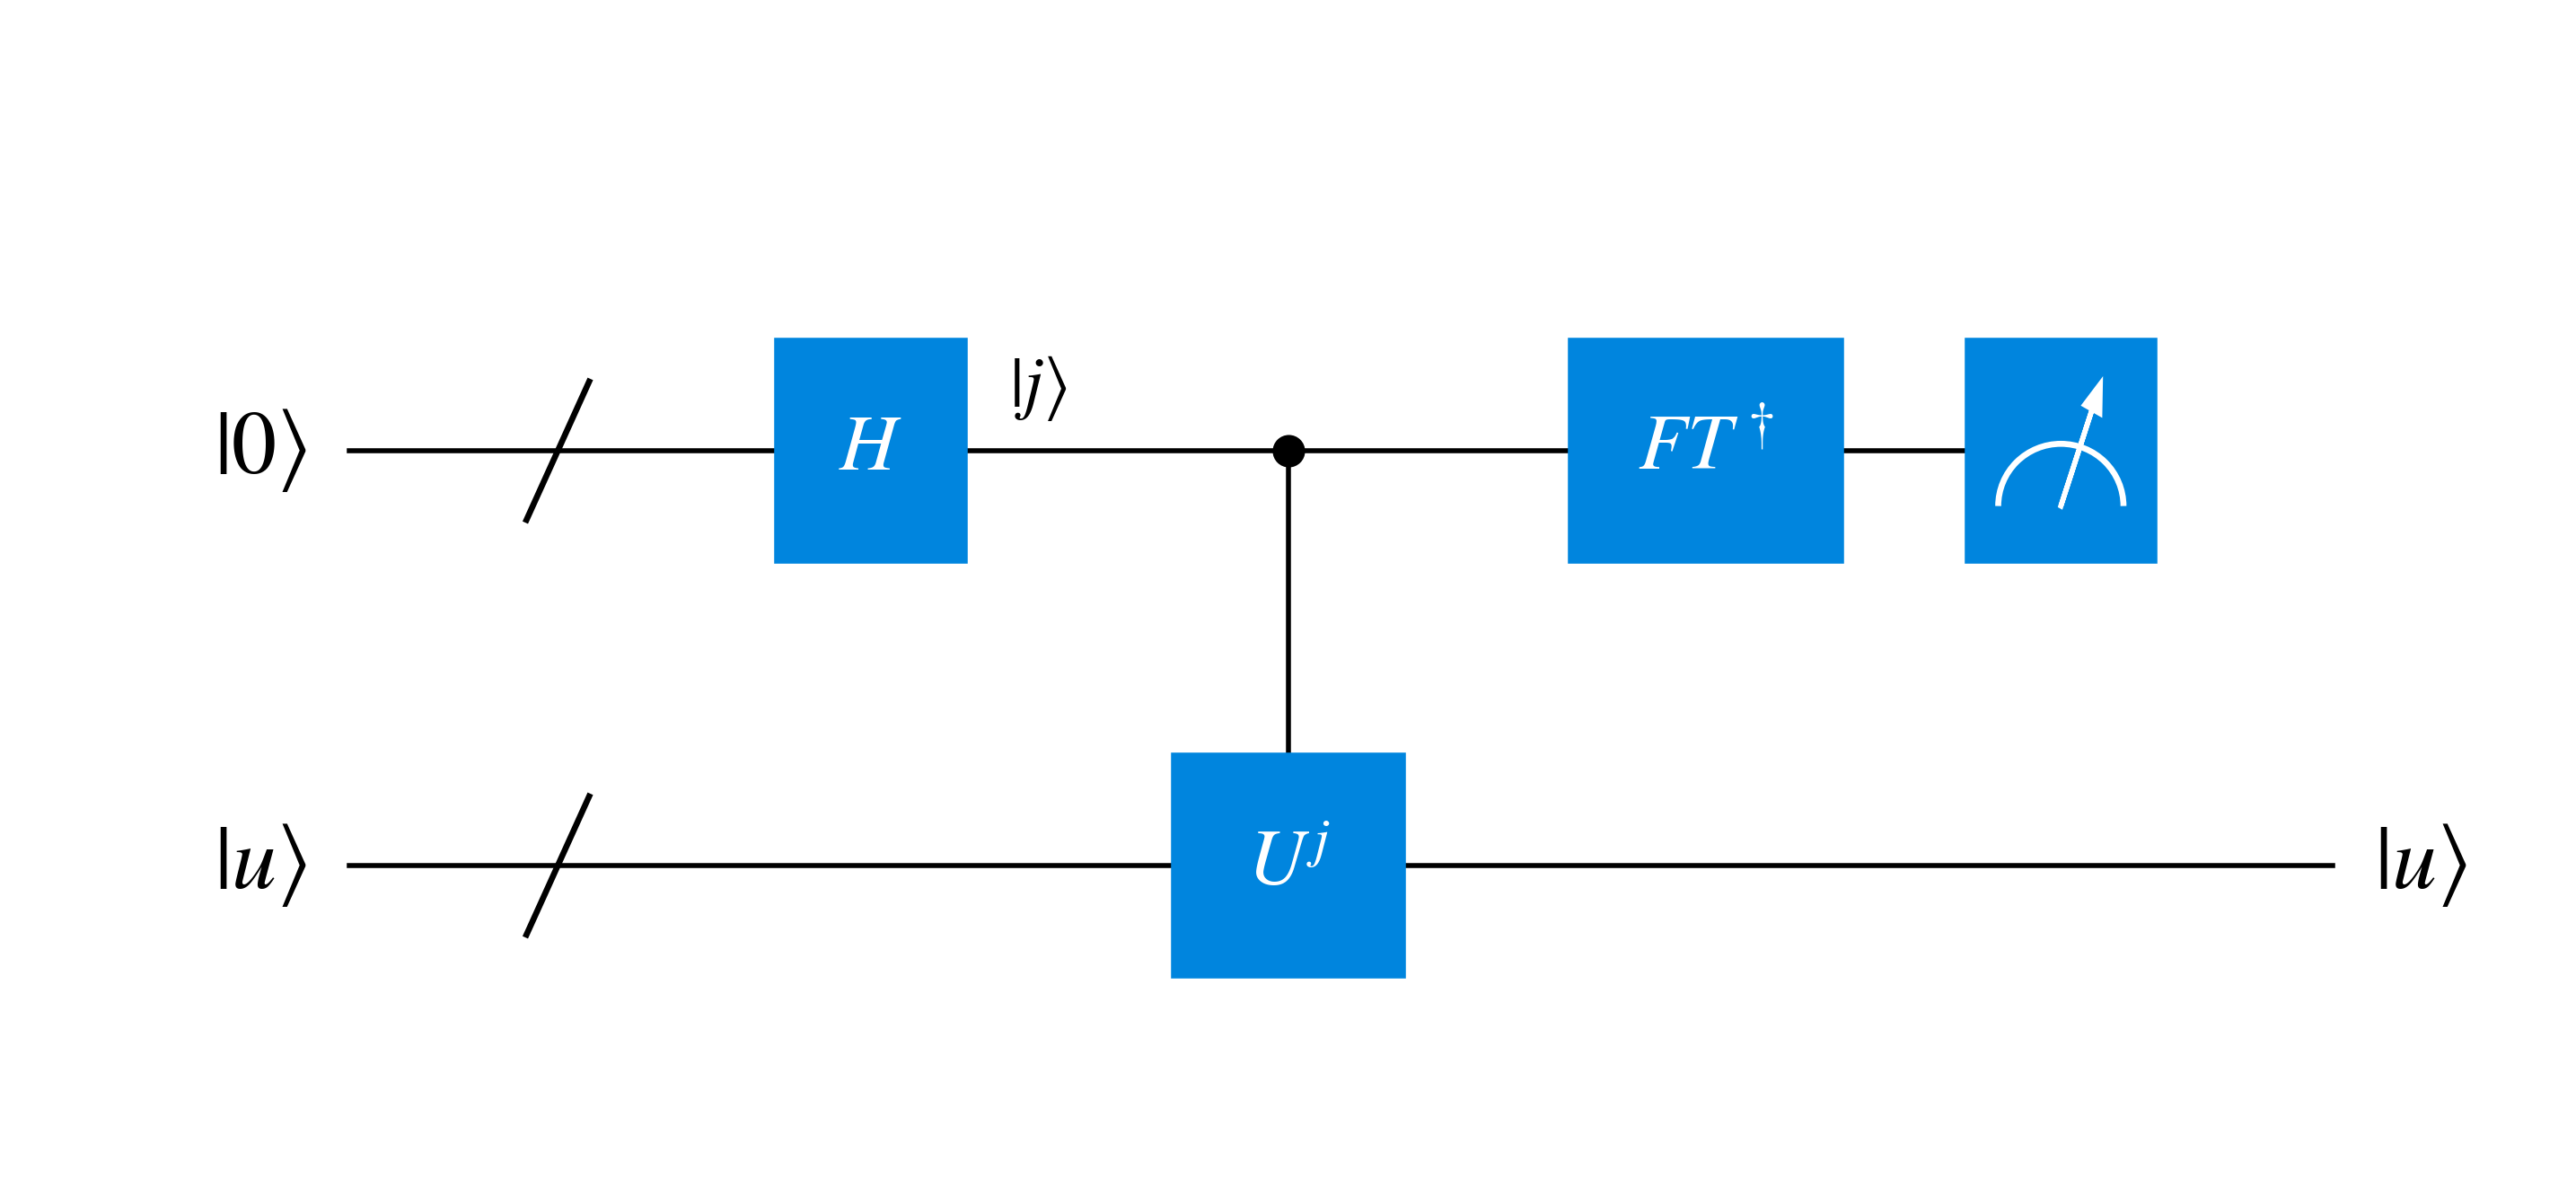

In [19]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

def draw_phase_circuit():
    # Setup figure and hide axes for a clean circuit look
    fig, ax = plt.subplots(figsize=(9, 4))
    ax.axis('off')

    # Y-coordinates for the horizontal wires
    y_top = 1.5
    y_bot = 0.0

    # X-coordinates for elements along the wires
    x_start = 0.0
    x_slash = 1.0       # Multi-qubit bundle slash
    x_h = 2.5           # H gate
    x_ctrl = 4.5        # Control dot and U^j gate
    x_ft = 6.5          # FT dagger gate
    x_meas = 8.2        # Measurement meter
    x_end = 9.5         # End of bottom wire

    # 1. Draw Wires (Bottom layer)
    # Top wire stops at the measurement meter
    ax.plot([x_start, x_meas], [y_top, y_top], color='black', lw=1, zorder=1)
    # Bottom wire goes to the end
    ax.plot([x_start, x_end], [y_bot, y_bot], color='black', lw=1, zorder=1)

    # 2. Draw Multi-Qubit Slashes (/)
    slash_dx = 0.15
    slash_dy = 0.25
    ax.plot([x_slash - slash_dx, x_slash + slash_dx], 
            [y_top - slash_dy, y_top + slash_dy], color='black', lw=1.2, zorder=2)
    ax.plot([x_slash - slash_dx, x_slash + slash_dx], 
            [y_bot - slash_dy, y_bot + slash_dy], color='black', lw=1.2, zorder=2)

    # 3. Draw Vertical Control Line and Dot
    ax.plot([x_ctrl, x_ctrl], [y_bot, y_top], color='black', lw=1, zorder=1)
    ax.plot([x_ctrl], [y_top], marker='o', color='black', markersize=5.5, zorder=2)

    # Helper function to draw blue-filled boxes with white text
    def draw_gate_box(x, y, text, width=0.9, height=0.8):
        rect = patches.Rectangle((x - width/2, y - height/2), width, height,
                                 facecolor='#0085DE', edgecolor='#0085DE', lw=1, zorder=2)
        ax.add_patch(rect)
        if text:
            ax.text(x, y, text, fontsize=16, color='white', ha='center', va='center', zorder=3)

    # 4. Draw standard gates
    draw_gate_box(x_h, y_top, r'$H$')
    draw_gate_box(x_ctrl, y_bot, r'$U^j$', width=1.1)
    draw_gate_box(x_ft, y_top, r'$FT^\dagger$', width=1.3)

    # 5. Draw Measurement Meter Box (Top right)
    draw_gate_box(x_meas, y_top, '', width=0.9) # Empty blue box
    
    # Add white arc inside the measurement meter
    arc = patches.Arc((x_meas, y_top - 0.2), 0.6, 0.45, theta1=0, theta2=180, 
                      color='white', lw=1.2, zorder=3)
    ax.add_patch(arc)
    
    # Add white arrow inside the measurement meter
    ax.arrow(x_meas, y_top - 0.2, 0.15, 0.35, head_width=0.08, head_length=0.1, 
             fc='white', ec='white', lw=1, zorder=3)

    # 6. Add Math/State Labels
    ax.text(x_start - 0.2, y_top, r'$|0\rangle$', fontsize=18, ha='right', va='center')
    ax.text(x_start - 0.2, y_bot, r'$|u\rangle$', fontsize=18, ha='right', va='center')
    
    # Add |j> label hovering above the wire between H and the control dot
    ax.text(x_h + 0.8, y_top + 0.1, r'$|j\rangle$', fontsize=14, ha='center', va='bottom')
    
    ax.text(x_end + 0.2, y_bot, r'$|u\rangle$', fontsize=18, ha='left', va='center')

    # Keep bounding box clean
    ax.set_xlim(-1.5, 10.5)
    ax.set_ylim(-1, 3)
    
    return fig

# Generate and display the figure
fig = draw_phase_circuit()
fig.savefig(figure_directory + 'simplified_phase_estimation_circuit.png', bbox_inches='tight', dpi=300)
